# Spectral_Analysis — part 1 of 7

This notebook was automatically split from a larger notebook.

# Spectral Analysis

# Welch's

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This section presents an expanded expert-level exploratory spectral analysis pipeline for EEG data. The workflow estimates power spectral density using Welch's method, extracts bandpower and aperiodic descriptors, tracks posterior alpha dynamics, and generates black-background cyan-styled diagnostic plots for notebook inspection and saved output review.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Runtime Control: Use <code>FAST_OPTION</code> modes including <code>ultra</code>, <code>fast</code>, <code>balanced</code>, and <code>full</code>.</li>
            <li>Preprocessing: Load EEG data, enforce time-by-channel layout, optionally apply common average reference, apply a 60 Hz notch filter, and optionally downsample for faster spectral computation.</li>
            <li>PSD Estimation: Compute Welch PSDs for all EEG channels over the selected stimulation-free interval.</li>
            <li>Bandpower Analysis: Estimate absolute and relative delta, theta, alpha, beta, and low-gamma power.</li>
            <li>Expert Descriptors: Compute spectral entropy, median frequency, spectral edge frequency, alpha peak frequency, aperiodic slope, aperiodic residuals, and composite spectral interest scores.</li>
            <li>Temporal Alpha Tracking: Analyze frontal and posterior sliding alpha power and estimate a confidence-masked posterior alpha ridge.</li>
            <li>Visualization: Preserve the original PSD, heatmap, descriptor, spectrogram, and alpha plots while adding expert heatmaps, scalp maps, ROI summaries, and ridge diagnostics.</li>
        </ul>
        <h2>Mathematical Formulations</h2>
        <h3>Welch Power Spectral Density</h3>
        <p>The EEG signal \(x(t)\) is divided into overlapping Hann-windowed segments. The power spectral density is estimated by averaging the squared Fourier magnitudes:</p>
        \[P(f)=\frac{1}{K}\sum_{k=1}^{K}\left|\mathcal{F}\{w(t)x_k(t)\}\right|^2\]
        <p>where \(K\) is the number of segments, \(w(t)\) is the Hann window, \(x_k(t)\) is the \(k\)-th segment, and \(\mathcal{F}\) denotes the Fourier transform.</p>
        <h3>Relative Bandpower</h3>
        <p>For each channel and band \(B=[f_1,f_2]\), bandpower is computed by integrating the PSD over that band:</p>
        \[P_B=\int_{f_1}^{f_2}P(f)\,df\]
        <p>Relative bandpower normalizes each band by the total descriptor-range power:</p>
        \[R_B=\frac{P_B}{\int_{1}^{55}P(f)\,df+\epsilon}\]
        <h3>Spectral Entropy</h3>
        <p>Spectral entropy measures how broadly or narrowly power is distributed across frequencies:</p>
        \[H=-\frac{\sum_i p_i\log(p_i+\epsilon)}{\log(N)}\]
        <p>where \(p_i=P(f_i)/\sum_jP(f_j)\), \(N\) is the number of frequency bins, and \(\epsilon\) prevents numerical instability.</p>
        <h3>Spectral Edge and Median Frequency</h3>
        <p>The spectral edge frequency \(f_e\) is the frequency below which a selected fraction of total power is contained:</p>
        \[\frac{\int_{1}^{f_e}P(f)\,df}{\int_{1}^{55}P(f)\,df}=e\]
        <p>The code computes both median frequency using \(e=0.50\) and spectral edge frequency using \(e=0.95\).</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Aperiodic Spectral Modeling</h2>
        <p>The expanded code estimates the broadband aperiodic background by fitting a line in log-log frequency-power space while excluding alpha and line-noise-adjacent bands:</p>
        \[\log_{10}P(f)=a\log_{10}(f)+b\]
        <p>Here, \(a\) is the aperiodic slope and \(b\) is the intercept. The resulting residual spectrum is:</p>
        \[R(f)=\log_{10}P(f)-\left(a\log_{10}(f)+b\right)\]
        <p>This residual highlights narrowband spectral excess above the broadband \(1/f\)-like background.</p>
        <h2>Expert Spectral Interest Score</h2>
        <p>A composite exploratory score ranks channels using alpha power, alpha dominance, low-gamma power, spectral concentration, aperiodic fit quality, aperiodic slope, and spectral edge frequency:</p>
        \[S=0.22A+0.18D_{\alpha}+0.16G+0.14C+0.12R^2+0.10(-a)+0.08E_{95}\]
        <p>where each term is robustly normalized before combination. This score is not a clinical metric; it is a prioritization tool for exploratory review.</p>
        <h2>Temporal Alpha Dynamics</h2>
        <p>The code computes sliding relative alpha power in frontal and posterior ROIs using short Welch windows. Posterior-frontal alpha balance is defined as:</p>
        \[\Delta_{\alpha}(t)=R_{\alpha,\text{posterior}}(t)-R_{\alpha,\text{frontal}}(t)\]
        <p>This supports time-resolved comparison of posterior alpha dominance against frontal alpha activity.</p>
        <h2>Posterior Alpha Ridge Tracking</h2>
        <p>A posterior ROI spectrogram is computed around the alpha range. The algorithm identifies the strongest frequency ridge inside an adaptive search window centered on the posterior alpha peak:</p>
        \[f_{\text{ridge}}(t)=\arg\max_{f\in[f_c-1.5,f_c+1.5]}P(f,t)\]
        <p>Ridge points are filtered using a confidence value based on the difference between local peak power and the median search-band floor:</p>
        \[C(t)=P_{\text{peak}}(t)-P_{\text{floor}}(t)\]
        <p>Only sufficiently confident ridge samples are retained and smoothed for visualization.</p>
        <h2>Visualization Upgrades</h2>
        <p>The code preserves the original six plots: PSD overview, channel PSD grid, relative bandpower heatmap, descriptor scatter, posterior ROI spectrogram, and frontal/posterior alpha trace. It adds expert plots including a spectral fingerprint heatmap, ROI-average PSD profiles, aperiodic residual heatmap, alpha-dominance descriptor space, top-channel PSD galleries, spectral score ranking, scalp maps, posterior alpha ridge tracking, polar alpha chronomap, alpha ridge plus ROI time series, and ROI-by-band sliding power state maps.</p>
        <h2>Data Storage</h2>
        <p>The analysis saves compressed PSD matrices, aperiodic residuals, spectral descriptors, relative bandpower tables, alpha ridge time series, explanatory notes, plot images, and an optional ZIP archive containing outputs and figures.</p>
        <h2>Scientific Relevance</h2>
        <p>This expanded spectral analysis provides a richer view of EEG structure by separating oscillatory components, broadband aperiodic trends, regional alpha dynamics, and channel-level spectral fingerprints. It is designed for hypothesis generation, anomaly inspection, and downstream feature engineering rather than final clinical interpretation.</p>
        <h2>Summary</h2>
        <p>The upgraded pipeline combines Welch PSD estimation, bandpower analysis, aperiodic modeling, alpha ridge tracking, ROI dynamics, scalp mapping, and expert exploratory visualization. The result is a faster, more interpretable, and more comprehensive spectral analysis framework for EEG data.</p>
    </div>
</div>

Running expert exploratory spectral analysis
FAST_OPTION: ultra
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
Loaded EEG data: 4227788 samples x 32 channels
Original segment shape: (106944, 32)
Analysis segment shape: (26736, 32)
Analysis sampling rate: 250.00 Hz
Segment of interest: 814.571 to 921.515 sec


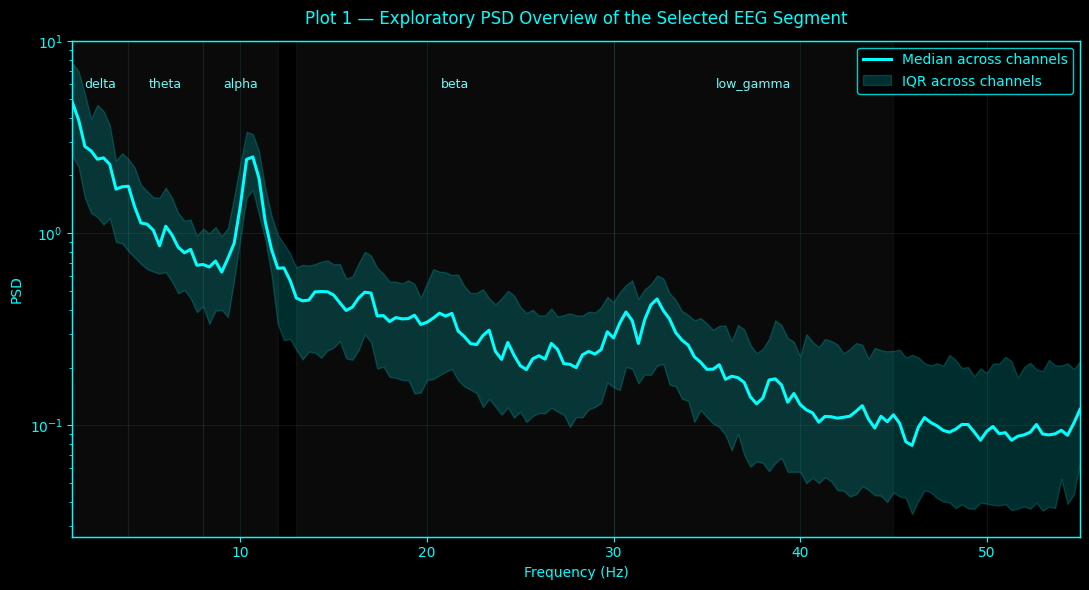

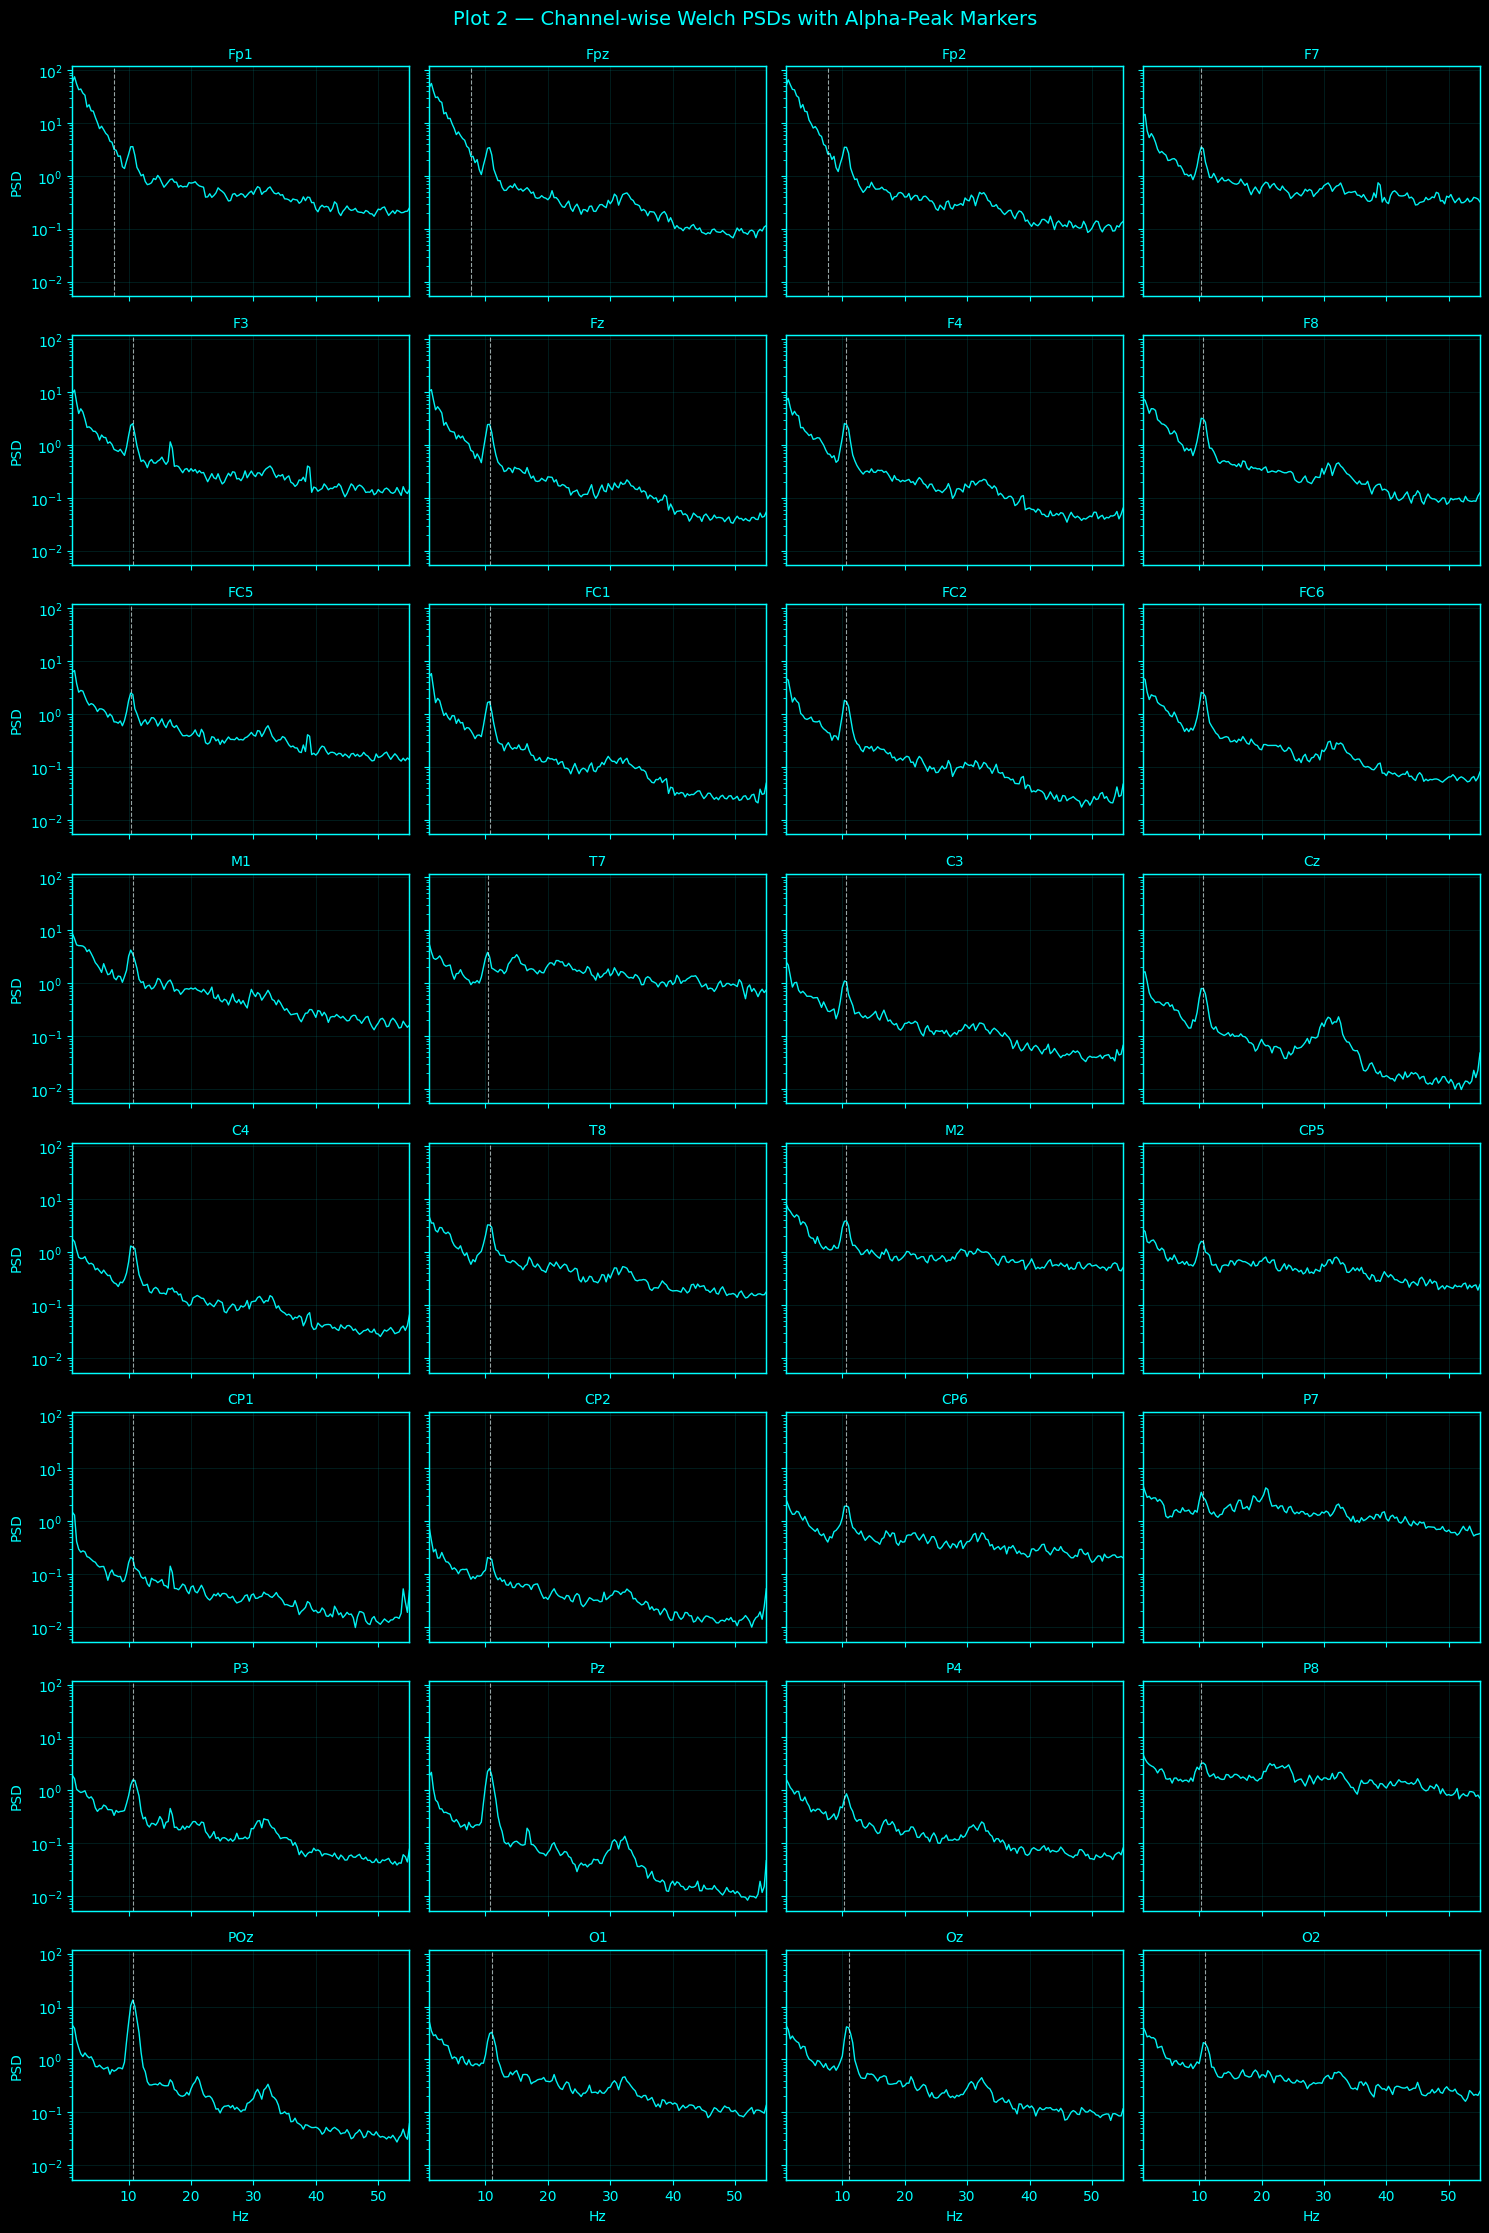

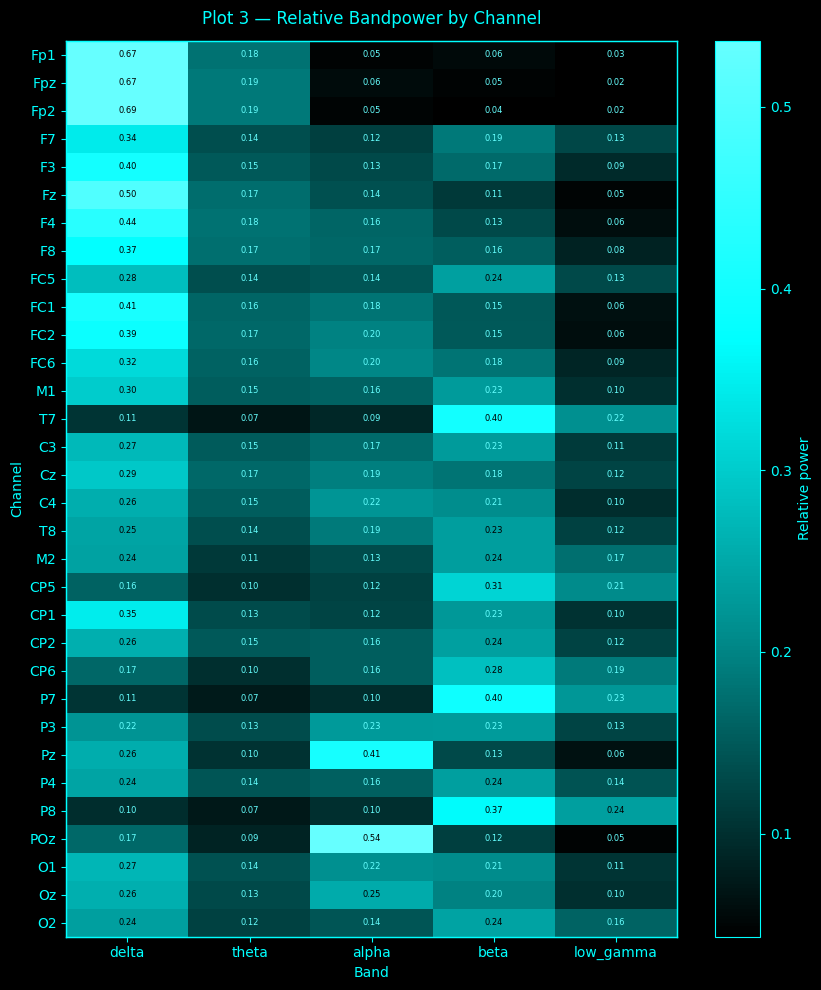

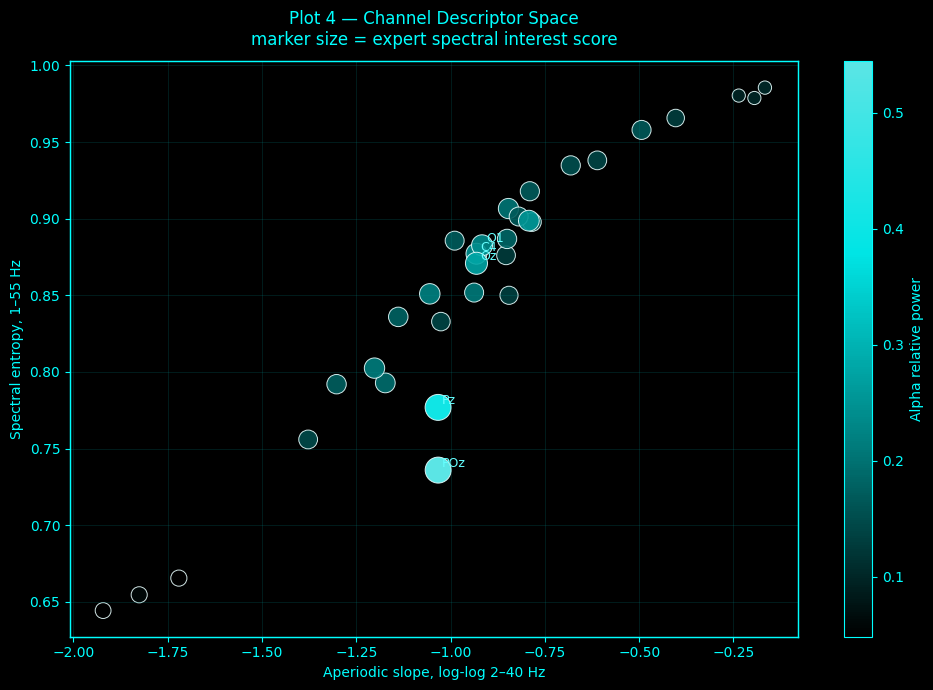

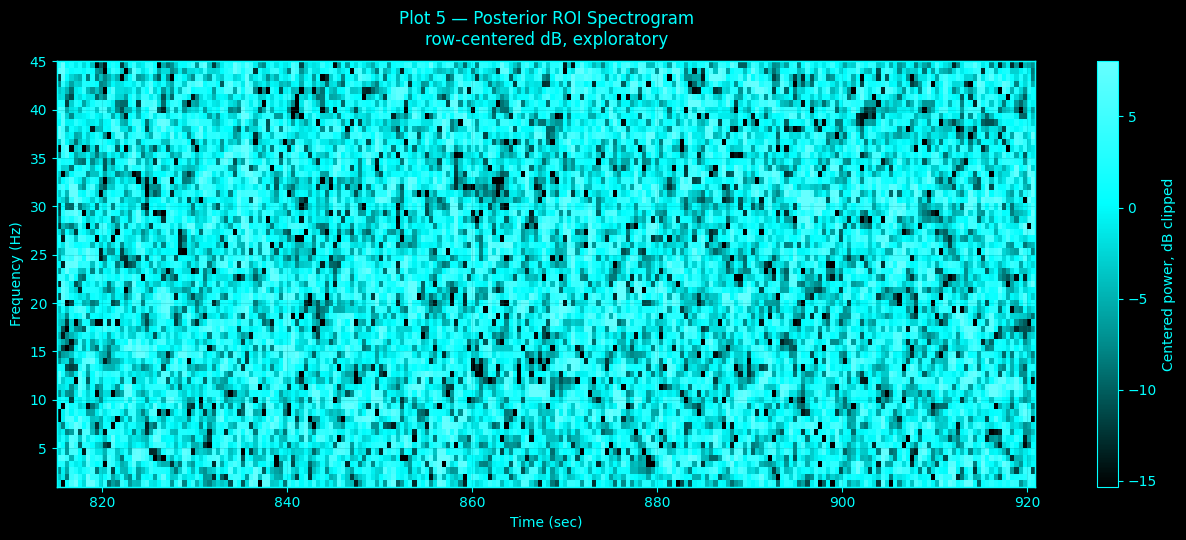

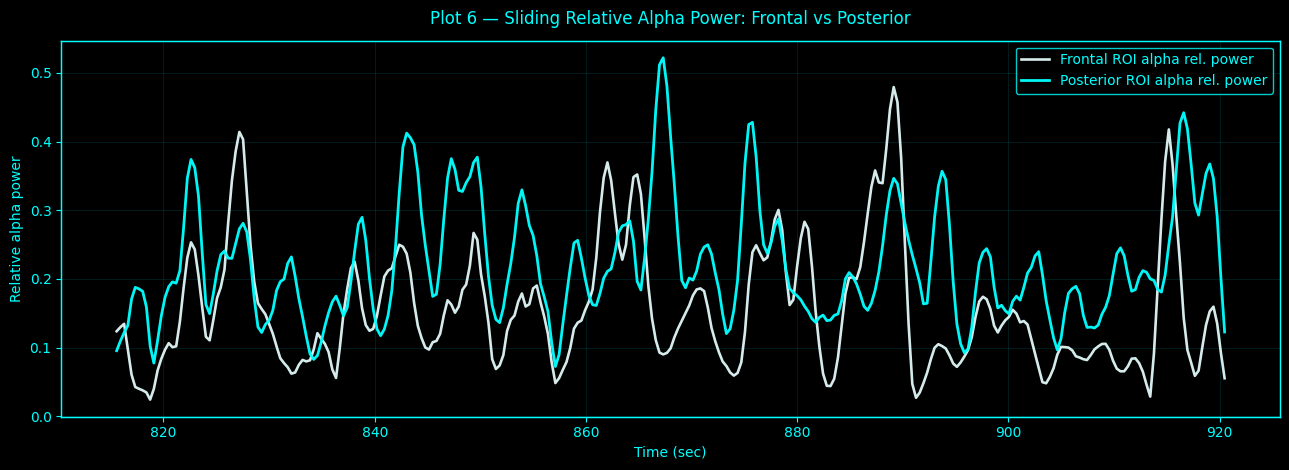

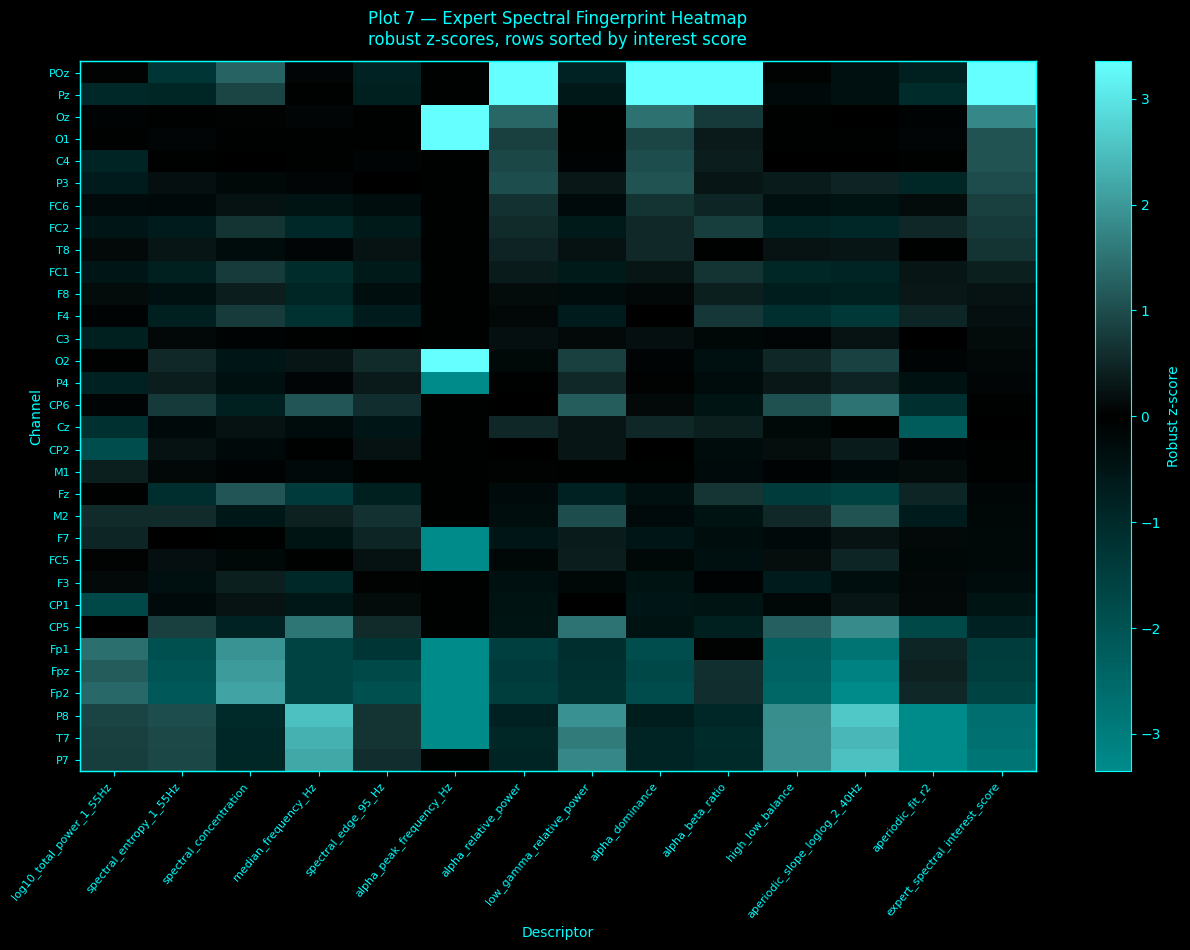

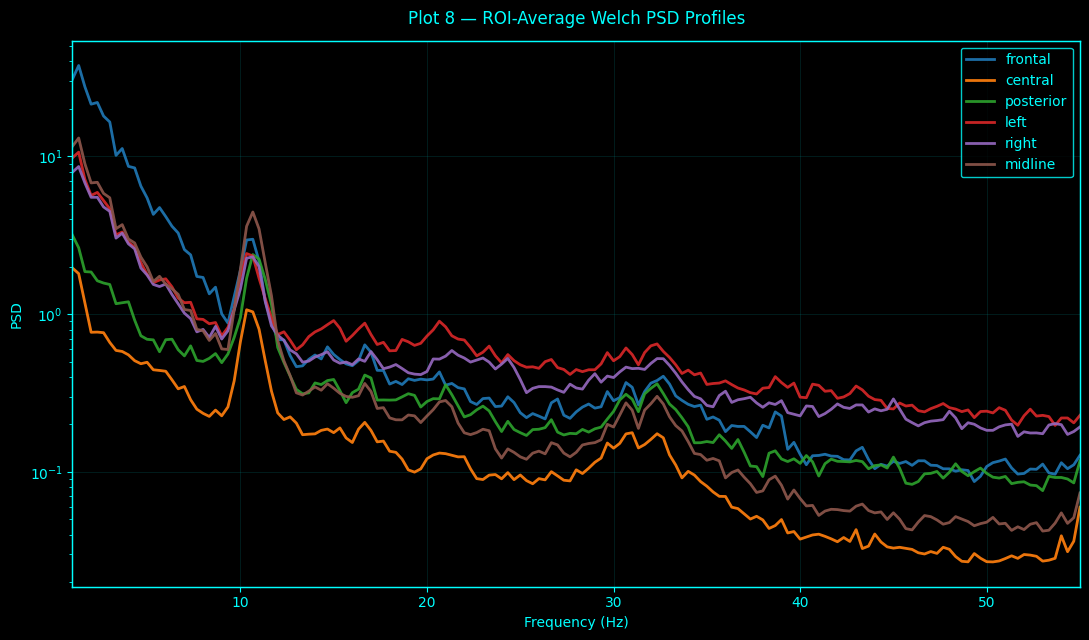

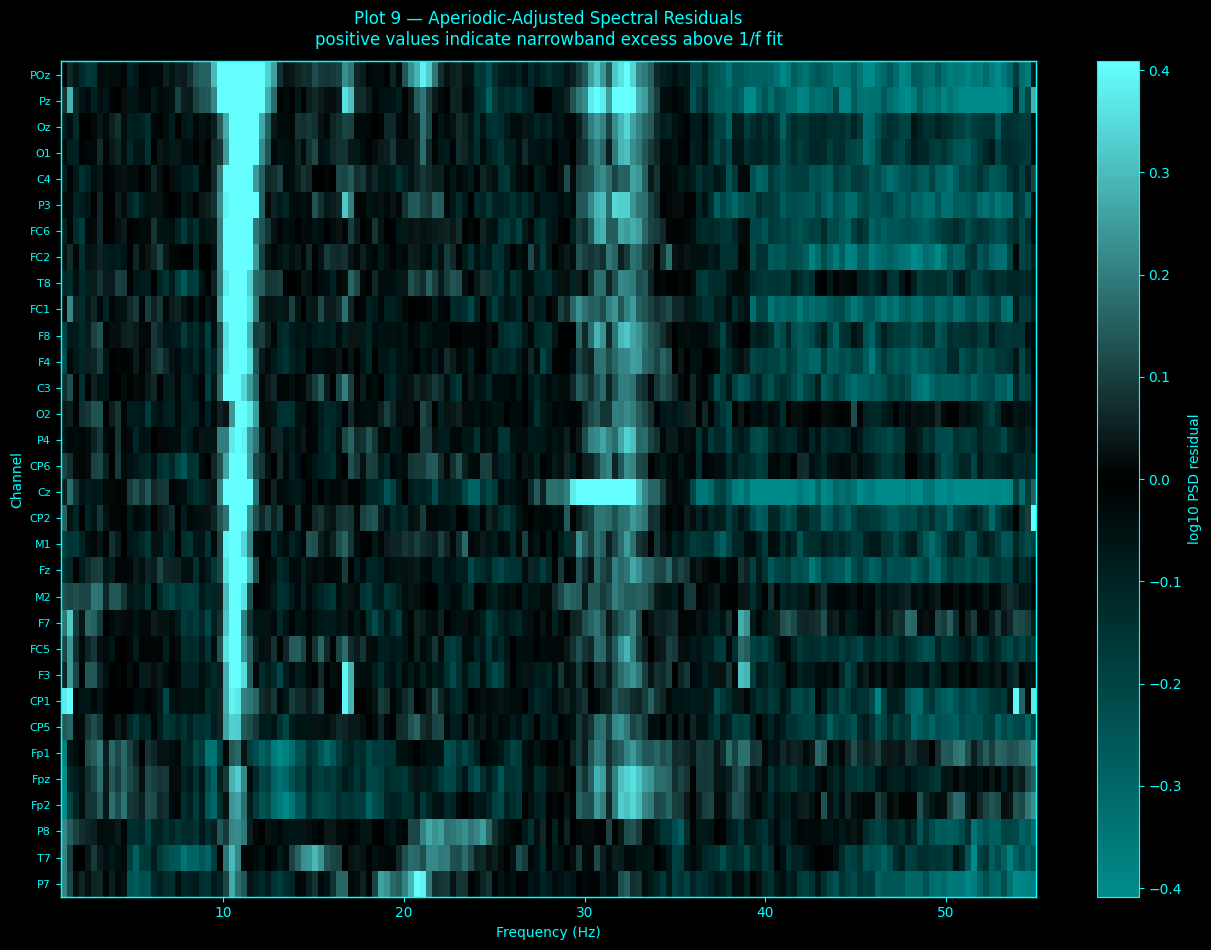

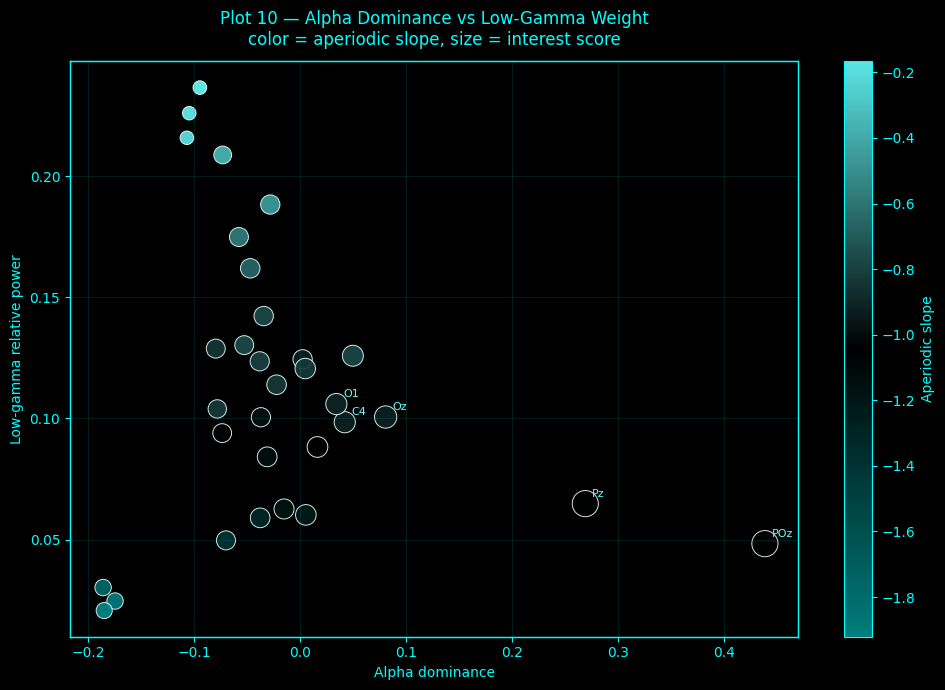

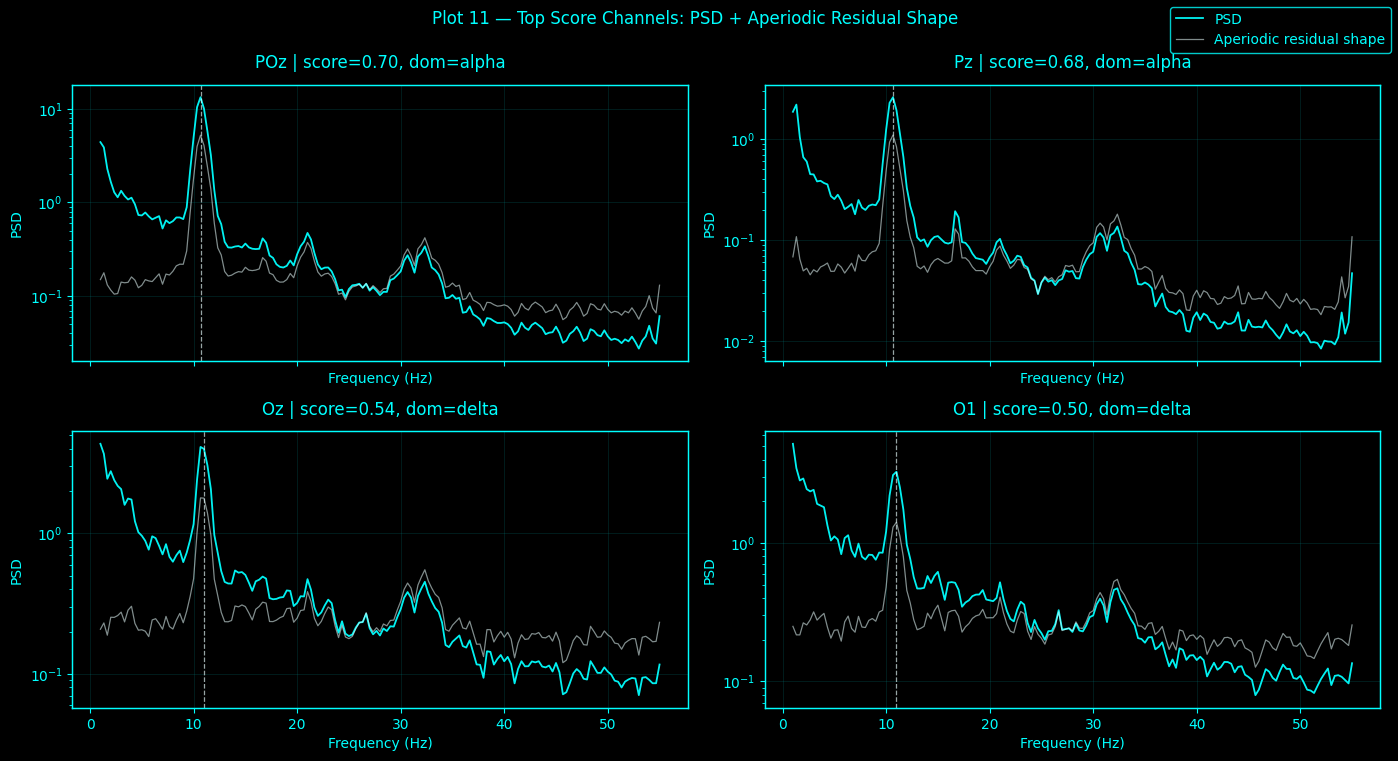

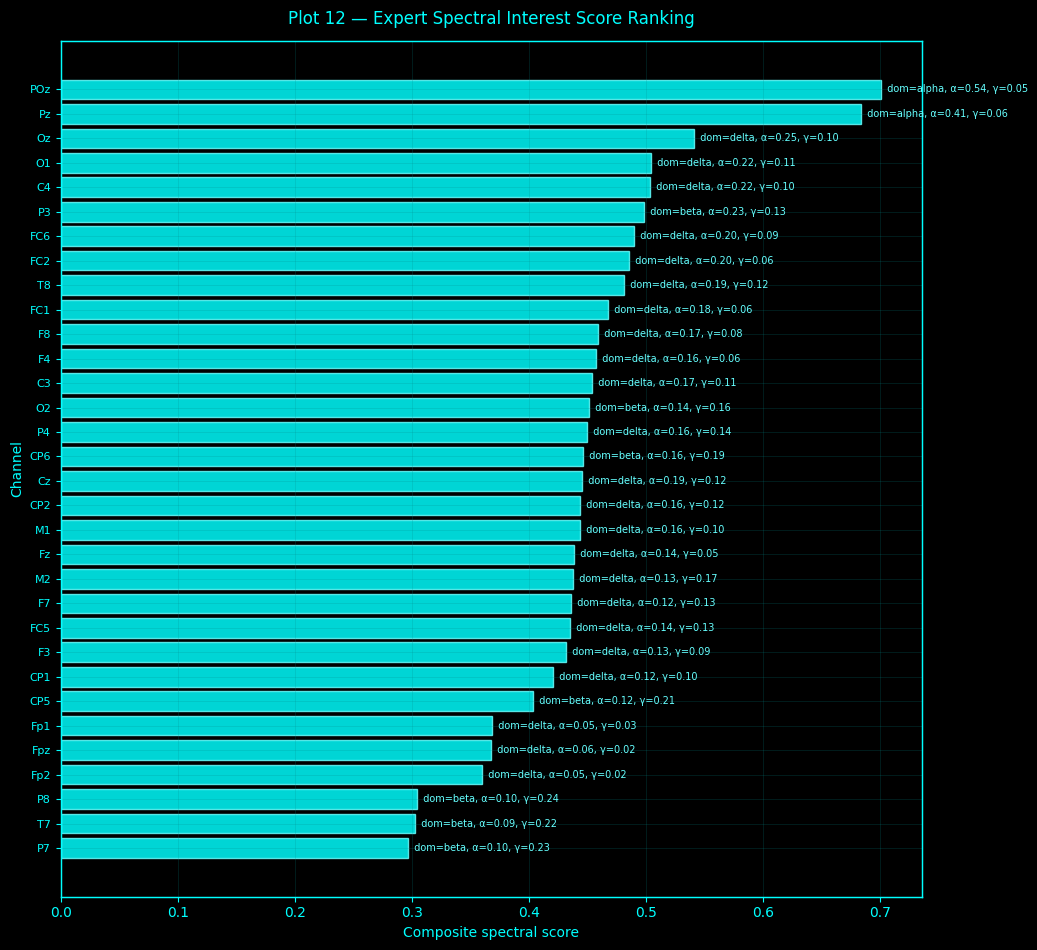

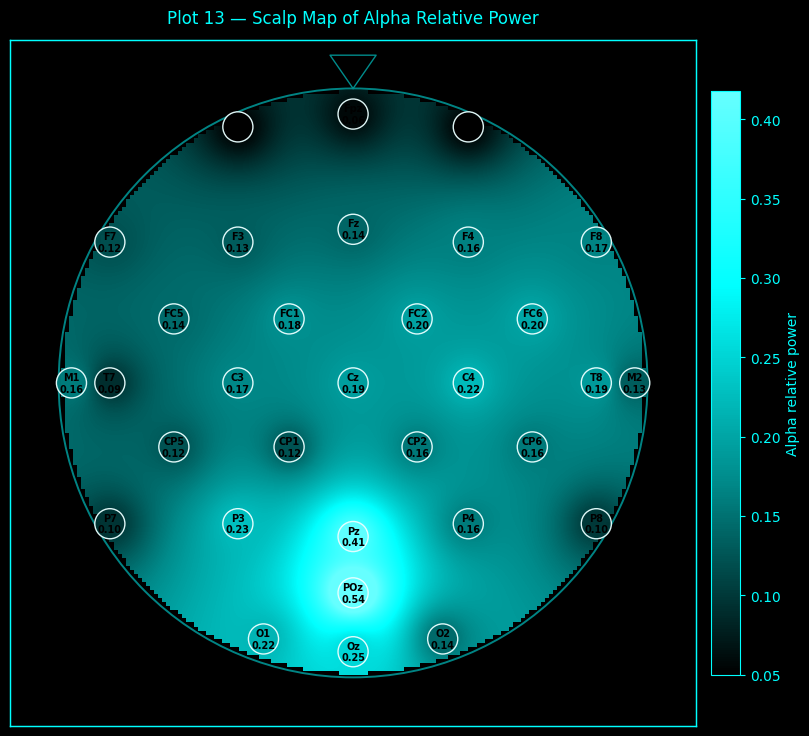

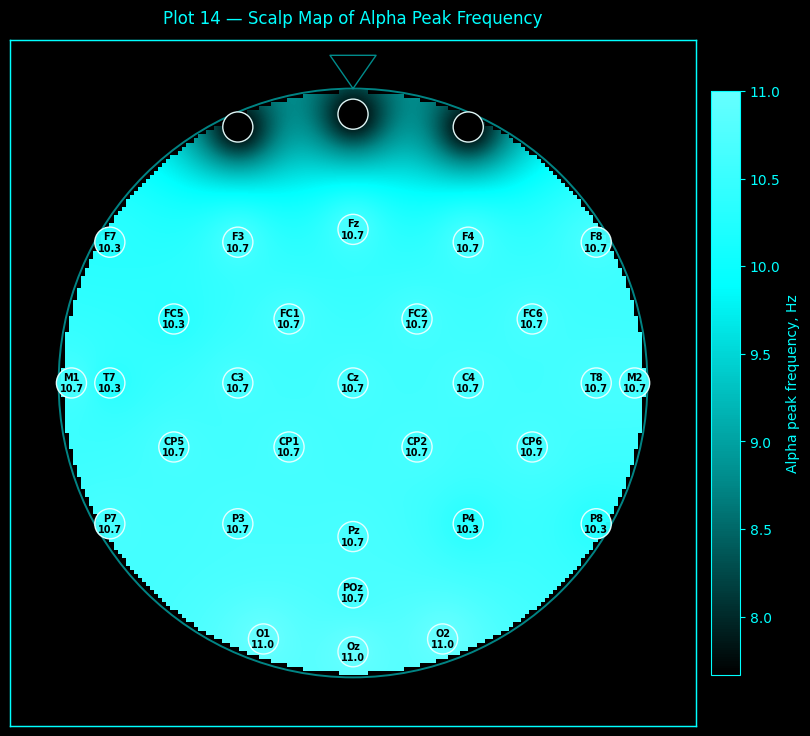

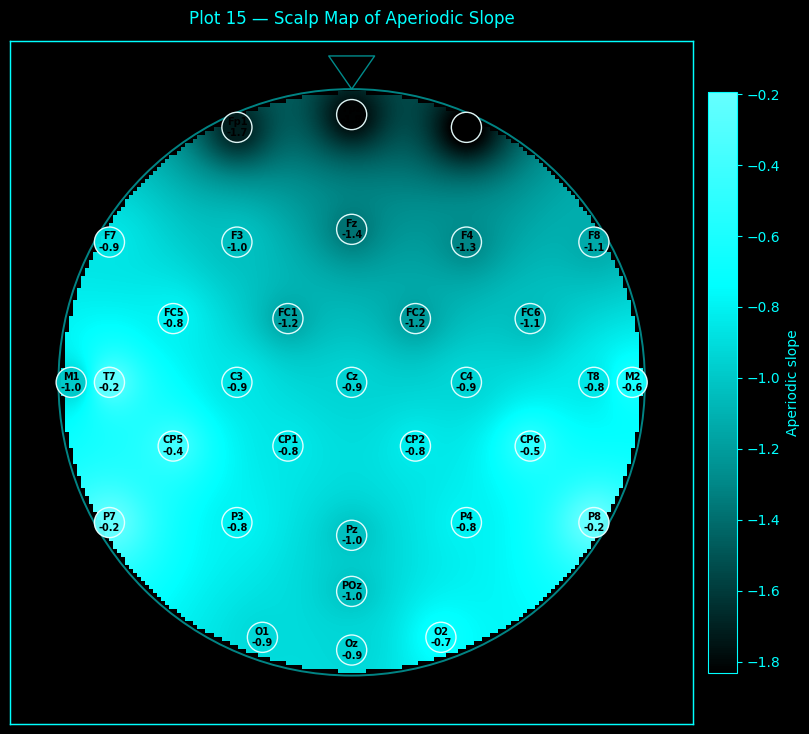

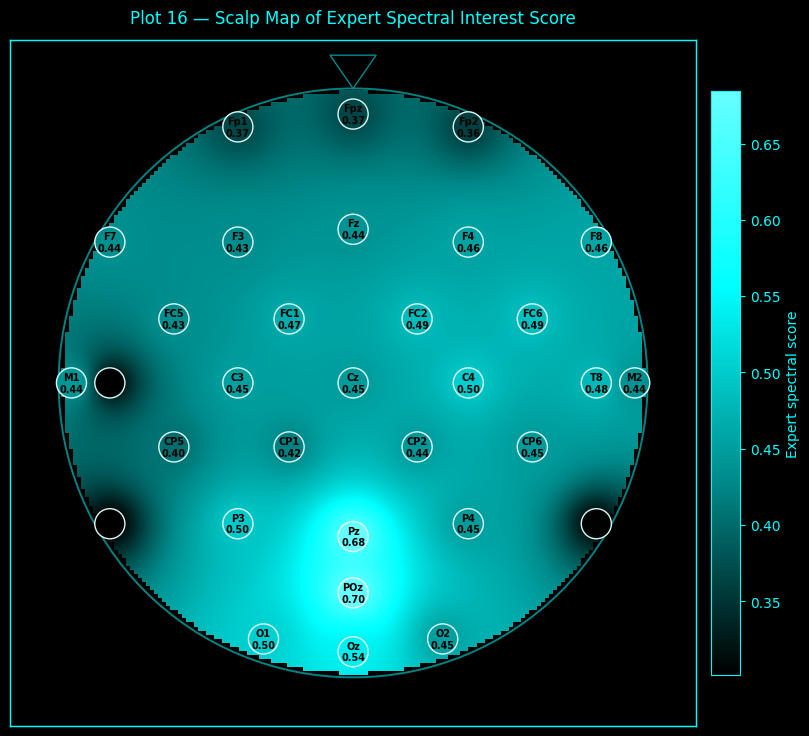

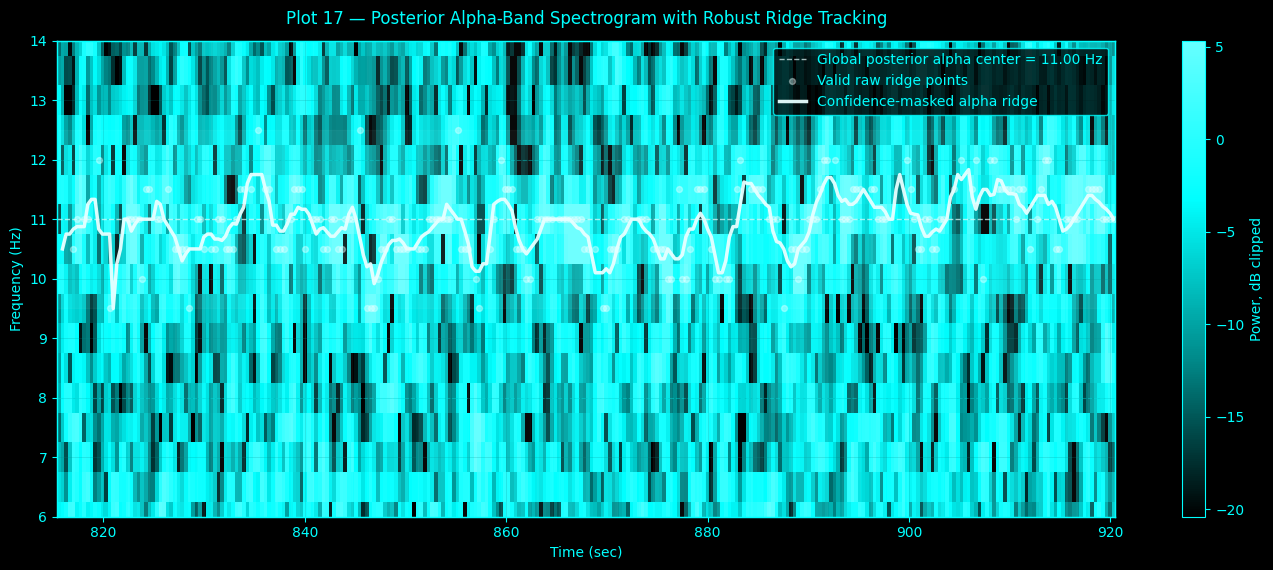

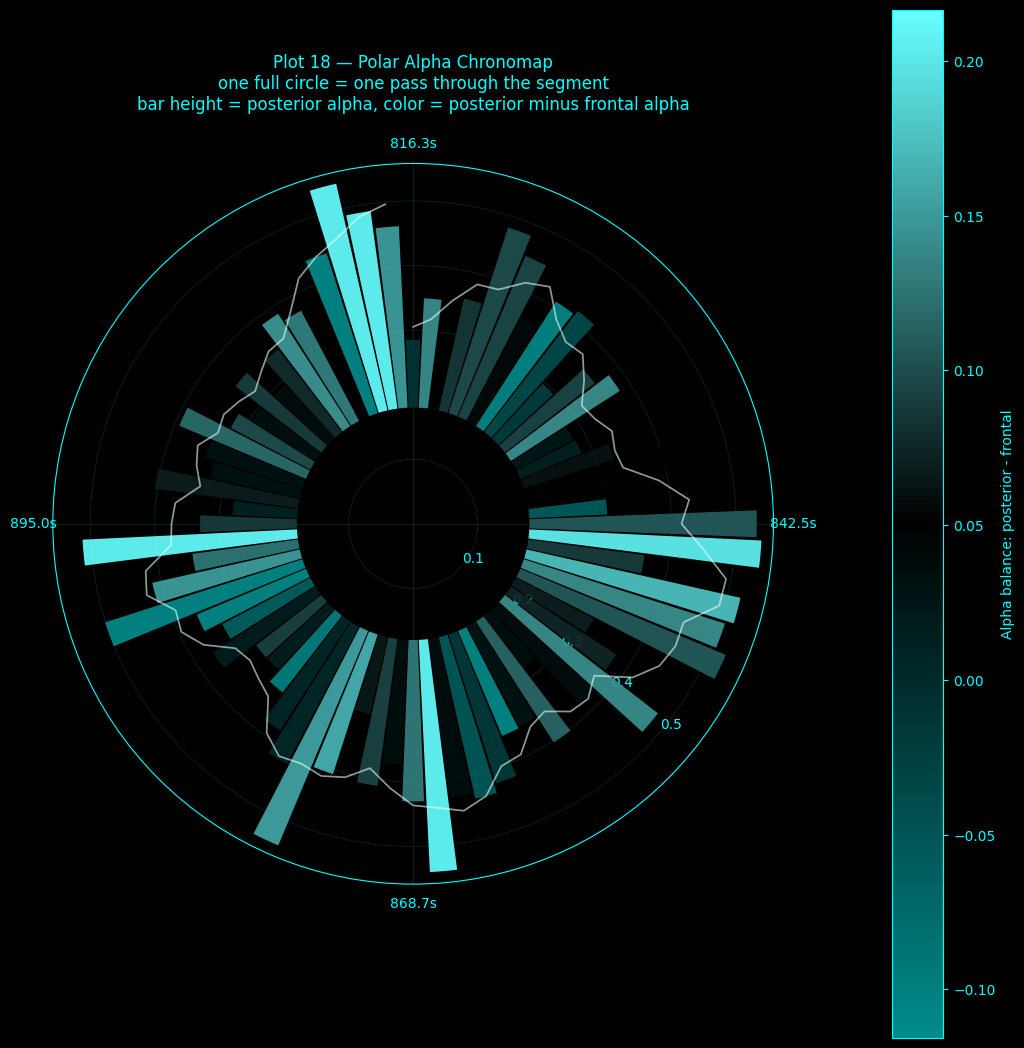

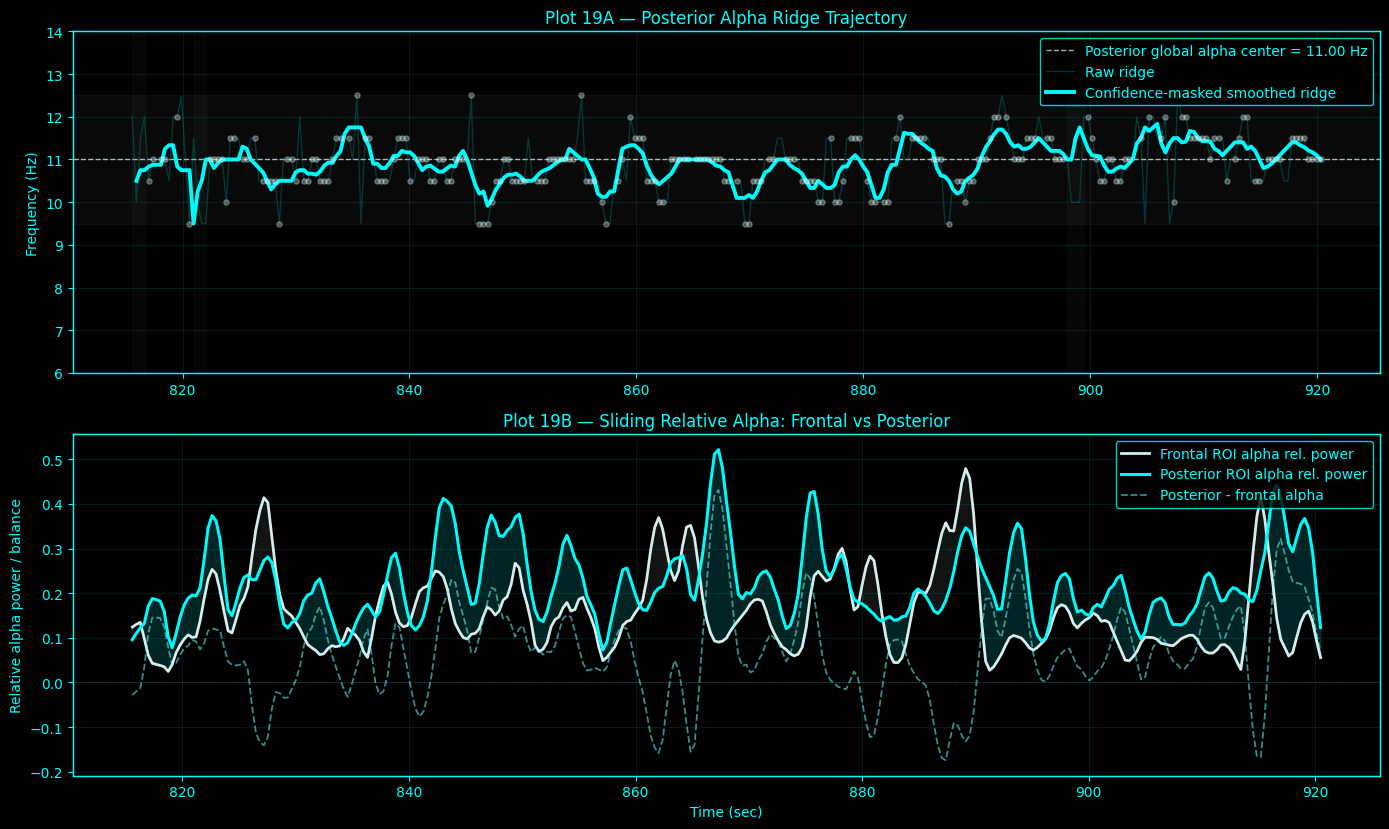

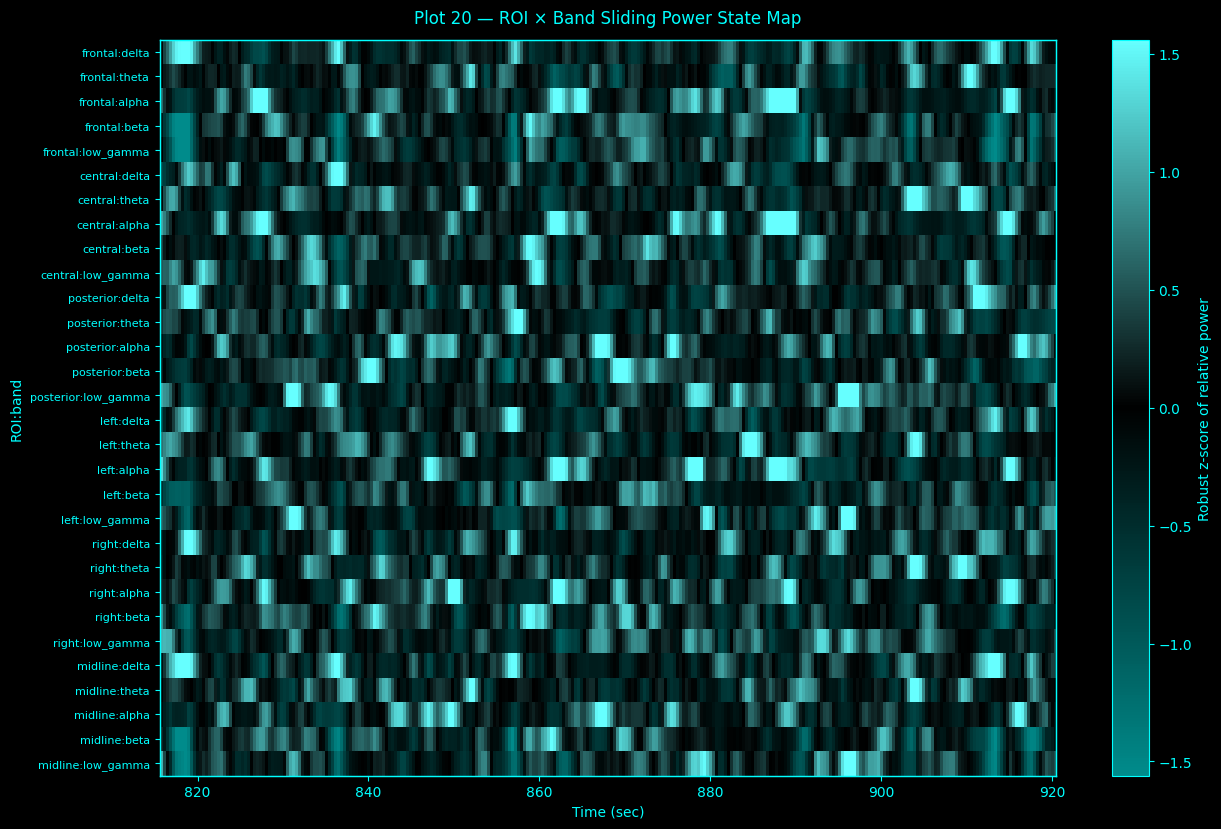


EXPERT EXPLORATORY SPECTRAL ANALYSIS SUMMARY
FAST_OPTION: ultra
Original segment shape: (106944, 32)
Analysis segment shape: (26736, 32)
Analysis sampling rate: 250.00 Hz
Welch frequency bins: 163
Channels analyzed: 32
Elapsed: 0.30 min

Top 15 channels by expert spectral interest score:
channel  expert_spectral_interest_score dominant_band  alpha_relative_power  low_gamma_relative_power  alpha_peak_frequency_Hz  spectral_entropy_1_55Hz  aperiodic_slope_loglog_2_40Hz  aperiodic_fit_r2 hemisphere           region
    POz                        0.700231         alpha              0.544305                  0.048341                10.666667                 0.735898                      -1.032855          0.790944    midline         parietal
     Pz                        0.683318         alpha              0.408464                  0.064856                10.666667                 0.776830                      -1.033061          0.760547    midline         parietal
     Oz                

In [1]:
import os
import time
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import signal

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

FAST_OPTION = "ultra"   # options: "ultra", "fast", "balanced", "full"

if FAST_OPTION == "ultra":
    spectral_downsample_factor = 4
    descriptor_fmax = 55.0
    plot_fmax = 55.0
    spectrogram_fmax = 45.0
    welch_window_sec = 3.0
    welch_overlap = 0.40
    spectrogram_nperseg_sec = 1.5
    spectrogram_overlap_fraction = 0.70
    sliding_window_sec = 2.0
    sliding_step_sec = 0.35
    alpha_ridge_nperseg_sec = 2.0
    alpha_ridge_overlap_fraction = 0.82
    top_n_channels_to_annotate = 5
    top_trace_n = 4
    heatmap_max_time_bins = 1500
    topographic_grid_n = 150
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 170
    zip_outputs = False

elif FAST_OPTION == "fast":
    spectral_downsample_factor = 2
    descriptor_fmax = 55.0
    plot_fmax = 55.0
    spectrogram_fmax = 45.0
    welch_window_sec = 4.0
    welch_overlap = 0.50
    spectrogram_nperseg_sec = 2.0
    spectrogram_overlap_fraction = 0.75
    sliding_window_sec = 2.0
    sliding_step_sec = 0.25
    alpha_ridge_nperseg_sec = 2.0
    alpha_ridge_overlap_fraction = 0.875
    top_n_channels_to_annotate = 6
    top_trace_n = 6
    heatmap_max_time_bins = 2200
    topographic_grid_n = 190
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 190
    zip_outputs = True

elif FAST_OPTION == "balanced":
    spectral_downsample_factor = 1
    descriptor_fmax = 55.0
    plot_fmax = 55.0
    spectrogram_fmax = 45.0
    welch_window_sec = 4.0
    welch_overlap = 0.50
    spectrogram_nperseg_sec = 2.048
    spectrogram_overlap_fraction = 0.75
    sliding_window_sec = 2.0
    sliding_step_sec = 0.25
    alpha_ridge_nperseg_sec = 2.048
    alpha_ridge_overlap_fraction = 0.875
    top_n_channels_to_annotate = 8
    top_trace_n = 8
    heatmap_max_time_bins = 3200
    topographic_grid_n = 220
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 220
    zip_outputs = True

elif FAST_OPTION == "full":
    spectral_downsample_factor = 1
    descriptor_fmax = 55.0
    plot_fmax = 55.0
    spectrogram_fmax = 45.0
    welch_window_sec = 6.0
    welch_overlap = 0.60
    spectrogram_nperseg_sec = 2.048
    spectrogram_overlap_fraction = 0.875
    sliding_window_sec = 2.0
    sliding_step_sec = 0.20
    alpha_ridge_nperseg_sec = 2.048
    alpha_ridge_overlap_fraction = 0.90
    top_n_channels_to_annotate = 10
    top_trace_n = 10
    heatmap_max_time_bins = 5000
    topographic_grid_n = 260
    apply_common_average_reference = False
    apply_notch_60 = True
    notch_q = 35.0
    detrend_mode = "constant"
    show_plots_in_notebook = True
    save_plots_to_disk = True
    dpi_save = 240
    zip_outputs = True

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


out_dir = os.path.join(base_dir, "results", "exploratory_spectral_analysis_expert_fast")
plots_dir = os.path.join(out_dir, "plots")
expert_plots_dir = os.path.join(plots_dir, "expert")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(expert_plots_dir, exist_ok=True)


sampling_rate = 1000
dt_original = 1.0 / sampling_rate

start_time = 814.571
end_time = 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

fmin = 1.0
eps = 1e-12

bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 12.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 45.0),
}

band_names = list(bands.keys())

exclude_slope_bands = [(7.0, 14.0), (48.0, 52.0)]

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

roi_definitions = {
    "frontal": ["Fp1", "Fpz", "Fp2", "F3", "Fz", "F4"],
    "central": ["C3", "Cz", "C4"],
    "posterior": ["P3", "Pz", "P4", "O1", "Oz", "O2"],
    "left": left_channels,
    "right": right_channels,
    "midline": midline_channels,
}

spectrogram_roi = ["P3", "Pz", "P4", "O1", "Oz", "O2"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 10,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True, polar=False):
    ax.set_facecolor(BLACK)

    if polar:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
        ax.spines["polar"].set_color(ACCENT)
        ax.tick_params(colors=ACCENT)
    else:
        for spine in ax.spines.values():
            spine.set_color(ACCENT)
            spine.set_linewidth(1.05)

        ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
        ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

        if grid:
            ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.65)
        else:
            ax.grid(False)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)


def style_cbar(cbar, label):
    cbar.set_label(label, color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)

    for lab in cbar.ax.get_yticklabels():
        lab.set_color(ACCENT)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if save_plots_to_disk and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)

    if show_plots_in_notebook and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif show_plots_in_notebook and show:
        plt.show()

    plt.close(fig)


def safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    return np.where(np.isfinite(x), x, np.nan)


def robust_minmax(x, lo=3, hi=97):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)

    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)

    return np.clip((x - a) / (b - a + eps), 0, 1)


def robust_z(x):
    x = safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25

    if not np.isfinite(iqr) or iqr <= eps:
        return (x - med) / (np.nanstd(finite) + eps)

    return (x - med) / (iqr + eps)


def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x

    if x.shape[0] == n_channels_expected:
        return x.T

    if x.shape[1] > n_channels_expected:
        return x[:, :n_channels_expected]

    if x.shape[0] > n_channels_expected:
        return x.T[:, :n_channels_expected]

    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")


def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x

    return x - np.mean(x, axis=1, keepdims=True)


def apply_notch_filter_multichannel(x, fs, f0=60.0, q=35.0, enabled=True):
    if not enabled:
        return x

    if fs <= 2 * f0:
        return x

    b, a = signal.iirnotch(w0=f0, Q=q, fs=fs)
    return signal.filtfilt(b, a, x, axis=0)


def downsample_multichannel(x, factor):
    x = np.asarray(x, dtype=float)

    if factor <= 1:
        return x

    return signal.resample_poly(x, up=1, down=factor, axis=0)


def welch_psd(x, fs, fmin=1.0, fmax=55.0, window_sec=4.0, overlap=0.5, detrend="constant"):
    nperseg = min(int(round(window_sec * fs)), x.shape[0])
    nperseg = max(nperseg, min(256, x.shape[0]))
    noverlap = int(overlap * nperseg)
    noverlap = min(noverlap, nperseg - 1)

    freqs, psd = signal.welch(
        x,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        axis=0,
    )

    keep = (freqs >= fmin) & (freqs <= fmax)

    return freqs[keep], psd[keep, :]


def bandpower_from_psd(freqs, psd_1d, band):
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)

    if np.sum(mask) < 2:
        return np.nan

    return float(integrate_trapezoid(psd_1d[mask], freqs[mask]))


def total_power(freqs, psd_1d, lo=1.0, hi=55.0):
    mask = (freqs >= lo) & (freqs <= hi)

    if np.sum(mask) < 2:
        return np.nan

    return float(integrate_trapezoid(psd_1d[mask], freqs[mask]))


def spectral_entropy(freqs, psd_1d, lo=1.0, hi=55.0):
    mask = (freqs >= lo) & (freqs <= hi)
    p = np.asarray(psd_1d[mask], dtype=float)
    p = np.maximum(p, 0.0)
    s = np.sum(p)

    if s <= 0:
        return np.nan

    p = p / s
    h = -np.sum(p * np.log(p + eps))
    hmax = np.log(len(p) + eps)

    return float(h / (hmax + eps))


def spectral_edge_frequency(freqs, psd_1d, edge=0.95, lo=1.0, hi=55.0):
    mask = (freqs >= lo) & (freqs <= hi)
    f = freqs[mask]
    p = psd_1d[mask]

    if len(f) < 2:
        return np.nan

    c = np.cumsum(p)

    if c[-1] <= 0:
        return np.nan

    c = c / c[-1]
    idx = np.searchsorted(c, edge)
    idx = min(idx, len(f) - 1)

    return float(f[idx])


def median_frequency(freqs, psd_1d, lo=1.0, hi=55.0):
    return spectral_edge_frequency(freqs, psd_1d, edge=0.50, lo=lo, hi=hi)


def smooth_1d(x, win=5):
    x = np.asarray(x, dtype=float)

    if win <= 1 or len(x) < win:
        return x

    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")


def smooth_nanaware(x, win=7):
    x = np.asarray(x, dtype=float)

    if win <= 1 or len(x) < win:
        return x.copy()

    valid = np.isfinite(x).astype(float)
    x_fill = np.where(np.isfinite(x), x, 0.0)
    kernel = np.ones(win, dtype=float)

    num = np.convolve(x_fill, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    y = num / np.maximum(den, eps)
    y[den < 1] = np.nan

    return y


def peak_frequency(freqs, psd_1d, band=(8.0, 12.0), smooth_win=5):
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)

    if np.sum(mask) < 3:
        return np.nan, np.nan

    f = freqs[mask]
    p = smooth_1d(psd_1d[mask], win=smooth_win)
    idx = int(np.argmax(p))

    return float(f[idx]), float(p[idx])


def estimate_aperiodic_slope(freqs, psd_1d, fit_range=(2.0, 40.0), exclude_bands=None):
    lo, hi = fit_range
    mask = (freqs >= lo) & (freqs <= hi) & np.isfinite(psd_1d) & (psd_1d > 0)

    if exclude_bands is not None:
        for blo, bhi in exclude_bands:
            mask &= ~((freqs >= blo) & (freqs <= bhi))

    if np.sum(mask) < 6:
        return np.nan, np.nan, np.nan

    x = np.log10(freqs[mask])
    y = np.log10(psd_1d[mask] + eps)

    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept

    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)

    return float(slope), float(intercept), float(r2)


def compute_aperiodic_residual_matrix(freqs, psd_matrix, summary_df):
    residual = np.full_like(psd_matrix, np.nan, dtype=float)

    for ch_i, ch_name in enumerate(eeg_channel_names):
        row = summary_df[summary_df["channel"] == ch_name]

        if row.empty:
            continue

        slope = float(row["aperiodic_slope_loglog_2_40Hz"].iloc[0])
        intercept = float(row["aperiodic_intercept_loglog_2_40Hz"].iloc[0])

        if not np.isfinite(slope) or not np.isfinite(intercept):
            continue

        log_psd = np.log10(np.maximum(psd_matrix[:, ch_i], eps))
        model = slope * np.log10(np.maximum(freqs, eps)) + intercept
        residual[:, ch_i] = log_psd - model

    return residual


def compute_channel_summary(freqs, psd_matrix, channel_names, bands_dict):
    rows = []

    for ch_i, ch_name in enumerate(channel_names):
        psd_1d = psd_matrix[:, ch_i]
        p_total = total_power(freqs, psd_1d, lo=fmin, hi=descriptor_fmax)

        alpha_peak_hz, alpha_peak_power = peak_frequency(freqs, psd_1d, band=(7.0, 13.0))

        slope, intercept, slope_r2 = estimate_aperiodic_slope(
            freqs,
            psd_1d,
            fit_range=(2.0, 40.0),
            exclude_bands=exclude_slope_bands,
        )

        row = {
            "channel": ch_name,
            "total_power_1_55Hz": p_total,
            "log10_total_power_1_55Hz": float(np.log10(p_total + eps)) if np.isfinite(p_total) else np.nan,
            "spectral_entropy_1_55Hz": spectral_entropy(freqs, psd_1d, lo=fmin, hi=descriptor_fmax),
            "spectral_edge_95_Hz": spectral_edge_frequency(freqs, psd_1d, edge=0.95, lo=fmin, hi=descriptor_fmax),
            "spectral_edge_80_Hz": spectral_edge_frequency(freqs, psd_1d, edge=0.80, lo=fmin, hi=descriptor_fmax),
            "median_frequency_Hz": median_frequency(freqs, psd_1d, lo=fmin, hi=descriptor_fmax),
            "alpha_peak_frequency_Hz": alpha_peak_hz,
            "alpha_peak_power": alpha_peak_power,
            "log10_alpha_peak_power": float(np.log10(alpha_peak_power + eps)) if np.isfinite(alpha_peak_power) else np.nan,
            "aperiodic_slope_loglog_2_40Hz": slope,
            "aperiodic_intercept_loglog_2_40Hz": intercept,
            "aperiodic_fit_r2": slope_r2,
        }

        for band_name, band_range in bands_dict.items():
            bp = bandpower_from_psd(freqs, psd_1d, band_range)
            row[f"{band_name}_power"] = bp
            row[f"{band_name}_relative_power"] = bp / (p_total + eps)

        row["theta_alpha_ratio"] = row["theta_relative_power"] / (row["alpha_relative_power"] + eps)
        row["alpha_beta_ratio"] = row["alpha_relative_power"] / (row["beta_relative_power"] + eps)
        row["alpha_low_gamma_ratio"] = row["alpha_relative_power"] / (row["low_gamma_relative_power"] + eps)
        row["high_low_balance"] = (row["beta_relative_power"] + row["low_gamma_relative_power"]) - (row["delta_relative_power"] + row["theta_relative_power"])
        row["alpha_dominance"] = row["alpha_relative_power"] - np.nanmean([
            row["delta_relative_power"],
            row["theta_relative_power"],
            row["beta_relative_power"],
            row["low_gamma_relative_power"],
        ])

        rows.append(row)

    summary_df = pd.DataFrame(rows)

    for col in summary_df.columns:
        if col != "channel":
            summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

    z_cols = [
        "spectral_entropy_1_55Hz",
        "alpha_peak_frequency_Hz",
        "log10_alpha_peak_power",
        "aperiodic_slope_loglog_2_40Hz",
        "median_frequency_Hz",
        "alpha_relative_power",
        "low_gamma_relative_power",
        "alpha_dominance",
        "high_low_balance",
    ]

    for col in z_cols:
        if col not in summary_df.columns:
            continue

        x = summary_df[col].to_numpy(dtype=float)
        mu = np.nanmean(x)
        sd = np.nanstd(x)
        summary_df[f"{col}_z"] = (x - mu) / (sd + eps)

    return summary_df


def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")

        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")

    df["hemisphere"] = hemispheres
    df["region"] = regions

    return df


def add_expert_scores(df):
    df = df.copy()

    df["spectral_concentration"] = 1.0 - df["spectral_entropy_1_55Hz"]

    band_rel_cols = [f"{b}_relative_power" for b in band_names]
    M = df[band_rel_cols].to_numpy(dtype=float)
    dominant_idx = np.nanargmax(M, axis=1)
    df["dominant_band"] = [band_names[i] for i in dominant_idx]

    df["expert_spectral_interest_score"] = (
        0.22 * robust_minmax(df["alpha_relative_power"].to_numpy(dtype=float))
        + 0.18 * robust_minmax(df["alpha_dominance"].to_numpy(dtype=float))
        + 0.16 * robust_minmax(df["low_gamma_relative_power"].to_numpy(dtype=float))
        + 0.14 * robust_minmax(df["spectral_concentration"].to_numpy(dtype=float))
        + 0.12 * robust_minmax(df["aperiodic_fit_r2"].to_numpy(dtype=float))
        + 0.10 * robust_minmax(-df["aperiodic_slope_loglog_2_40Hz"].to_numpy(dtype=float))
        + 0.08 * robust_minmax(df["spectral_edge_95_Hz"].to_numpy(dtype=float))
    )

    return df


def compute_roi_signal(segment, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]

    if len(idx) == 0:
        raise ValueError(f"No ROI channels found for ROI: {roi_channels}")

    return np.mean(segment[:, idx], axis=1)


def bandpower_series(x, fs, band, total_band=(1.0, 55.0), window_sec=2.0, step_sec=0.25):
    x = np.asarray(x, dtype=float)
    win = max(int(round(window_sec * fs)), min(256, len(x)))
    step = max(int(round(step_sec * fs)), 1)

    centers = []
    rel_bp = []
    abs_bp = []

    for start in range(0, len(x) - win + 1, step):
        stop = start + win
        chunk = x[start:stop]

        freqs_local, psd = signal.welch(
            chunk,
            fs=fs,
            window="hann",
            nperseg=min(win, 1024),
            noverlap=min(int(0.5 * min(win, 1024)), min(win, 1024) - 1),
            detrend="constant",
            scaling="density",
        )

        keep = (freqs_local >= total_band[0]) & (freqs_local <= total_band[1])
        freqs_keep = freqs_local[keep]
        psd_keep = psd[keep]

        bp = bandpower_from_psd(freqs_keep, psd_keep, band)
        tp = total_power(freqs_keep, psd_keep, lo=total_band[0], hi=total_band[1])

        centers.append((start + stop) / 2.0 / fs)
        abs_bp.append(bp)
        rel_bp.append(bp / (tp + eps))

    return np.array(centers), np.array(abs_bp), np.array(rel_bp)


def robust_clip_image(x, lo=2, hi=98):
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return x.copy(), -1.0, 1.0

    vmin = np.nanpercentile(finite, lo)
    vmax = np.nanpercentile(finite, hi)

    return np.clip(x, vmin, vmax), vmin, vmax


def finite_percentiles(x, q=(5, 95), default=(0.0, 1.0)):
    x = np.asarray(x, dtype=float)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return default

    return tuple(np.nanpercentile(finite, q))


def mask_to_runs(mask):
    mask = np.asarray(mask, dtype=bool)

    if mask.size == 0:
        return []

    runs = []
    in_run = False
    start = 0

    for i, val in enumerate(mask):
        if val and not in_run:
            start = i
            in_run = True
        elif not val and in_run:
            runs.append((start, i))
            in_run = False

    if in_run:
        runs.append((start, len(mask)))

    return runs


def keep_runs_by_duration(runs, t_axis, min_duration_sec=0.0):
    kept = []

    for s, e in runs:
        if e - s <= 0:
            continue

        t0 = t_axis[s]
        t1 = t_axis[e - 1]

        if (t1 - t0) >= min_duration_sec:
            kept.append((s, e))

    return kept


def draw_run_spans(ax, runs, t_axis, color=WHITE, alpha=0.05, zorder=1):
    for s, e in runs:
        if e - s <= 0:
            continue

        left = t_axis[s]
        right = t_axis[e - 1]
        ax.axvspan(left, right, color=color, alpha=alpha, zorder=zorder)


def downsample_heatmap_rows_time(M, t, max_bins):
    M = np.asarray(M, dtype=float)

    if max_bins is None or M.shape[1] <= max_bins:
        return M, t

    step = int(np.ceil(M.shape[1] / max_bins))

    return M[:, ::step], t[::step]


def roi_average_psd(psd_matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]

    if len(idx) == 0:
        return np.full(psd_matrix.shape[0], np.nan)

    return np.nanmean(psd_matrix[:, idx], axis=1)


def plot_metric_topography(summary_df, metric_col, title, cbar_label, path, cmap=CYAN_SEQUENTIAL_CMAP):
    df = summary_df.copy()
    df = df[np.isfinite(df[metric_col])]

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row[metric_col]))
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs)
    ys = np.asarray(ys)
    vals = np.asarray(vals)

    gx = np.linspace(-1.18, 1.18, topographic_grid_n)
    gy = np.linspace(-1.18, 1.18, topographic_grid_n)
    GX, GY = np.meshgrid(gx, gy)
    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2

    Z_num = np.zeros_like(GX)
    Z_den = np.zeros_like(GX)

    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.025 ** 2)
        Z_num += w * v
        Z_den += w

    Z = Z_num / (Z_den + eps)
    Z[~mask] = np.nan

    finite = vals[np.isfinite(vals)]
    vmin = np.nanpercentile(finite, 3) if finite.size else 0
    vmax = np.nanpercentile(finite, 97) if finite.size else 1

    fig, ax = plt.subplots(figsize=(8.2, 8.2), facecolor=BLACK)

    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)
    ax.plot([0.0, -0.09, 0.09, 0.0], [1.15, 1.28, 1.28, 1.15], color=ACCENT_DIM, linewidth=1.0)

    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )

    for x, y, ch, v in zip(xs, ys, labels, vals):
        if "frequency" in metric_col.lower() or "hz" in metric_col.lower():
            label = f"{ch}\n{v:.1f}"
        else:
            label = f"{ch}\n{v:.2f}"

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(ax, title=title, xlabel="", ylabel="", grid=False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    style_cbar(cbar, cbar_label)

    save_fig(fig, path)

    return path


start_all = time.perf_counter()

print("Running expert exploratory spectral analysis", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)

eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment_original = eeg_data[start_index:end_index, :].copy()
segment_original = maybe_common_average_reference(segment_original, enabled=apply_common_average_reference)

segment_original = apply_notch_filter_multichannel(
    segment_original,
    fs=sampling_rate,
    f0=60.0,
    q=notch_q,
    enabled=apply_notch_60,
)

segment = downsample_multichannel(segment_original, spectral_downsample_factor)
fs_analysis = sampling_rate / spectral_downsample_factor
dt = 1.0 / fs_analysis

n_samples, n_channels = segment.shape
time_sec = start_time + np.arange(n_samples) * dt

effective_plot_fmax = min(plot_fmax, 0.45 * fs_analysis)
effective_descriptor_fmax = min(descriptor_fmax, 0.45 * fs_analysis)
effective_spectrogram_fmax = min(spectrogram_fmax, 0.45 * fs_analysis)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Original segment shape: {segment_original.shape}")
print(f"Analysis segment shape: {segment.shape}")
print(f"Analysis sampling rate: {fs_analysis:.2f} Hz")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")

freqs, psd_matrix = welch_psd(
    segment,
    fs=fs_analysis,
    fmin=fmin,
    fmax=effective_plot_fmax,
    window_sec=welch_window_sec,
    overlap=welch_overlap,
    detrend=detrend_mode,
)

summary_df = compute_channel_summary(freqs, psd_matrix, eeg_channel_names, bands)
summary_df = add_channel_metadata(summary_df)
summary_df = add_expert_scores(summary_df)

aperiodic_residual_matrix = compute_aperiodic_residual_matrix(freqs, psd_matrix, summary_df)

psd_npz_path = os.path.join(out_dir, f"exploratory_psd_outputs_{FAST_OPTION}.npz")
summary_csv_path = os.path.join(out_dir, f"channel_spectral_summary_{FAST_OPTION}.csv")
bandpower_csv_path = os.path.join(out_dir, f"channel_relative_bandpower_matrix_{FAST_OPTION}.csv")
summary_txt_path = os.path.join(out_dir, f"exploratory_spectral_notes_{FAST_OPTION}.txt")

band_cols = [f"{b}_relative_power" for b in bands.keys()]

summary_df.to_csv(summary_csv_path, index=False)
summary_df[["channel"] + band_cols].to_csv(bandpower_csv_path, index=False)

np.savez_compressed(
    psd_npz_path,
    freqs=freqs,
    psd_matrix=psd_matrix,
    aperiodic_residual_matrix=aperiodic_residual_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    analysis_sampling_rate=fs_analysis,
    spectral_downsample_factor=spectral_downsample_factor,
    apply_notch_60=apply_notch_60,
    descriptor_fmax=effective_descriptor_fmax,
    plot_fmax=effective_plot_fmax,
    FAST_OPTION=FAST_OPTION,
)

alpha_ranked = summary_df.sort_values("alpha_relative_power", ascending=False).head(8)
flat_ranked = summary_df.sort_values("spectral_entropy_1_55Hz", ascending=True).head(8)
top_score = summary_df.sort_values("expert_spectral_interest_score", ascending=False).head(12)

with open(summary_txt_path, "w") as f:
    f.write("Expert exploratory spectral analysis notes\n")
    f.write("==========================================\n\n")
    f.write("Interpretive status:\n")
    f.write("This remains a hypothesis-generating spectral pass, not a publication pipeline and not a scoring system.\n\n")
    f.write("Key upgrades:\n")
    f.write("1. Added FAST_OPTION modes for runtime control.\n")
    f.write("2. Optional analysis downsampling is used while preserving sub-55 Hz structure.\n")
    f.write("3. Scalar descriptors avoid the 60 Hz edge.\n")
    f.write("4. Added aperiodic slope/residual diagnostics, scalp maps, ROI PSDs, descriptor fingerprints, and alpha-ridge plots.\n\n")
    f.write(f"FAST_OPTION: {FAST_OPTION}\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis sampling rate: {fs_analysis:.2f} Hz\n")
    f.write(f"Spectral downsample factor: {spectral_downsample_factor}\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n")
    f.write(f"Notch 60 applied: {apply_notch_60}\n")
    f.write(f"Descriptor range: [{fmin:.1f}, {effective_descriptor_fmax:.1f}] Hz\n")
    f.write(f"Display range: [{fmin:.1f}, {effective_plot_fmax:.1f}] Hz\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Top channels by expert spectral interest score:\n")
    for _, row in top_score.iterrows():
        f.write(
            f"  {row['channel']}: score={row['expert_spectral_interest_score']:.6f}, "
            f"dominant_band={row['dominant_band']}, "
            f"alpha_rel={row['alpha_relative_power']:.4f}, "
            f"low_gamma_rel={row['low_gamma_relative_power']:.4f}, "
            f"entropy={row['spectral_entropy_1_55Hz']:.4f}, "
            f"slope={row['aperiodic_slope_loglog_2_40Hz']:.4f}\n"
        )

    f.write("\nHighest alpha-relative-power channels:\n")
    for _, row in alpha_ranked.iterrows():
        f.write(
            f"  {row['channel']}: alpha_rel={row['alpha_relative_power']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.2f} Hz, "
            f"slope={row['aperiodic_slope_loglog_2_40Hz']:.3f}\n"
        )

    f.write("\nLowest spectral-entropy channels:\n")
    for _, row in flat_ranked.iterrows():
        f.write(
            f"  {row['channel']}: entropy={row['spectral_entropy_1_55Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.2f} Hz, "
            f"median_freq={row['median_frequency_Hz']:.2f} Hz\n"
        )


plot_paths = []

median_psd = np.median(psd_matrix, axis=1)
q25_psd = np.quantile(psd_matrix, 0.25, axis=1)
q75_psd = np.quantile(psd_matrix, 0.75, axis=1)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BLACK)

for band_name, (lo, hi) in bands.items():
    if hi <= effective_plot_fmax:
        ax.axvspan(lo, hi, alpha=0.045, color=WHITE)
        ax.text(
            (lo + hi) / 2.0,
            np.nanmax(median_psd) * 1.15,
            band_name,
            ha="center",
            va="bottom",
            fontsize=9,
            color=ACCENT_SOFT,
        )

ax.semilogy(freqs, median_psd, linewidth=2.2, color=ACCENT, label="Median across channels")
ax.fill_between(freqs, q25_psd, q75_psd, color=ACCENT, alpha=0.18, label="IQR across channels")
ax.set_xlim(fmin, effective_plot_fmax)

style_ax(
    ax,
    title="Plot 1 — Exploratory PSD Overview of the Selected EEG Segment",
    xlabel="Frequency (Hz)",
    ylabel="PSD",
)

leg = ax.legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, f"01_psd_overview_median_iqr_{FAST_OPTION}.png")
save_fig(fig, plot1_path)
plot_paths.append(plot1_path)


n_cols = 4
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.8 * n_rows), facecolor=BLACK, sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

for ch_i, ch_name in enumerate(eeg_channel_names):
    ax = axes[ch_i]
    ax.semilogy(freqs, psd_matrix[:, ch_i], color=ACCENT, linewidth=1.0, alpha=0.95)
    ax.set_title(ch_name, fontsize=10, color=ACCENT)
    ax.set_xlim(fmin, effective_plot_fmax)

    alpha_peak = summary_df.loc[summary_df["channel"] == ch_name, "alpha_peak_frequency_Hz"].values[0]

    if np.isfinite(alpha_peak):
        ax.axvline(alpha_peak, color=WHITE, linestyle="--", linewidth=0.8, alpha=0.65)

    style_ax(ax)

for ax in axes[n_channels:]:
    ax.axis("off")

for i, ax in enumerate(axes):
    if i % n_cols == 0 and i < n_channels:
        ax.set_ylabel("PSD", color=ACCENT)
    if i >= (n_rows - 1) * n_cols and i < n_channels:
        ax.set_xlabel("Hz", color=ACCENT)

fig.suptitle("Plot 2 — Channel-wise Welch PSDs with Alpha-Peak Markers", fontsize=14, color=ACCENT, y=0.995)
plot2_path = os.path.join(plots_dir, f"02_channel_psd_grid_{FAST_OPTION}.png")
save_fig(fig, plot2_path)
plot_paths.append(plot2_path)


heatmap_matrix = summary_df[[f"{b}_relative_power" for b in bands.keys()]].values

fig, ax = plt.subplots(figsize=(8.5, 10), facecolor=BLACK)

im = ax.imshow(
    heatmap_matrix,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_SEQUENTIAL_CMAP,
    vmin=np.nanpercentile(heatmap_matrix, 2),
    vmax=np.nanpercentile(heatmap_matrix, 98),
)

ax.set_xticks(np.arange(len(bands)))
ax.set_xticklabels(list(bands.keys()), rotation=0, color=ACCENT)
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_yticklabels(eeg_channel_names, color=ACCENT)

for i in range(heatmap_matrix.shape[0]):
    for j in range(heatmap_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color=BLACK if heatmap_matrix[i, j] > np.nanpercentile(heatmap_matrix, 75) else ACCENT_SOFT,
        )

style_ax(
    ax,
    title="Plot 3 — Relative Bandpower by Channel",
    xlabel="Band",
    ylabel="Channel",
    grid=False,
)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Relative power")

plot3_path = os.path.join(plots_dir, f"03_relative_bandpower_heatmap_{FAST_OPTION}.png")
save_fig(fig, plot3_path)
plot_paths.append(plot3_path)


fig, ax = plt.subplots(figsize=(10, 7), facecolor=BLACK)

scatter = ax.scatter(
    summary_df["aperiodic_slope_loglog_2_40Hz"].values,
    summary_df["spectral_entropy_1_55Hz"].values,
    c=summary_df["alpha_relative_power"].values,
    s=90 + 260 * robust_minmax(summary_df["expert_spectral_interest_score"].values),
    alpha=0.90,
    cmap=CYAN_SEQUENTIAL_CMAP,
    edgecolors=WHITE,
    linewidths=0.7,
)

interesting = summary_df.sort_values("expert_spectral_interest_score", ascending=False).head(top_n_channels_to_annotate)

for _, row in interesting.iterrows():
    ax.text(
        row["aperiodic_slope_loglog_2_40Hz"] + 0.01,
        row["spectral_entropy_1_55Hz"] + 0.002,
        row["channel"],
        fontsize=9,
        color=ACCENT_SOFT,
    )

style_ax(
    ax,
    title="Plot 4 — Channel Descriptor Space\nmarker size = expert spectral interest score",
    xlabel="Aperiodic slope, log-log 2–40 Hz",
    ylabel="Spectral entropy, 1–55 Hz",
)

cbar = plt.colorbar(scatter, ax=ax)
style_cbar(cbar, "Alpha relative power")

plot4_path = os.path.join(plots_dir, f"04_descriptor_space_scatter_{FAST_OPTION}.png")
save_fig(fig, plot4_path)
plot_paths.append(plot4_path)


roi_signal = compute_roi_signal(segment, eeg_channel_names, spectrogram_roi)

spec_nperseg = min(int(round(spectrogram_nperseg_sec * fs_analysis)), len(roi_signal))
spec_nperseg = max(spec_nperseg, min(256, len(roi_signal)))
spec_noverlap = min(int(round(spectrogram_overlap_fraction * spec_nperseg)), spec_nperseg - 1)

f_spec, t_spec, sxx = signal.spectrogram(
    roi_signal,
    fs=fs_analysis,
    window="hann",
    nperseg=spec_nperseg,
    noverlap=spec_noverlap,
    detrend="constant",
    scaling="density",
    mode="psd",
)

keep_f = (f_spec >= 1.0) & (f_spec <= effective_spectrogram_fmax)
f_spec_plot5 = f_spec[keep_f]
sxx_plot5 = sxx[keep_f, :]
sxx_db = 10.0 * np.log10(sxx_plot5 + eps)

row_median = np.median(sxx_db, axis=1, keepdims=True)
sxx_centered = sxx_db - row_median
sxx_display, vmin, vmax = robust_clip_image(sxx_centered, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 5.5), facecolor=BLACK)

mesh = ax.pcolormesh(start_time + t_spec, f_spec_plot5, sxx_display, shading="auto", cmap=CYAN_SEQUENTIAL_CMAP, vmin=vmin, vmax=vmax)

style_ax(
    ax,
    title="Plot 5 — Posterior ROI Spectrogram\nrow-centered dB, exploratory",
    xlabel="Time (sec)",
    ylabel="Frequency (Hz)",
)

ax.set_ylim(1, effective_spectrogram_fmax)

cbar = plt.colorbar(mesh, ax=ax)
style_cbar(cbar, "Centered power, dB clipped")

plot5_path = os.path.join(plots_dir, f"05_posterior_roi_spectrogram_{FAST_OPTION}.png")
save_fig(fig, plot5_path)
plot_paths.append(plot5_path)


frontal_signal = compute_roi_signal(segment, eeg_channel_names, roi_definitions["frontal"])
posterior_signal = compute_roi_signal(segment, eeg_channel_names, roi_definitions["posterior"])

t_fr, _, rel_alpha_fr = bandpower_series(
    frontal_signal,
    fs=fs_analysis,
    band=bands["alpha"],
    total_band=(fmin, effective_descriptor_fmax),
    window_sec=sliding_window_sec,
    step_sec=sliding_step_sec,
)

t_po, _, rel_alpha_po = bandpower_series(
    posterior_signal,
    fs=fs_analysis,
    band=bands["alpha"],
    total_band=(fmin, effective_descriptor_fmax),
    window_sec=sliding_window_sec,
    step_sec=sliding_step_sec,
)

rel_alpha_fr_s = smooth_1d(rel_alpha_fr, win=5)
rel_alpha_po_s = smooth_1d(rel_alpha_po, win=5)

fig, ax = plt.subplots(figsize=(13, 4.8), facecolor=BLACK)

ax.plot(start_time + t_fr, rel_alpha_fr_s, color=WHITE, linewidth=1.9, alpha=0.92, label="Frontal ROI alpha rel. power")
ax.plot(start_time + t_po, rel_alpha_po_s, color=ACCENT, linewidth=2.0, alpha=0.97, label="Posterior ROI alpha rel. power")

style_ax(
    ax,
    title="Plot 6 — Sliding Relative Alpha Power: Frontal vs Posterior",
    xlabel="Time (sec)",
    ylabel="Relative alpha power",
)

leg = ax.legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot6_path = os.path.join(plots_dir, f"06_sliding_relative_alpha_roi_{FAST_OPTION}.png")
save_fig(fig, plot6_path)
plot_paths.append(plot6_path)


band_rel_cols = [f"{b}_relative_power" for b in band_names]
fingerprint_cols = [
    "log10_total_power_1_55Hz",
    "spectral_entropy_1_55Hz",
    "spectral_concentration",
    "median_frequency_Hz",
    "spectral_edge_95_Hz",
    "alpha_peak_frequency_Hz",
    "alpha_relative_power",
    "low_gamma_relative_power",
    "alpha_dominance",
    "alpha_beta_ratio",
    "high_low_balance",
    "aperiodic_slope_loglog_2_40Hz",
    "aperiodic_fit_r2",
    "expert_spectral_interest_score",
]

fingerprint_cols = [c for c in fingerprint_cols if c in summary_df.columns]
fingerprint_df = summary_df.sort_values("expert_spectral_interest_score", ascending=False).copy()
M = fingerprint_df[fingerprint_cols].to_numpy(dtype=float)
Z = np.zeros_like(M)

for j in range(M.shape[1]):
    Z[:, j] = robust_z(M[:, j])

vmax = np.nanpercentile(np.abs(Z[np.isfinite(Z)]), 95) if np.any(np.isfinite(Z)) else 1
vmax = max(vmax, 1e-6)

fig, ax = plt.subplots(figsize=(13, max(7, 0.30 * len(fingerprint_df))), facecolor=BLACK)

im = ax.imshow(
    Z,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_DIVERGING_CMAP,
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(np.arange(len(fingerprint_cols)))
ax.set_xticklabels(fingerprint_cols, rotation=50, ha="right", color=ACCENT, fontsize=8)
ax.set_yticks(np.arange(len(fingerprint_df)))
ax.set_yticklabels(fingerprint_df["channel"], color=ACCENT, fontsize=8)

style_ax(
    ax,
    title="Plot 7 — Expert Spectral Fingerprint Heatmap\nrobust z-scores, rows sorted by interest score",
    xlabel="Descriptor",
    ylabel="Channel",
    grid=False,
)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Robust z-score")

plot7_path = os.path.join(expert_plots_dir, f"07_expert_spectral_fingerprint_heatmap_{FAST_OPTION}.png")
save_fig(fig, plot7_path)
plot_paths.append(plot7_path)


fig, ax = plt.subplots(figsize=(11, 6.5), facecolor=BLACK)

for roi_name, roi_channels in roi_definitions.items():
    roi_psd = roi_average_psd(psd_matrix, eeg_channel_names, roi_channels)
    ax.semilogy(freqs, roi_psd, linewidth=2.0, alpha=0.92, label=roi_name)

style_ax(
    ax,
    title="Plot 8 — ROI-Average Welch PSD Profiles",
    xlabel="Frequency (Hz)",
    ylabel="PSD",
)

ax.set_xlim(fmin, effective_plot_fmax)

leg = ax.legend(loc="best", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot8_path = os.path.join(expert_plots_dir, f"08_roi_average_psd_profiles_{FAST_OPTION}.png")
save_fig(fig, plot8_path)
plot_paths.append(plot8_path)


resid_order = summary_df.sort_values("expert_spectral_interest_score", ascending=False)["channel"].tolist()
resid_idx = [eeg_channel_names.index(ch) for ch in resid_order]
resid_heat = aperiodic_residual_matrix[:, resid_idx].T

vmin, vmax = np.nanpercentile(resid_heat, 2), np.nanpercentile(resid_heat, 98)
vabs = max(abs(vmin), abs(vmax), eps)

fig, ax = plt.subplots(figsize=(13, max(7, 0.30 * len(resid_order))), facecolor=BLACK)

im = ax.imshow(
    resid_heat,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_DIVERGING_CMAP,
    vmin=-vabs,
    vmax=vabs,
    extent=[freqs[0], freqs[-1], len(resid_order), 0],
)

ax.set_yticks(np.arange(len(resid_order)) + 0.5)
ax.set_yticklabels(resid_order, color=ACCENT, fontsize=8)

style_ax(
    ax,
    title="Plot 9 — Aperiodic-Adjusted Spectral Residuals\npositive values indicate narrowband excess above 1/f fit",
    xlabel="Frequency (Hz)",
    ylabel="Channel",
    grid=False,
)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "log10 PSD residual")

plot9_path = os.path.join(expert_plots_dir, f"09_aperiodic_adjusted_residual_heatmap_{FAST_OPTION}.png")
save_fig(fig, plot9_path)
plot_paths.append(plot9_path)


fig, ax = plt.subplots(figsize=(10, 7), facecolor=BLACK)

scatter = ax.scatter(
    summary_df["alpha_dominance"],
    summary_df["low_gamma_relative_power"],
    c=summary_df["aperiodic_slope_loglog_2_40Hz"],
    s=95 + 260 * robust_minmax(summary_df["expert_spectral_interest_score"]),
    cmap=CYAN_DIVERGING_CMAP,
    edgecolors=WHITE,
    linewidths=0.7,
    alpha=0.90,
)

top = summary_df.sort_values("expert_spectral_interest_score", ascending=False).head(top_n_channels_to_annotate)

for _, row in top.iterrows():
    ax.annotate(
        row["channel"],
        (row["alpha_dominance"], row["low_gamma_relative_power"]),
        xytext=(5, 5),
        textcoords="offset points",
        color=ACCENT_SOFT,
        fontsize=8,
    )

style_ax(
    ax,
    title="Plot 10 — Alpha Dominance vs Low-Gamma Weight\ncolor = aperiodic slope, size = interest score",
    xlabel="Alpha dominance",
    ylabel="Low-gamma relative power",
)

cbar = plt.colorbar(scatter, ax=ax)
style_cbar(cbar, "Aperiodic slope")

plot10_path = os.path.join(expert_plots_dir, f"10_alpha_dominance_vs_low_gamma_{FAST_OPTION}.png")
save_fig(fig, plot10_path)
plot_paths.append(plot10_path)


top_score_channels = summary_df.sort_values("expert_spectral_interest_score", ascending=False).head(top_trace_n)["channel"].tolist()
n = len(top_score_channels)
ncols = 2
nrows = int(math.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows), facecolor=BLACK, sharex=True, squeeze=False)
axes = axes.ravel()

for ax in axes:
    ax.set_facecolor(BLACK)
    ax.axis("off")

for ax, ch_name in zip(axes, top_score_channels):
    ax.axis("on")
    ch_idx = eeg_channel_names.index(ch_name)

    ax.semilogy(freqs, psd_matrix[:, ch_idx], color=ACCENT, linewidth=1.3, alpha=0.95, label="PSD")

    resid = aperiodic_residual_matrix[:, ch_idx]
    resid_scaled = np.nanmedian(psd_matrix[:, ch_idx]) * (10 ** resid)
    ax.semilogy(freqs, resid_scaled, color=WHITE, linewidth=0.9, alpha=0.55, label="Aperiodic residual shape")

    row = summary_df[summary_df["channel"] == ch_name].iloc[0]

    if np.isfinite(row["alpha_peak_frequency_Hz"]):
        ax.axvline(row["alpha_peak_frequency_Hz"], color=WHITE, linestyle="--", alpha=0.65, linewidth=0.9)

    style_ax(
        ax,
        title=f"{ch_name} | score={row['expert_spectral_interest_score']:.2f}, dom={row['dominant_band']}",
        xlabel="Frequency (Hz)",
        ylabel="PSD",
    )

handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(handles, labels, loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

fig.suptitle("Plot 11 — Top Score Channels: PSD + Aperiodic Residual Shape", color=ACCENT, y=0.995)

plot11_path = os.path.join(expert_plots_dir, f"11_top_score_channel_psd_gallery_{FAST_OPTION}.png")
save_fig(fig, plot11_path)
plot_paths.append(plot11_path)


rank_df = summary_df.sort_values("expert_spectral_interest_score", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, max(7, 0.30 * len(rank_df))), facecolor=BLACK)

y = np.arange(len(rank_df))

ax.barh(
    y,
    rank_df["expert_spectral_interest_score"],
    color=ACCENT,
    edgecolor=ACCENT_SOFT,
    alpha=0.84,
)

ax.set_yticks(y)
ax.set_yticklabels(rank_df["channel"], color=ACCENT, fontsize=8)

for yi, (_, row) in zip(y, rank_df.iterrows()):
    ax.text(
        row["expert_spectral_interest_score"],
        yi,
        f"  dom={row['dominant_band']}, α={row['alpha_relative_power']:.2f}, γ={row['low_gamma_relative_power']:.2f}",
        va="center",
        ha="left",
        color=ACCENT_SOFT,
        fontsize=7,
    )

style_ax(
    ax,
    title="Plot 12 — Expert Spectral Interest Score Ranking",
    xlabel="Composite spectral score",
    ylabel="Channel",
)

plot12_path = os.path.join(expert_plots_dir, f"12_expert_spectral_score_ranking_{FAST_OPTION}.png")
save_fig(fig, plot12_path)
plot_paths.append(plot12_path)


plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="alpha_relative_power",
    title="Plot 13 — Scalp Map of Alpha Relative Power",
    cbar_label="Alpha relative power",
    path=os.path.join(expert_plots_dir, f"13_topographic_alpha_relative_power_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="alpha_peak_frequency_Hz",
    title="Plot 14 — Scalp Map of Alpha Peak Frequency",
    cbar_label="Alpha peak frequency, Hz",
    path=os.path.join(expert_plots_dir, f"14_topographic_alpha_peak_frequency_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="aperiodic_slope_loglog_2_40Hz",
    title="Plot 15 — Scalp Map of Aperiodic Slope",
    cbar_label="Aperiodic slope",
    path=os.path.join(expert_plots_dir, f"15_topographic_aperiodic_slope_{FAST_OPTION}.png"),
))

plot_paths.append(plot_metric_topography(
    summary_df,
    metric_col="expert_spectral_interest_score",
    title="Plot 16 — Scalp Map of Expert Spectral Interest Score",
    cbar_label="Expert spectral score",
    path=os.path.join(expert_plots_dir, f"16_topographic_expert_spectral_score_{FAST_OPTION}.png"),
))


t_fr_abs = start_time + t_fr
t_po_abs = start_time + t_po

t_common_start = max(t_fr_abs[0], t_po_abs[0])
t_common_end = min(t_fr_abs[-1], t_po_abs[-1])
n_common = min(len(t_fr_abs), len(t_po_abs))

t_common = np.linspace(t_common_start, t_common_end, n_common)

fr_common = np.interp(t_common, t_fr_abs, rel_alpha_fr_s)
po_common = np.interp(t_common, t_po_abs, rel_alpha_po_s)
alpha_balance = po_common - fr_common


f_post_roi, psd_post_roi = signal.welch(
    posterior_signal,
    fs=fs_analysis,
    window="hann",
    nperseg=min(int(round(4 * fs_analysis)), len(posterior_signal)),
    noverlap=min(int(round(2 * fs_analysis)), len(posterior_signal) - 1),
    detrend="constant",
    scaling="density",
)

roi_keep = (f_post_roi >= 6.0) & (f_post_roi <= 14.0)
f_post_alpha = f_post_roi[roi_keep]
psd_post_alpha = smooth_1d(psd_post_roi[roi_keep], win=5)
global_alpha_center = float(f_post_alpha[np.argmax(psd_post_alpha)])

search_lo = max(8.0, global_alpha_center - 1.5)
search_hi = min(12.5, global_alpha_center + 1.5)

alpha_nperseg = min(int(round(alpha_ridge_nperseg_sec * fs_analysis)), len(posterior_signal))
alpha_nperseg = max(alpha_nperseg, min(256, len(posterior_signal)))
alpha_noverlap = min(int(round(alpha_ridge_overlap_fraction * alpha_nperseg)), alpha_nperseg - 1)

f_spec_alpha, t_spec_alpha, sxx_alpha_full = signal.spectrogram(
    posterior_signal,
    fs=fs_analysis,
    window="hann",
    nperseg=alpha_nperseg,
    noverlap=alpha_noverlap,
    detrend="constant",
    scaling="density",
    mode="psd",
)

keep_alpha = (f_spec_alpha >= 6.0) & (f_spec_alpha <= 14.0)
f_alpha = f_spec_alpha[keep_alpha]
sxx_alpha = sxx_alpha_full[keep_alpha, :]
sxx_alpha_db = 10.0 * np.log10(sxx_alpha + eps)
t_abs_spec = start_time + t_spec_alpha

sxx_alpha_disp, alp_vmin, alp_vmax = robust_clip_image(sxx_alpha_db, lo=2, hi=98)

search_mask = (f_alpha >= search_lo) & (f_alpha <= search_hi)
f_search = f_alpha[search_mask]
sxx_search_db = sxx_alpha_db[search_mask, :]

if f_search.size < 3:
    raise ValueError("Alpha ridge search band is too narrow. Check global_alpha_center / search range.")

ridge_idx = np.argmax(sxx_search_db, axis=0)
alpha_ridge_raw = f_search[ridge_idx]
ridge_peak_db = np.max(sxx_search_db, axis=0)
ridge_floor_db = np.median(sxx_search_db, axis=0)
ridge_conf_db = ridge_peak_db - ridge_floor_db

conf_lo, conf_hi = finite_percentiles(ridge_conf_db, q=(25, 90), default=(0.0, 1.0))
conf_threshold = conf_lo
alpha_valid = np.isfinite(alpha_ridge_raw) & np.isfinite(ridge_conf_db) & (ridge_conf_db >= conf_threshold)

alpha_ridge_masked = np.where(alpha_valid, alpha_ridge_raw, np.nan)
alpha_ridge = smooth_nanaware(alpha_ridge_masked, win=7)

if np.any(~np.isfinite(alpha_ridge) & np.isfinite(alpha_ridge_masked)):
    fill_mask = ~np.isfinite(alpha_ridge) & np.isfinite(alpha_ridge_masked)
    alpha_ridge[fill_mask] = alpha_ridge_masked[fill_mask]


valid_runs = mask_to_runs(alpha_valid)
invalid_runs = mask_to_runs(~alpha_valid)

valid_runs_plot = keep_runs_by_duration(valid_runs, t_abs_spec, min_duration_sec=0.40)
invalid_runs_plot = keep_runs_by_duration(invalid_runs, t_abs_spec, min_duration_sec=0.60)

ridge_csv_path = os.path.join(out_dir, f"posterior_alpha_ridge_timeseries_{FAST_OPTION}.csv")

np.savetxt(
    ridge_csv_path,
    np.column_stack([
        t_abs_spec,
        alpha_ridge_raw,
        alpha_ridge,
        ridge_conf_db,
        alpha_valid.astype(int),
    ]),
    delimiter=",",
    header="time_sec,raw_ridge_hz,smoothed_ridge_hz,confidence_db,valid_flag",
    comments="",
)

fig, ax = plt.subplots(figsize=(14, 5.8), facecolor=BLACK)

im = ax.pcolormesh(
    t_abs_spec,
    f_alpha,
    sxx_alpha_disp,
    shading="auto",
    cmap=CYAN_SEQUENTIAL_CMAP,
    vmin=alp_vmin,
    vmax=alp_vmax,
)

ax.axhspan(search_lo, search_hi, color=WHITE, alpha=0.045, zorder=1)

draw_run_spans(
    ax,
    valid_runs_plot,
    t_abs_spec,
    color=WHITE,
    alpha=0.035,
    zorder=2,
)

ax.axhline(
    global_alpha_center,
    color=WHITE,
    linestyle="--",
    linewidth=1.0,
    alpha=0.70,
    label=f"Global posterior alpha center = {global_alpha_center:.2f} Hz",
)

ax.scatter(
    t_abs_spec[alpha_valid],
    alpha_ridge_raw[alpha_valid],
    s=18,
    color=WHITE,
    alpha=0.38,
    zorder=4,
    label="Valid raw ridge points",
)

ax.plot(
    t_abs_spec,
    alpha_ridge,
    color=WHITE,
    linewidth=2.5,
    alpha=0.95,
    zorder=5,
    label="Confidence-masked alpha ridge",
)

ax.axhline(8.0, color=ACCENT, linestyle="--", alpha=0.30, linewidth=0.8)
ax.axhline(12.0, color=ACCENT, linestyle="--", alpha=0.30, linewidth=0.8)
ax.set_ylim(float(np.min(f_alpha)), float(np.max(f_alpha)))

style_ax(
    ax,
    title="Plot 17 — Posterior Alpha-Band Spectrogram with Robust Ridge Tracking",
    xlabel="Time (sec)",
    ylabel="Frequency (Hz)",
)

leg = ax.legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Power, dB clipped")

plot17_path = os.path.join(plots_dir, f"17_posterior_alpha_zoom_ridge_{FAST_OPTION}.png")
save_fig(fig, plot17_path)
plot_paths.append(plot17_path)


n_polar_bins = 72
edges = np.linspace(t_common[0], t_common[-1], n_polar_bins + 1)

polar_post = np.full(n_polar_bins, np.nan)
polar_bal = np.full(n_polar_bins, np.nan)
polar_mid_t = np.full(n_polar_bins, np.nan)

for i in range(n_polar_bins):
    if i < n_polar_bins - 1:
        m = (t_common >= edges[i]) & (t_common < edges[i + 1])
    else:
        m = (t_common >= edges[i]) & (t_common <= edges[i + 1])

    polar_mid_t[i] = 0.5 * (edges[i] + edges[i + 1])

    if np.any(m):
        polar_post[i] = np.nanmedian(po_common[m])
        polar_bal[i] = np.nanmedian(alpha_balance[m])

theta = np.linspace(0, 2 * np.pi, n_polar_bins, endpoint=False)
bar_width = 2 * np.pi / n_polar_bins * 0.90

post_lo, post_hi = finite_percentiles(polar_post, q=(5, 95), default=(0.0, 1.0))
post_norm = np.clip((polar_post - post_lo) / max(post_hi - post_lo, eps), 0, 1)

bal_lo, bal_hi = finite_percentiles(polar_bal, q=(5, 95), default=(-1.0, 1.0))
polar_bal_clip = np.clip(polar_bal, bal_lo, bal_hi)

bottom = 0.18
height = 0.10 + 0.26 * post_norm
r_line = smooth_nanaware(bottom + height, win=5)

fig = plt.figure(figsize=(10.6, 10.6), facecolor=BLACK)
ax = fig.add_subplot(111, projection="polar")
style_ax(ax, polar=True)

norm = plt.Normalize(vmin=bal_lo, vmax=bal_hi)
colors = CYAN_DIVERGING_CMAP(norm(polar_bal_clip))

ax.bar(
    theta,
    height,
    width=bar_width,
    bottom=bottom,
    color=colors,
    edgecolor="none",
    alpha=0.92,
    align="center",
    zorder=2,
)

ax.plot(
    theta,
    r_line,
    color=WHITE,
    linewidth=1.25,
    alpha=0.60,
    zorder=3,
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

quarter_angles = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
quarter_idx = [0, n_polar_bins // 4, n_polar_bins // 2, 3 * n_polar_bins // 4]
quarter_labels = [f"{polar_mid_t[i]:.1f}s" for i in quarter_idx]

ax.set_xticks(quarter_angles)
ax.set_xticklabels(quarter_labels, color=ACCENT)
ax.set_rlabel_position(130)

ax.set_title(
    "Plot 18 — Polar Alpha Chronomap\n"
    "one full circle = one pass through the segment\n"
    "bar height = posterior alpha, color = posterior minus frontal alpha",
    color=ACCENT,
    pad=20,
)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=CYAN_DIVERGING_CMAP), ax=ax, pad=0.12)
style_cbar(cbar, "Alpha balance: posterior - frontal")

plot18_path = os.path.join(plots_dir, f"18_polar_temporal_alpha_balance_{FAST_OPTION}.png")
save_fig(fig, plot18_path)
plot_paths.append(plot18_path)


fig, axes = plt.subplots(2, 1, figsize=(14, 8.4), facecolor=BLACK, sharex=False)

for ax in axes:
    style_ax(ax)

axes[0].axhspan(search_lo, search_hi, color=WHITE, alpha=0.040, zorder=1)

axes[0].axhline(
    global_alpha_center,
    color=WHITE,
    linestyle="--",
    linewidth=1.0,
    alpha=0.70,
    label=f"Posterior global alpha center = {global_alpha_center:.2f} Hz",
)

axes[0].plot(
    t_abs_spec,
    alpha_ridge_raw,
    color=ACCENT_DIM,
    linewidth=1.0,
    alpha=0.35,
    label="Raw ridge",
)

axes[0].scatter(
    t_abs_spec[alpha_valid],
    alpha_ridge_raw[alpha_valid],
    s=14,
    color=WHITE,
    alpha=0.30,
    zorder=3,
)

axes[0].plot(
    t_abs_spec,
    alpha_ridge,
    color=ACCENT,
    linewidth=2.8,
    alpha=0.98,
    label="Confidence-masked smoothed ridge",
)

draw_run_spans(
    axes[0],
    invalid_runs_plot,
    t_abs_spec,
    color=WHITE,
    alpha=0.028,
    zorder=0,
)

axes[0].set_title("Plot 19A — Posterior Alpha Ridge Trajectory", color=ACCENT)
axes[0].set_ylabel("Frequency (Hz)", color=ACCENT)
axes[0].set_ylim(float(np.min(f_alpha)), float(np.max(f_alpha)))

leg = axes[0].legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

axes[1].plot(
    t_common,
    fr_common,
    color=WHITE,
    linewidth=2.0,
    alpha=0.92,
    label="Frontal ROI alpha rel. power",
)

axes[1].plot(
    t_common,
    po_common,
    color=ACCENT,
    linewidth=2.2,
    alpha=0.98,
    label="Posterior ROI alpha rel. power",
)

axes[1].fill_between(
    t_common,
    fr_common,
    po_common,
    where=(po_common >= fr_common),
    color=ACCENT,
    alpha=0.14,
)

axes[1].fill_between(
    t_common,
    fr_common,
    po_common,
    where=(po_common < fr_common),
    color=WHITE,
    alpha=0.08,
)

axes[1].plot(
    t_common,
    alpha_balance,
    color=ACCENT_SOFT,
    linewidth=1.3,
    alpha=0.55,
    linestyle="--",
    label="Posterior - frontal alpha",
)

axes[1].axhline(0.0, color=WHITE, linewidth=0.8, alpha=0.20, linestyle=":")
axes[1].set_title("Plot 19B — Sliding Relative Alpha: Frontal vs Posterior", color=ACCENT)
axes[1].set_xlabel("Time (sec)", color=ACCENT)
axes[1].set_ylabel("Relative alpha power / balance", color=ACCENT)

leg = axes[1].legend(loc="upper right", frameon=True)
for text in leg.get_texts():
    text.set_color(ACCENT)

plot19_path = os.path.join(plots_dir, f"19_alpha_ridge_and_roi_alpha_timeseries_{FAST_OPTION}.png")
save_fig(fig, plot19_path)
plot_paths.append(plot19_path)


roi_band_rows = []
roi_band_labels = []
roi_t = None

for roi_name, roi_channels in roi_definitions.items():
    roi_sig = compute_roi_signal(segment, eeg_channel_names, roi_channels)

    for band_name, band_range in bands.items():
        t_tmp, _, rel_tmp = bandpower_series(
            roi_sig,
            fs=fs_analysis,
            band=band_range,
            total_band=(fmin, effective_descriptor_fmax),
            window_sec=sliding_window_sec,
            step_sec=sliding_step_sec,
        )

        rel_z = robust_z(rel_tmp)
        roi_band_rows.append(smooth_nanaware(rel_z, win=5))
        roi_band_labels.append(f"{roi_name}:{band_name}")

        if roi_t is None:
            roi_t = start_time + t_tmp

roi_band_M = np.vstack(roi_band_rows)
roi_band_M_ds, roi_t_ds = downsample_heatmap_rows_time(roi_band_M, roi_t, heatmap_max_time_bins)
vmin, vmax = np.nanpercentile(roi_band_M_ds, 2), np.nanpercentile(roi_band_M_ds, 98)
vabs = max(abs(vmin), abs(vmax), eps)

fig, ax = plt.subplots(figsize=(13, max(7, 0.28 * len(roi_band_labels))), facecolor=BLACK)

im = ax.imshow(
    roi_band_M_ds,
    aspect="auto",
    interpolation="nearest",
    cmap=CYAN_DIVERGING_CMAP,
    vmin=-vabs,
    vmax=vabs,
    extent=[roi_t_ds[0], roi_t_ds[-1], len(roi_band_labels), 0],
)

ax.set_yticks(np.arange(len(roi_band_labels)) + 0.5)
ax.set_yticklabels(roi_band_labels, color=ACCENT, fontsize=8)

style_ax(
    ax,
    title="Plot 20 — ROI × Band Sliding Power State Map",
    xlabel="Time (sec)",
    ylabel="ROI:band",
    grid=False,
)

cbar = plt.colorbar(im, ax=ax)
style_cbar(cbar, "Robust z-score of relative power")

plot20_path = os.path.join(expert_plots_dir, f"20_roi_band_sliding_state_map_{FAST_OPTION}.png")
save_fig(fig, plot20_path)
plot_paths.append(plot20_path)


plot_paths = [p for p in plot_paths if p is not None]

zip_path = None

if zip_outputs:
    zip_path = os.path.join(out_dir, f"spectral_analysis_outputs_and_plots_{FAST_OPTION}.zip")

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for p in [psd_npz_path, summary_csv_path, bandpower_csv_path, summary_txt_path, ridge_csv_path]:
            if os.path.exists(p):
                zipf.write(p, arcname=os.path.basename(p))

        for root, _, files in os.walk(plots_dir):
            for file in files:
                if file.lower().endswith(".png"):
                    full = os.path.join(root, file)
                    arc = os.path.relpath(full, out_dir)
                    zipf.write(full, arcname=arc)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 94)
print("EXPERT EXPLORATORY SPECTRAL ANALYSIS SUMMARY")
print("=" * 94)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Original segment shape: {segment_original.shape}")
print(f"Analysis segment shape: {segment.shape}")
print(f"Analysis sampling rate: {fs_analysis:.2f} Hz")
print(f"Welch frequency bins: {len(freqs)}")
print(f"Channels analyzed: {len(summary_df)}")
print(f"Elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 15 channels by expert spectral interest score:")
cols = [
    "channel",
    "expert_spectral_interest_score",
    "dominant_band",
    "alpha_relative_power",
    "low_gamma_relative_power",
    "alpha_peak_frequency_Hz",
    "spectral_entropy_1_55Hz",
    "aperiodic_slope_loglog_2_40Hz",
    "aperiodic_fit_r2",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in summary_df.columns]
print(summary_df.sort_values("expert_spectral_interest_score", ascending=False)[cols].head(15).to_string(index=False))

print("\nHighest alpha-relative-power channels:")
alpha_cols = [
    "channel",
    "alpha_relative_power",
    "alpha_peak_frequency_Hz",
    "alpha_dominance",
    "alpha_beta_ratio",
    "aperiodic_slope_loglog_2_40Hz",
    "hemisphere",
    "region",
]
alpha_cols = [c for c in alpha_cols if c in summary_df.columns]
print(summary_df.sort_values("alpha_relative_power", ascending=False)[alpha_cols].head(10).to_string(index=False))

print("\nRegional summary:")
regional_summary = (
    summary_df.groupby("region")
    .agg(
        mean_alpha=("alpha_relative_power", "mean"),
        mean_low_gamma=("low_gamma_relative_power", "mean"),
        mean_alpha_peak=("alpha_peak_frequency_Hz", "mean"),
        mean_entropy=("spectral_entropy_1_55Hz", "mean"),
        mean_slope=("aperiodic_slope_loglog_2_40Hz", "mean"),
        mean_score=("expert_spectral_interest_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"PSD NPZ: {psd_npz_path}")
print(f"Channel summary CSV: {summary_csv_path}")
print(f"Bandpower CSV: {bandpower_csv_path}")
print(f"Notes TXT: {summary_txt_path}")
print(f"Ridge CSV: {ridge_csv_path}")

if zip_path is not None:
    print(f"ZIP: {zip_path}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nDone.")

# Fast Fourier Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This analysis is focused on computing the Power Spectral Density (PSD) of electroencephalogram (EEG) data via Fast Fourier Transform (FFT). Understanding the frequency composition of EEG signals has critical applications in neuroscience research and diagnostics.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Data Selection: Extract the EEG data for individual channels.</li>
            <li>Fourier Analysis: Compute the PSD using FFT.</li>
            <li>Data Visualization: Render the computed PSD values.</li>
        </ul>
        <h2>Mathematical Formulations</h2>
        <h3>Data Selection and Parameter Definition</h3>
        <p>The EEG data, represented by the array \( \text{eeg\_data\_array} \), is segregated into individual channels. The sampling frequency \( f_s \) is defined to establish the time intervals between successive samples.</p>
       <h3>FFT-based PSD Computation</h3>
        <p>For each EEG channel, the FFT is computed as per the following formula:</p>
        \[ \text{FFT}(x) = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \cdot 2 \pi \cdot f \cdot n / N} \]
        <p>Subsequently, PSD is derived from the FFT values using:</p>
        \[ \text{PSD} = |\text{FFT}(x)|^2 \]
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Computational Steps</h2>
        <p>A Python loop enumerates through each EEG channel, extracts the corresponding EEG data, and computes the PSD using FFT. The PSD values for each channel are stored in a Python dictionary, \( \text{fft\_psd\_data} \).</p>
        <h2>Data Visualization</h2>
        <p>The frequency components of the PSD are plotted using Matplotlib. The frequency axis is determined by the function \( \text{fftfreq} \), which takes into account the length of the PSD and the sampling frequency. Each subplot corresponds to a specific EEG channel, and the y-axis employs a logarithmic scale to improve clarity.</p>
        <h2>Data Storage</h2>
        <p>The computed PSD values are saved as a single NumPy file for further analysis or scientific research. The saved path is specified, and the data is serialized in the .npy format.</p>
        <h2>Scientific Relevance</h2>
        <p>The FFT-based approach to PSD analysis serves as a robust technique for investigating neural oscillations, brain connectivity, and other physiological phenomena of interest. The method is computationally efficient and widely applicable in both research and clinical settings.</p>
    </div>
</div>

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


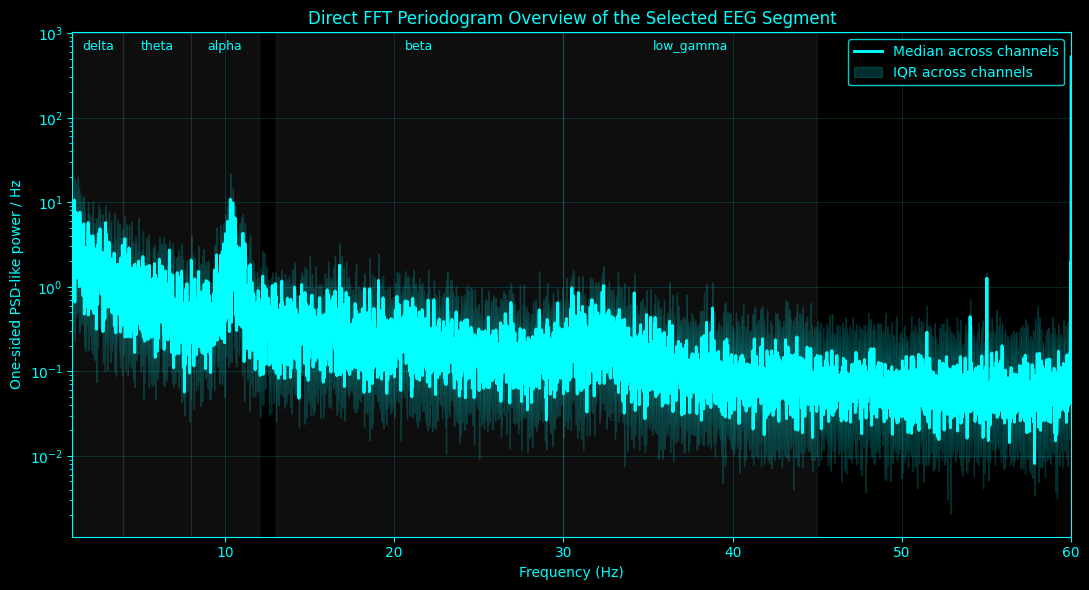

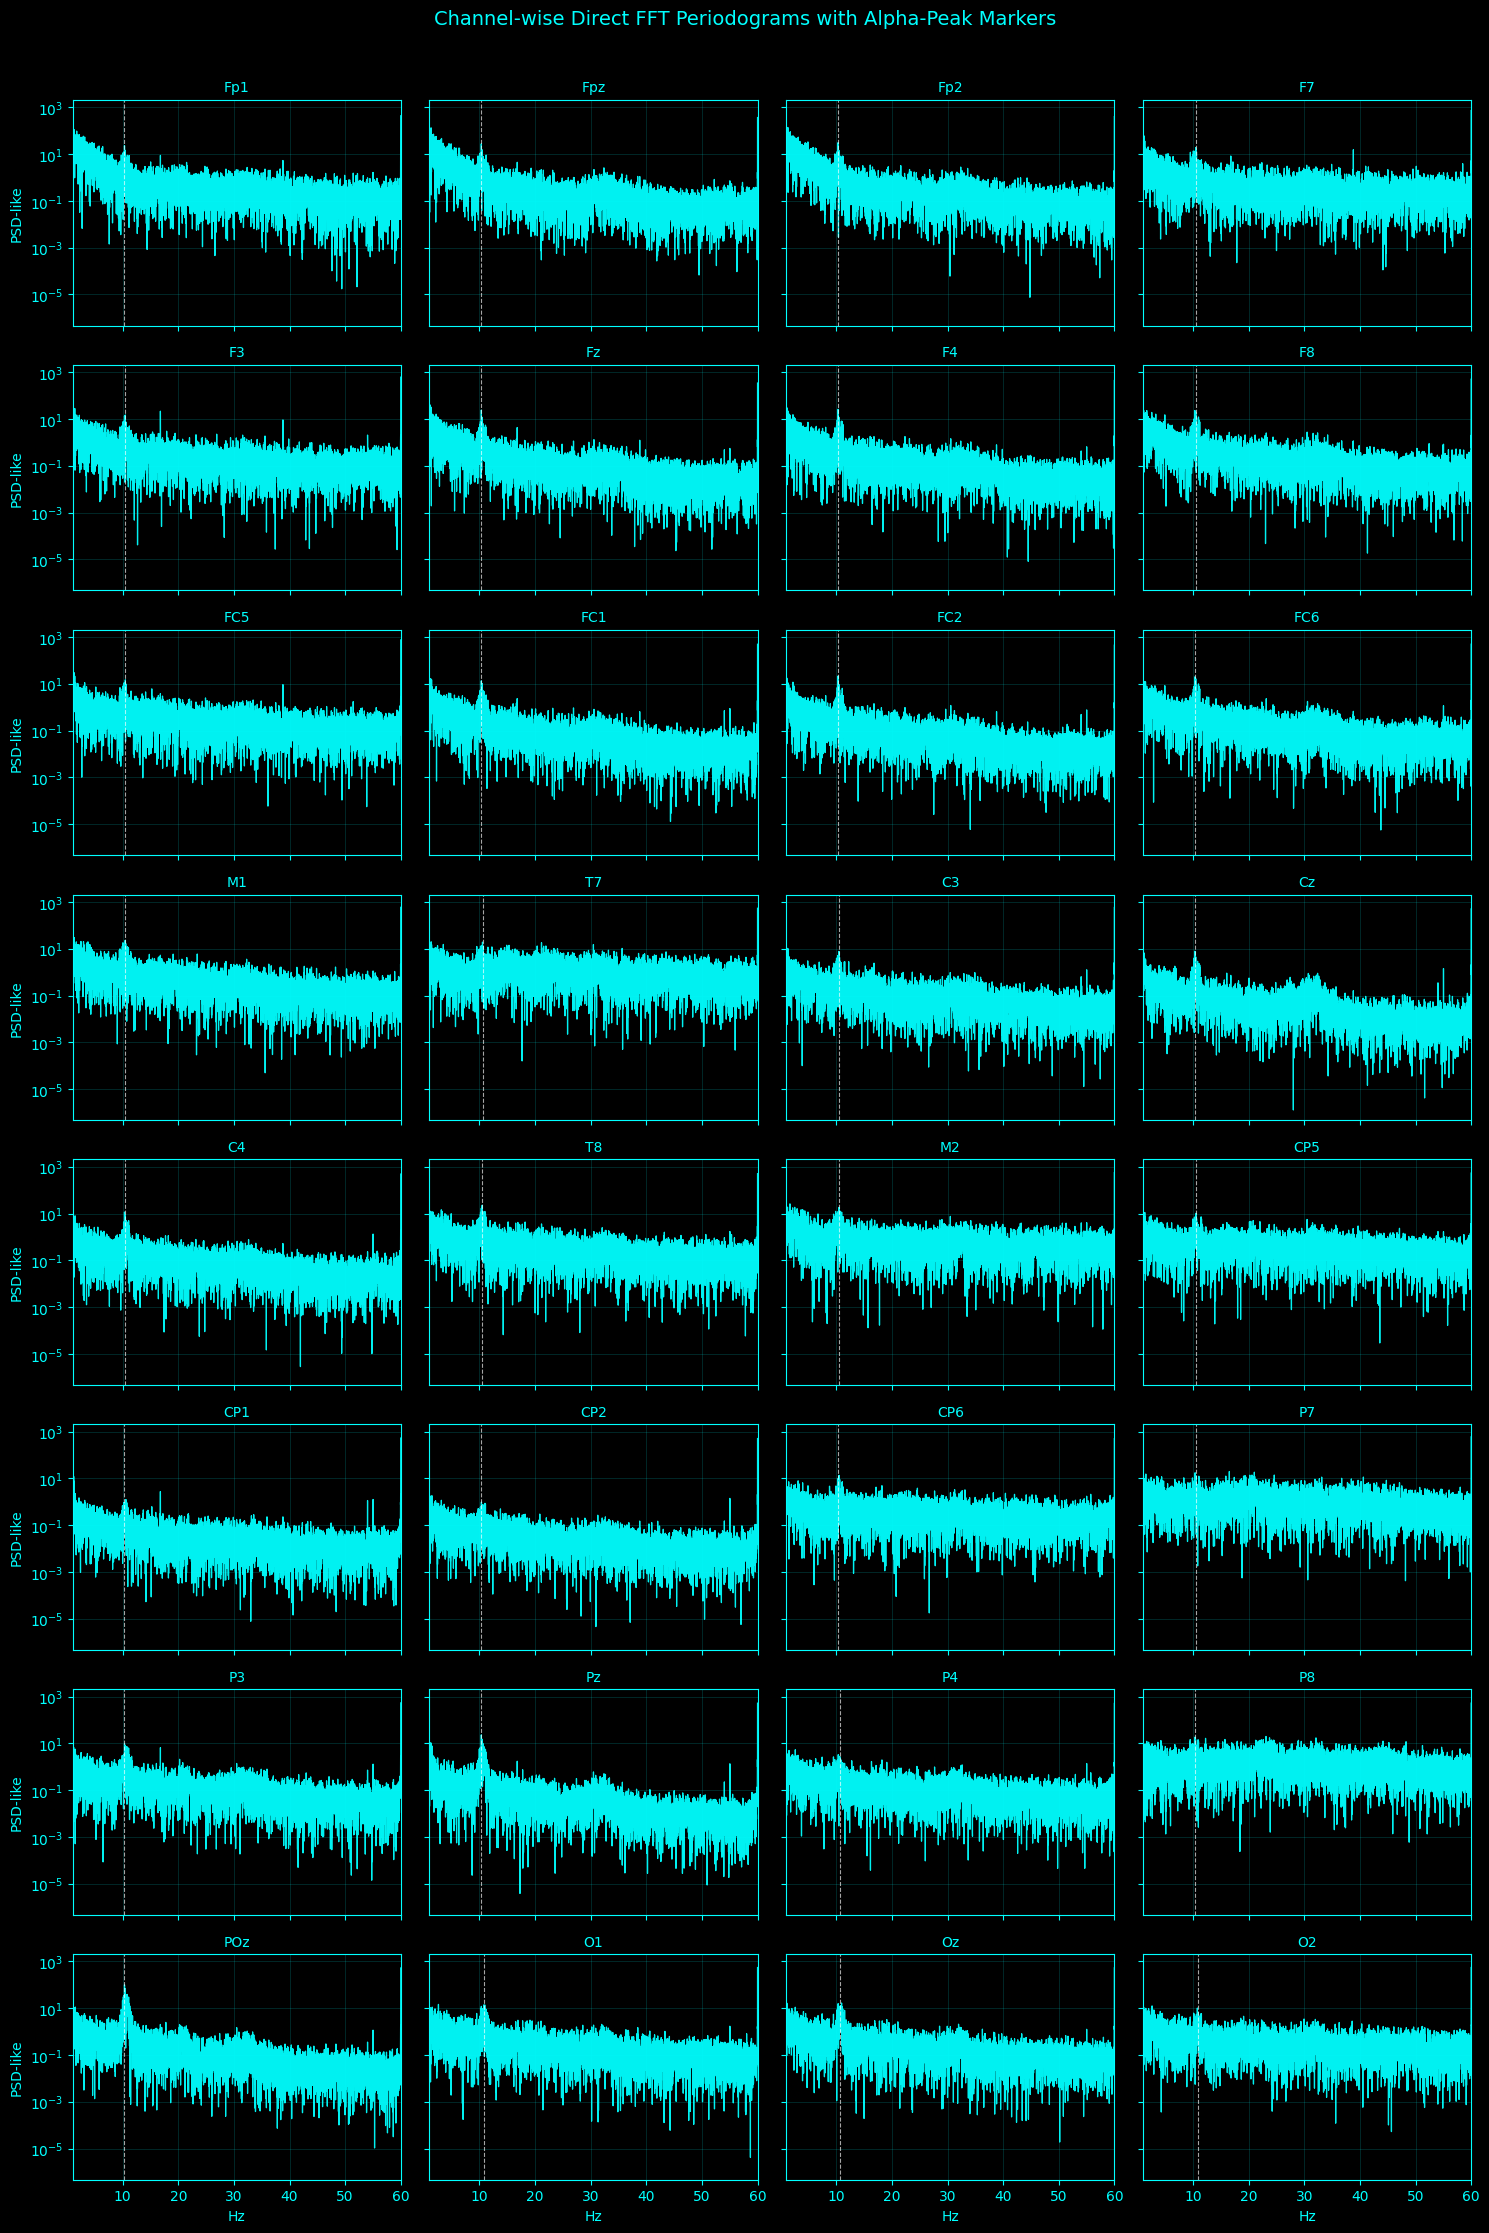

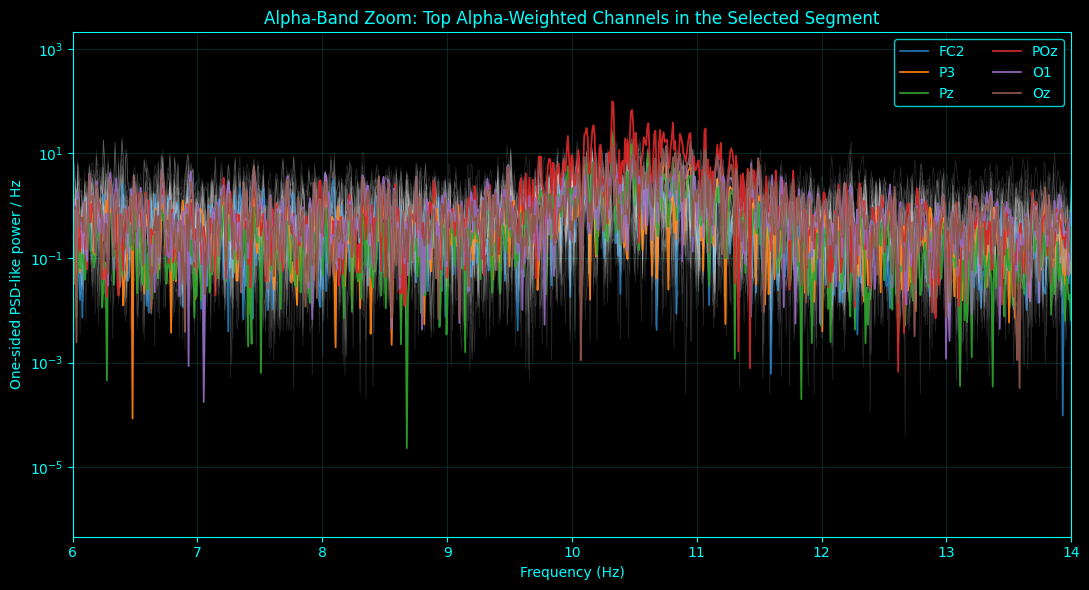

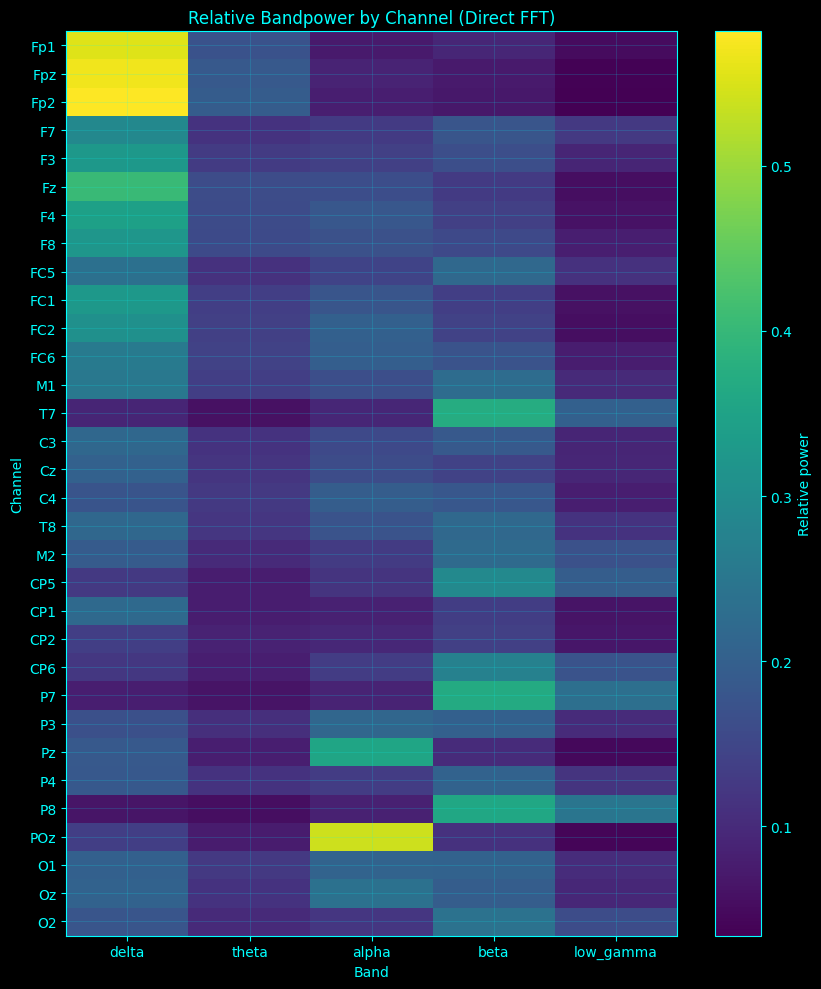

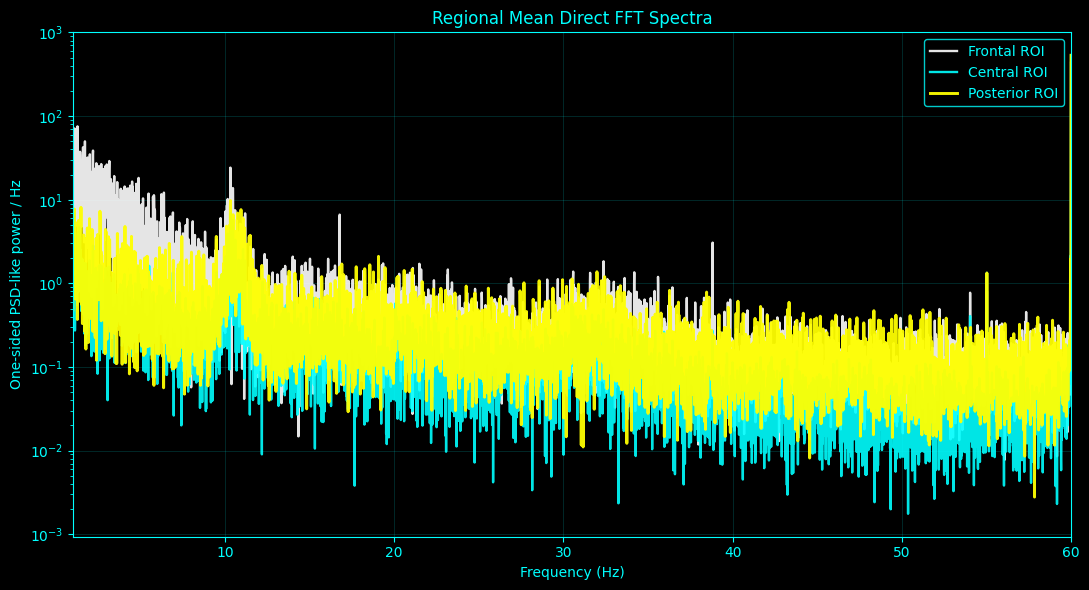

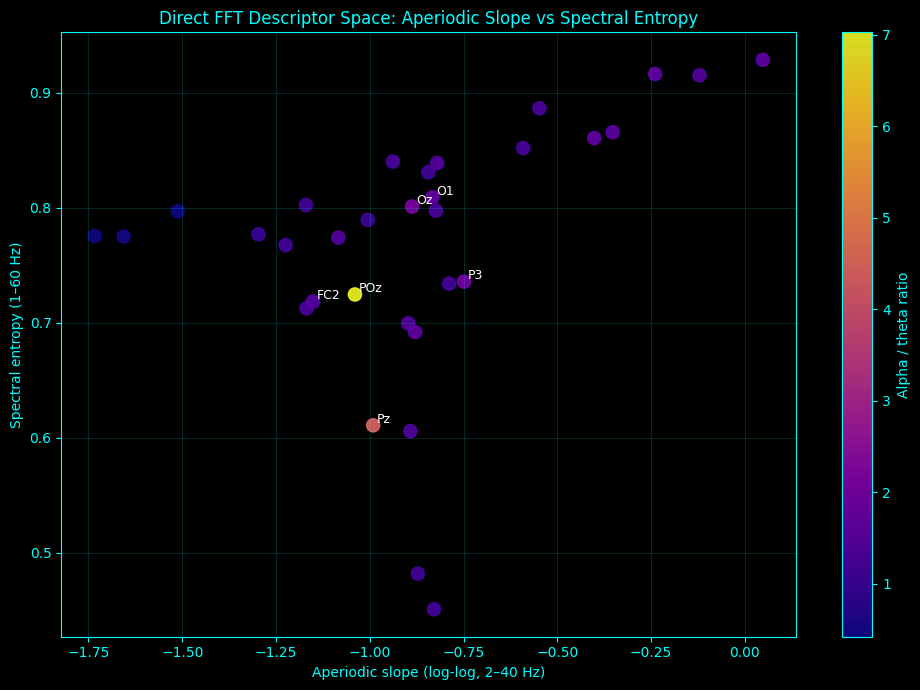


Saved FFT NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/exploratory_direct_fft_outputs.npz
Saved channel summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/channel_direct_fft_summary.csv
Saved bandpower CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/channel_direct_fft_relative_bandpower.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/exploratory_direct_fft_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots
Loaded direct FFT outputs from: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/exploratory_direct_fft_outputs.npz
Loaded summary CSV from: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/channel_direct_fft_summary.csv
Loaded EEG segment from: /home/a/proje

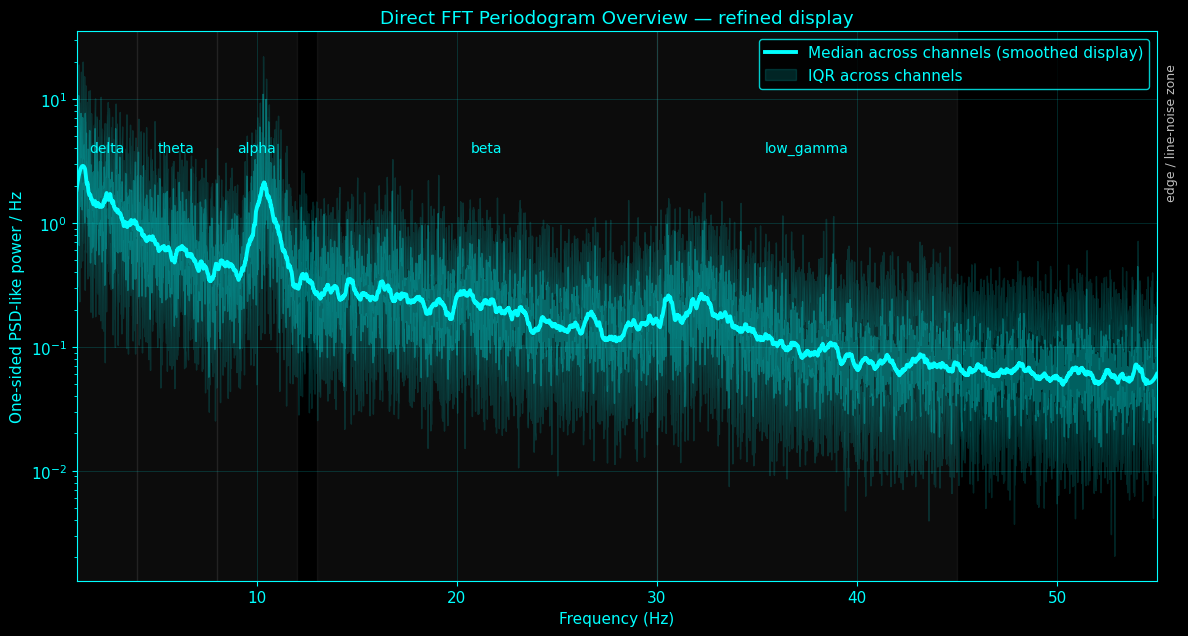

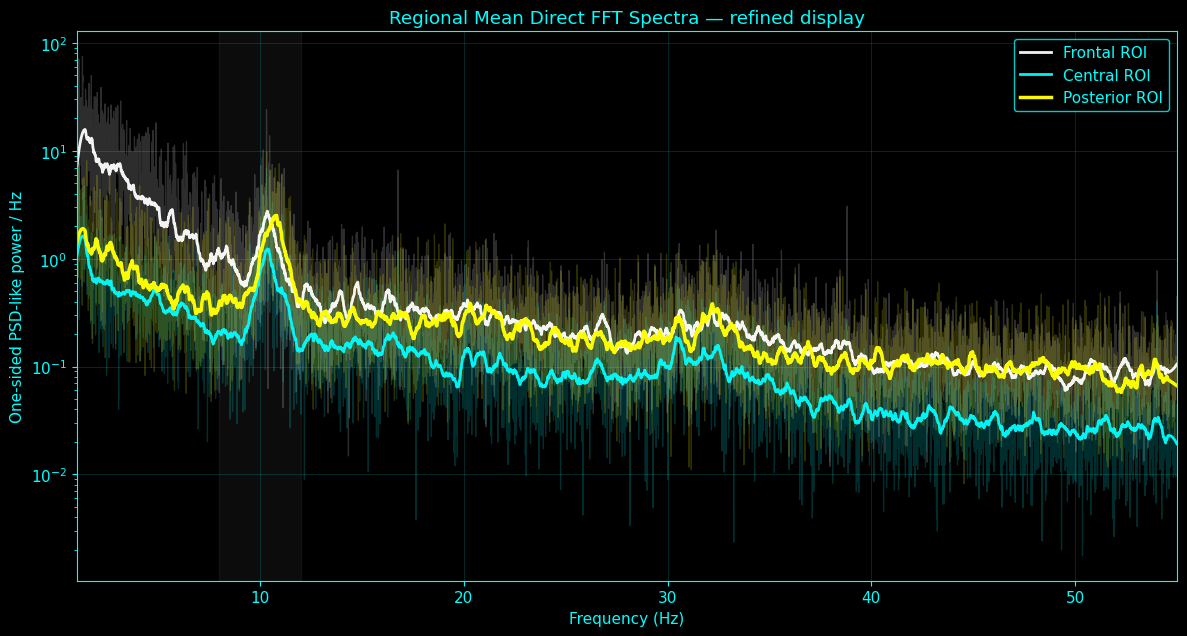

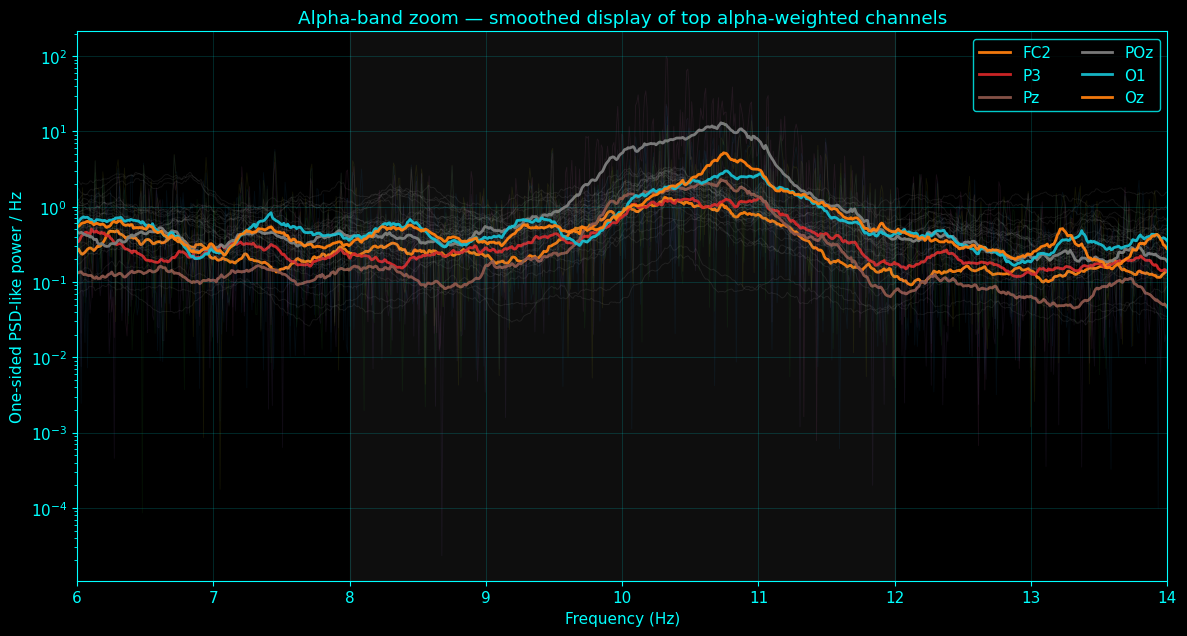

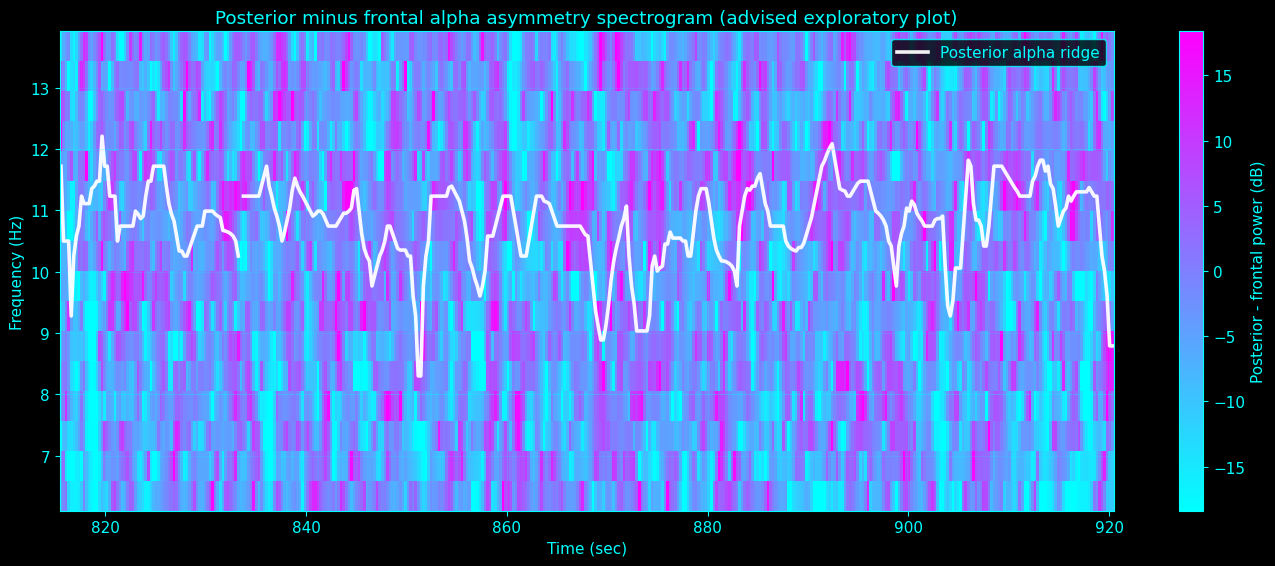

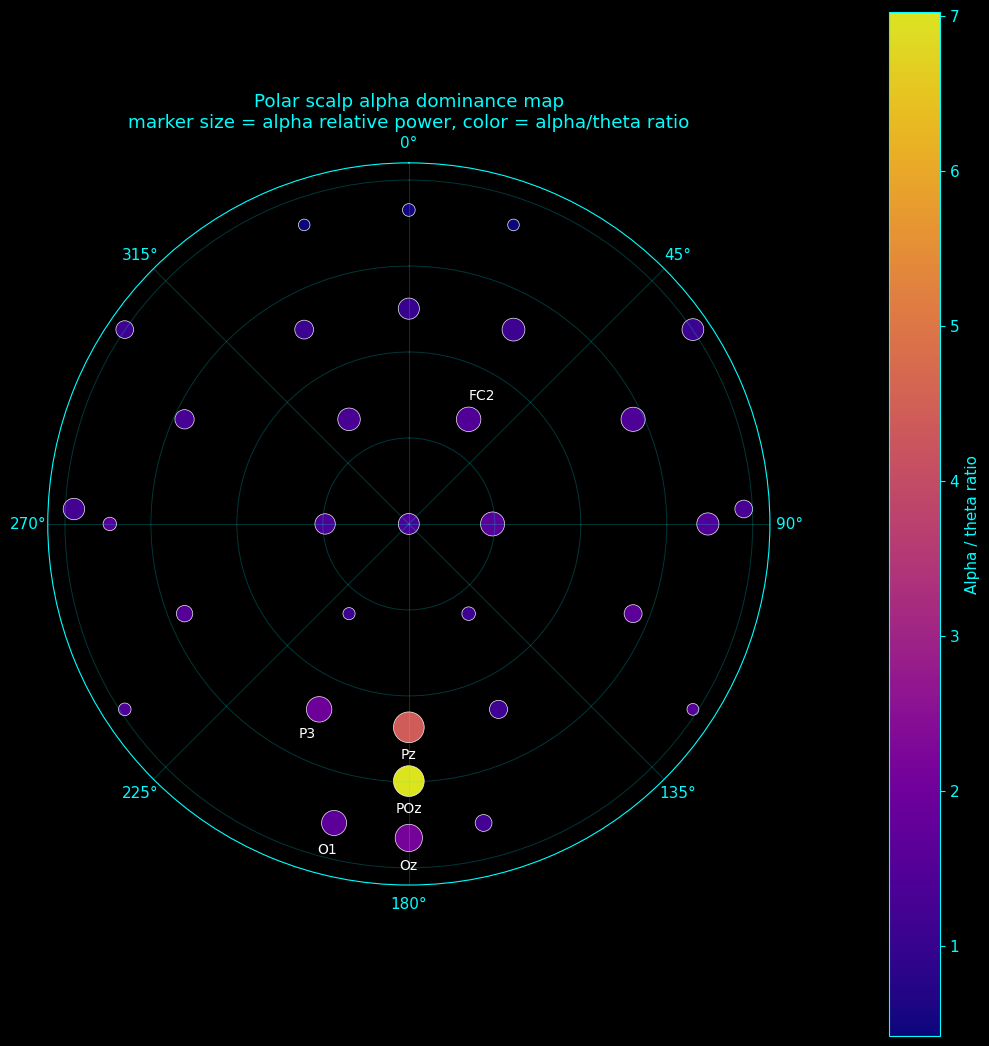

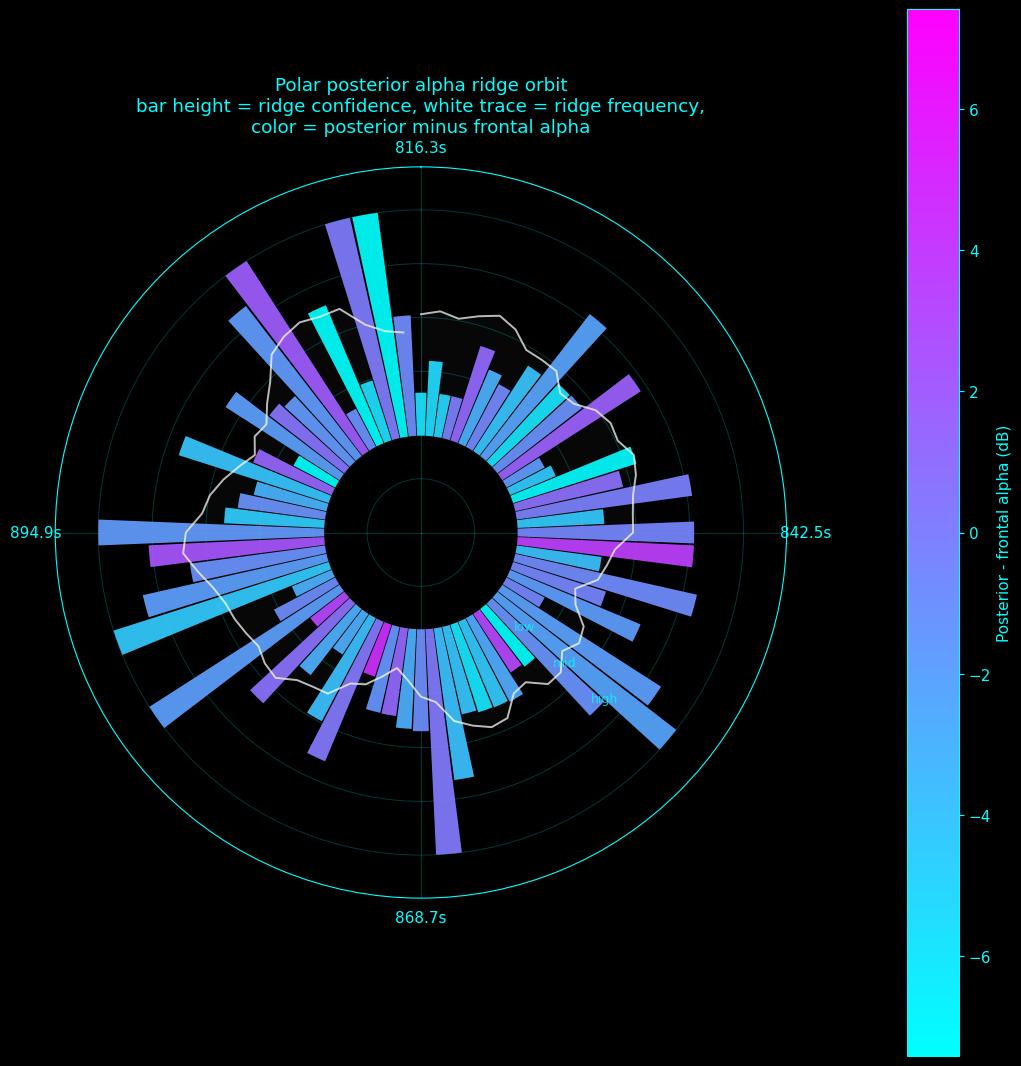


Saved refined / creative FFT plots:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/01_direct_fft_overview_refined.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/02_roi_direct_fft_spectra_refined.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/03_alpha_zoom_top_channels_refined.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/04_alpha_asymmetry_spectrogram.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/05_polar_scalp_alpha_dominance.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_fft_periodogram/plots_refined_creative/06_polar_posterior_alpha_ridge_orbit.png


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to your reference script
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_fft_periodogram")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Frequency-domain controls
fmin, fmax = 1.0, 60.0
alpha_search_band = (7.0, 13.0)
aperiodic_fit_range = (2.0, 40.0)
exclude_slope_bands = [(7.0, 14.0), (48.0, 52.0), (58.0, 62.0)]

# Exploratory controls
apply_common_average_reference = False
demean_before_fft = True
apply_hann_taper = True
annotate_top_n_alpha = 6

eps = 1e-12
ACCENT = "cyan"
BG = "black"

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 12.0),
    "beta":  (13.0, 30.0),
    "low_gamma": (30.0, 45.0),
}

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def integrate_band(freqs, spectrum_1d, band):
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(spectrum_1d[mask], freqs[mask]))

def total_power(freqs, spectrum_1d, lo=1.0, hi=60.0):
    mask = (freqs >= lo) & (freqs <= hi)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(spectrum_1d[mask], freqs[mask]))

def spectral_entropy(freqs, spectrum_1d, lo=1.0, hi=60.0):
    mask = (freqs >= lo) & (freqs <= hi)
    p = np.asarray(spectrum_1d[mask], dtype=float)
    p = np.maximum(p, 0.0)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    p = p / s
    h = -np.sum(p * np.log(p + eps))
    hmax = np.log(len(p) + eps)
    return float(h / (hmax + eps))

def spectral_edge_frequency(freqs, spectrum_1d, edge=0.95, lo=1.0, hi=60.0):
    mask = (freqs >= lo) & (freqs <= hi)
    f = freqs[mask]
    p = spectrum_1d[mask]
    if len(f) < 2:
        return np.nan
    c = np.cumsum(p)
    if c[-1] <= 0:
        return np.nan
    c = c / c[-1]
    idx = np.searchsorted(c, edge)
    idx = min(idx, len(f) - 1)
    return float(f[idx])

def smooth_1d(x, win=5):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def peak_frequency(freqs, spectrum_1d, band=(8.0, 12.0), smooth_win=5):
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)
    if np.sum(mask) < 3:
        return np.nan, np.nan

    f = freqs[mask]
    p = smooth_1d(spectrum_1d[mask], win=smooth_win)
    idx = int(np.argmax(p))
    return float(f[idx]), float(p[idx])

def estimate_aperiodic_slope(freqs, spectrum_1d, fit_range=(2.0, 40.0), exclude_bands=None):
    lo, hi = fit_range
    mask = (freqs >= lo) & (freqs <= hi) & np.isfinite(spectrum_1d) & (spectrum_1d > 0)

    if exclude_bands is not None:
        for blo, bhi in exclude_bands:
            mask &= ~((freqs >= blo) & (freqs <= bhi))

    if np.sum(mask) < 6:
        return np.nan, np.nan, np.nan

    x = np.log10(freqs[mask])
    y = np.log10(spectrum_1d[mask] + eps)

    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return float(slope), float(intercept), float(r2)

def compute_direct_fft_periodogram(x, fs, demean=True, hann_taper=True):
    """
    Exploratory one-sided tapered periodogram.

    Why this version:
    - Uses rFFT, so only non-negative frequencies.
    - Optional demeaning to suppress DC leakage.
    - Optional Hann taper to reduce spectral leakage.
    - Scales to one-sided PSD-like units (power / Hz).
    - Higher frequency resolution than Welch, but higher variance too.
      Treat this as a fine-structure cross-check, not a scoring pipeline.
    """
    x = np.asarray(x, dtype=float)
    n = x.shape[0]

    if demean:
        x = x - np.mean(x, axis=0, keepdims=True)

    if hann_taper:
        window = np.hanning(n)[:, None]
    else:
        window = np.ones((n, 1), dtype=float)

    xw = x * window

    fft_vals = np.fft.rfft(xw, axis=0)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)

    # Periodogram scaling
    win_power = np.sum(window[:, 0] ** 2)
    psd = (np.abs(fft_vals) ** 2) / (fs * win_power)

    # One-sided correction except DC and Nyquist
    if n % 2 == 0:
        if psd.shape[0] > 2:
            psd[1:-1, :] *= 2.0
    else:
        if psd.shape[0] > 1:
            psd[1:, :] *= 2.0

    return freqs, psd

def compute_channel_summary(freqs, spectrum_matrix, channel_names, bands_dict):
    rows = []
    for ch_i, ch_name in enumerate(channel_names):
        spec_1d = spectrum_matrix[:, ch_i]
        p_total = total_power(freqs, spec_1d, lo=fmin, hi=fmax)

        alpha_peak_hz, alpha_peak_power = peak_frequency(freqs, spec_1d, band=alpha_search_band)
        slope, intercept, slope_r2 = estimate_aperiodic_slope(
            freqs,
            spec_1d,
            fit_range=aperiodic_fit_range,
            exclude_bands=exclude_slope_bands,
        )

        row = {
            "channel": ch_name,
            "total_power_1_60Hz": p_total,
            "spectral_entropy_1_60Hz": spectral_entropy(freqs, spec_1d, lo=fmin, hi=fmax),
            "spectral_edge_95Hz": spectral_edge_frequency(freqs, spec_1d, edge=0.95, lo=fmin, hi=fmax),
            "median_frequency_Hz": spectral_edge_frequency(freqs, spec_1d, edge=0.50, lo=fmin, hi=fmax),
            "alpha_peak_frequency_Hz": alpha_peak_hz,
            "alpha_peak_power": alpha_peak_power,
            "aperiodic_slope_loglog_2_40Hz": slope,
            "aperiodic_intercept_loglog_2_40Hz": intercept,
            "aperiodic_fit_r2": slope_r2,
        }

        for band_name, band_range in bands_dict.items():
            bp = integrate_band(freqs, spec_1d, band_range)
            row[f"{band_name}_power"] = bp
            row[f"{band_name}_relative_power"] = bp / (p_total + eps)

        row["alpha_theta_ratio"] = row["alpha_power"] / (row["theta_power"] + eps)
        row["alpha_beta_ratio"] = row["alpha_power"] / (row["beta_power"] + eps)

        rows.append(row)

    summary_df = pd.DataFrame(rows)

    numeric_cols = [c for c in summary_df.columns if c != "channel"]
    for col in numeric_cols:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

    return summary_df

def roi_average_spectrum(freqs, spectrum_matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(len(freqs), np.nan, dtype=float)
    return np.nanmean(spectrum_matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

n_samples, n_channels = segment.shape
time_sec = start_time + np.arange(n_samples) * dt

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# DIRECT FFT / PERIODROGRAM
# -------------------------------------------------------
freqs_full, fft_psd_full = compute_direct_fft_periodogram(
    segment,
    fs=sampling_rate,
    demean=demean_before_fft,
    hann_taper=apply_hann_taper,
)

keep = (freqs_full >= fmin) & (freqs_full <= fmax)
freqs = freqs_full[keep]
fft_psd_matrix = fft_psd_full[keep, :]

summary_df = compute_channel_summary(freqs, fft_psd_matrix, eeg_channel_names, bands)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
fft_npz_path = os.path.join(out_dir, "exploratory_direct_fft_outputs.npz")
summary_csv_path = os.path.join(out_dir, "channel_direct_fft_summary.csv")
bandpower_csv_path = os.path.join(out_dir, "channel_direct_fft_relative_bandpower.csv")
summary_txt_path = os.path.join(out_dir, "exploratory_direct_fft_notes.txt")

summary_df.to_csv(summary_csv_path, index=False)

band_cols = [f"{b}_relative_power" for b in bands.keys()] + ["alpha_theta_ratio", "alpha_beta_ratio"]
bandpower_df = summary_df[["channel"] + band_cols].copy()
bandpower_df.to_csv(bandpower_csv_path, index=False)

np.savez_compressed(
    fft_npz_path,
    freqs=freqs,
    fft_psd_matrix=fft_psd_matrix,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
)

alpha_ranked = summary_df.sort_values("alpha_relative_power", ascending=False).head(8)
posterior_channels = {"P3", "Pz", "P4", "O1", "Oz", "O2"}
posterior_alpha = alpha_ranked[alpha_ranked["channel"].isin(posterior_channels)]

with open(summary_txt_path, "w") as f:
    f.write("Exploratory direct FFT / periodogram analysis notes\n")
    f.write("===================================================\n\n")
    f.write("Intent:\n")
    f.write("This pass is a high-resolution exploratory spectral cross-check, not a publication-ready estimator,\n")
    f.write("not a benchmark, and not a scoring system.\n\n")
    f.write("Why do this if Welch already exists?\n")
    f.write("Welch is lower variance and smoother. Direct FFT periodograms are noisier but preserve sharper narrowband detail.\n")
    f.write("So this block is useful for checking whether candidate peaks, shoulders, and posterior narrowband structure are real enough\n")
    f.write("to survive with finer frequency resolution.\n\n")
    f.write("Design choices:\n")
    f.write("1. Restrict analysis to the same recording interval of interest.\n")
    f.write("2. Demean before FFT to reduce DC contamination.\n")
    f.write("3. Use a Hann taper to reduce leakage before the direct periodogram.\n")
    f.write("4. Use one-sided PSD-like scaling so band integration stays interpretable.\n")
    f.write("5. Summarize periodic structure, rough aperiodic slope, and regional contrasts without pretending this is a formal test.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Frequency range analyzed: [{fmin:.1f}, {fmax:.1f}] Hz\n")
    f.write(f"Demean before FFT: {demean_before_fft}\n")
    f.write(f"Hann taper applied: {apply_hann_taper}\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Highest alpha-relative-power channels:\n")
    for _, row in alpha_ranked.iterrows():
        f.write(
            f"  {row['channel']}: alpha_rel={row['alpha_relative_power']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz, "
            f"slope={row['aperiodic_slope_loglog_2_40Hz']:.3f}, "
            f"alpha/theta={row['alpha_theta_ratio']:.3f}\n"
        )

    f.write("\nPosterior alpha-heavy subset within top alpha channels:\n")
    if len(posterior_alpha) == 0:
        f.write("  none in top-ranked alpha channels\n")
    else:
        for _, row in posterior_alpha.iterrows():
            f.write(
                f"  {row['channel']}: alpha_rel={row['alpha_relative_power']:.4f}, "
                f"alpha_peak={row['alpha_peak_frequency_Hz']:.3f} Hz\n"
            )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) Median + IQR direct FFT spectrum across channels
median_psd = np.median(fft_psd_matrix, axis=1)
q25_psd = np.quantile(fft_psd_matrix, 0.25, axis=1)
q75_psd = np.quantile(fft_psd_matrix, 0.75, axis=1)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
style_ax(ax)

for band_name, (lo, hi) in bands.items():
    ax.axvspan(lo, hi, alpha=0.06, color="white")
    ax.text((lo + hi) / 2.0, np.max(median_psd) * 1.12, band_name, ha="center", va="bottom", fontsize=9)

ax.semilogy(freqs, median_psd, linewidth=2.1, color=ACCENT, label="Median across channels")
ax.fill_between(freqs, q25_psd, q75_psd, color=ACCENT, alpha=0.18, label="IQR across channels")
ax.set_xlim(fmin, fmax)
ax.set_title("Direct FFT Periodogram Overview of the Selected EEG Segment")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right")

plot1_path = os.path.join(plots_dir, "01_direct_fft_overview_median_iqr.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Channel-wise direct FFT spectra
n_cols = 4
n_rows = int(np.ceil(len(eeg_channel_names) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.8 * n_rows), facecolor=BG, sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

for ch_i, ch_name in enumerate(eeg_channel_names):
    ax = axes[ch_i]
    style_ax(ax)
    ax.semilogy(freqs, fft_psd_matrix[:, ch_i], color=ACCENT, linewidth=0.9, alpha=0.95)
    ax.set_title(ch_name, fontsize=10)
    ax.set_xlim(fmin, fmax)

    alpha_peak = summary_df.loc[summary_df["channel"] == ch_name, "alpha_peak_frequency_Hz"].values[0]
    if np.isfinite(alpha_peak):
        ax.axvline(alpha_peak, color="white", linestyle="--", linewidth=0.8, alpha=0.65)

for ax in axes[len(eeg_channel_names):]:
    ax.axis("off")

for i, ax in enumerate(axes):
    if i % n_cols == 0 and i < len(eeg_channel_names):
        ax.set_ylabel("PSD-like")
    if i >= (n_rows - 1) * n_cols and i < len(eeg_channel_names):
        ax.set_xlabel("Hz")

fig.suptitle("Channel-wise Direct FFT Periodograms with Alpha-Peak Markers", fontsize=14, color=ACCENT, y=0.995)
plot2_path = os.path.join(plots_dir, "02_channel_direct_fft_grid.png")
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Alpha zoom with top alpha channels highlighted
top_alpha = summary_df.sort_values("alpha_relative_power", ascending=False).head(annotate_top_n_alpha)
top_alpha_channels = list(top_alpha["channel"].values)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
style_ax(ax)

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = fft_psd_matrix[:, ch_i]
    if ch_name in top_alpha_channels:
        ax.plot(freqs, y, linewidth=1.3, alpha=0.95, label=ch_name)
    else:
        ax.plot(freqs, y, linewidth=0.6, alpha=0.14, color="white")

ax.set_xlim(6, 14)
ax.set_yscale("log")
ax.set_title("Alpha-Band Zoom: Top Alpha-Weighted Channels in the Selected Segment")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right", ncol=2)

plot3_path = os.path.join(plots_dir, "03_alpha_zoom_top_channels.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Relative bandpower heatmap from direct FFT spectra
heatmap_matrix = summary_df[[f"{b}_relative_power" for b in bands.keys()]].values

fig, ax = plt.subplots(figsize=(8.5, 10), facecolor=BG)
style_ax(ax)

im = ax.imshow(heatmap_matrix, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_title("Relative Bandpower by Channel (Direct FFT)")
ax.set_xlabel("Band")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(bands)))
ax.set_xticklabels(list(bands.keys()))
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_yticklabels(eeg_channel_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative power", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "04_direct_fft_relative_bandpower_heatmap.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) ROI spectra: frontal vs central vs posterior
frontal_spec = roi_average_spectrum(freqs, fft_psd_matrix, eeg_channel_names, roi_definitions["frontal"])
central_spec = roi_average_spectrum(freqs, fft_psd_matrix, eeg_channel_names, roi_definitions["central"])
posterior_spec = roi_average_spectrum(freqs, fft_psd_matrix, eeg_channel_names, roi_definitions["posterior"])

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
style_ax(ax)

ax.semilogy(freqs, frontal_spec, linewidth=1.7, alpha=0.90, color="white", label="Frontal ROI")
ax.semilogy(freqs, central_spec, linewidth=1.7, alpha=0.90, color=ACCENT, label="Central ROI")
ax.semilogy(freqs, posterior_spec, linewidth=2.1, alpha=0.95, color="yellow", label="Posterior ROI")
ax.set_xlim(fmin, fmax)
ax.set_title("Regional Mean Direct FFT Spectra")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right")

plot5_path = os.path.join(plots_dir, "05_roi_direct_fft_spectra.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Descriptor space: slope vs entropy colored by alpha/theta
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

scatter = ax.scatter(
    summary_df["aperiodic_slope_loglog_2_40Hz"].values,
    summary_df["spectral_entropy_1_60Hz"].values,
    c=summary_df["alpha_theta_ratio"].values,
    s=90,
    alpha=0.90,
    cmap="plasma",
)

ax.set_title("Direct FFT Descriptor Space: Aperiodic Slope vs Spectral Entropy")
ax.set_xlabel("Aperiodic slope (log-log, 2–40 Hz)")
ax.set_ylabel("Spectral entropy (1–60 Hz)")

for _, row in top_alpha.iterrows():
    ax.text(
        row["aperiodic_slope_loglog_2_40Hz"] + 0.01,
        row["spectral_entropy_1_60Hz"] + 0.002,
        row["channel"],
        fontsize=9,
        color="white",
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Alpha / theta ratio", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot6_path = os.path.join(plots_dir, "06_direct_fft_descriptor_space.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved FFT NPZ: {fft_npz_path}")
print(f"Saved channel summary CSV: {summary_csv_path}")
print(f"Saved bandpower CSV: {bandpower_csv_path}")
print(f"Saved notes TXT: {summary_txt_path}")
print(f"Saved plots to: {plots_dir}")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter

# =======================================================
# CONFIG
# =======================================================
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_fft_periodogram")
npz_path = os.path.join(out_dir, "exploratory_direct_fft_outputs.npz")
summary_csv_path = os.path.join(out_dir, "channel_direct_fft_summary.csv")

plots_dir = os.path.join(out_dir, "plots_refined_creative")
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

fmin = 1.0
fmax = 60.0
display_fmax = 55.0

alpha_band = (8.0, 12.0)
alpha_zoom = (6.0, 14.0)
posterior_roi = ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2']
frontal_roi = ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4']
central_roi = ['C3', 'Cz', 'C4']

annotate_top_n_alpha = 6
eps = 1e-12
ACCENT = "cyan"
BG = "black"

# channel order expected by saved FFT outputs
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 12.0),
    "beta": (13.0, 30.0),
    "low_gamma": (30.0, 45.0),
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 11,
})

# =======================================================
# STYLE
# =======================================================
def style_ax(ax, polar=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if polar:
        ax.grid(True, alpha=0.22, color=ACCENT, linewidth=0.7)
        ax.spines["polar"].set_color(ACCENT)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
        for spine in ax.spines.values():
            spine.set_color(ACCENT)

# =======================================================
# HELPERS
# =======================================================
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def compute_roi_signal(segment, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        raise ValueError(f"No ROI channels found: {roi_channels}")
    return np.mean(segment[:, idx], axis=1)

def smooth_display_spectrum(y, win=61, poly=2):
    y = np.asarray(y, dtype=float)
    y = np.maximum(y, eps)
    if len(y) < 7:
        return y.copy()

    win = min(win, len(y) - (1 - len(y) % 2))
    if win % 2 == 0:
        win -= 1
    win = max(win, 7)
    poly = min(poly, win - 2)

    logy = np.log10(y)
    logy_s = savgol_filter(logy, window_length=win, polyorder=poly, mode="interp")
    return 10 ** logy_s

def robust_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    finite = x[np.isfinite(x)]
    if finite.size == 0:
        return -1.0, 1.0
    return np.percentile(finite, lo), np.percentile(finite, hi)

def smooth_nanaware(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x.copy()
    valid = np.isfinite(x).astype(float)
    x_fill = np.where(np.isfinite(x), x, 0.0)
    kernel = np.ones(win, dtype=float)
    num = np.convolve(x_fill, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    y = num / np.maximum(den, eps)
    y[den < 1] = np.nan
    return y

def bin_series_for_polar(t_abs, radial_signal, color_signal, n_bins=72):
    edges = np.linspace(t_abs[0], t_abs[-1], n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    r = np.full(n_bins, np.nan)
    c = np.full(n_bins, np.nan)

    for i in range(n_bins):
        if i < n_bins - 1:
            m = (t_abs >= edges[i]) & (t_abs < edges[i + 1])
        else:
            m = (t_abs >= edges[i]) & (t_abs <= edges[i + 1])

        if np.any(m):
            r[i] = np.nanmedian(radial_signal[m])
            c[i] = np.nanmedian(color_signal[m])

    return centers, r, c

def approximate_head_polar(channel):
    """
    Approximate 10-20 scalp layout in polar coordinates.
    angle: 0 = front, clockwise
    radius: 0 center -> 1 edge
    """
    pos = {
        'Fp1': (-0.35, 1.00), 'Fpz': (0.00, 1.05), 'Fp2': (0.35, 1.00),
        'F7': (-0.95, 0.65), 'F3': (-0.35, 0.65), 'Fz': (0.00, 0.72), 'F4': (0.35, 0.65), 'F8': (0.95, 0.65),
        'FC5': (-0.75, 0.35), 'FC1': (-0.20, 0.35), 'FC2': (0.20, 0.35), 'FC6': (0.75, 0.35),
        'M1': (-1.12, 0.05), 'T7': (-1.00, 0.00), 'C3': (-0.28, 0.00), 'Cz': (0.00, 0.00), 'C4': (0.28, 0.00), 'T8': (1.00, 0.00), 'M2': (1.12, 0.05),
        'CP5': (-0.75, -0.30), 'CP1': (-0.20, -0.30), 'CP2': (0.20, -0.30), 'CP6': (0.75, -0.30),
        'P7': (-0.95, -0.62), 'P3': (-0.30, -0.62), 'Pz': (0.00, -0.68), 'P4': (0.30, -0.62), 'P8': (0.95, -0.62),
        'POz': (0.00, -0.86), 'O1': (-0.25, -1.00), 'Oz': (0.00, -1.05), 'O2': (0.25, -1.00)
    }
    x, y = pos[channel]
    theta = np.arctan2(x, y)  # 0 at front
    if theta < 0:
        theta += 2 * np.pi
    r = np.sqrt(x**2 + y**2) / 1.15
    return theta, r

# =======================================================
# LOAD FROM FILE PATHS
# =======================================================
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"Missing FFT NPZ: {npz_path}")
if not os.path.exists(summary_csv_path):
    raise FileNotFoundError(f"Missing summary CSV: {summary_csv_path}")

npz = np.load(npz_path, allow_pickle=True)
freqs = npz["freqs"].astype(float)
fft_psd_matrix = npz["fft_psd_matrix"].astype(float)
channel_names_from_npz = [str(x) for x in npz["channel_names"]]

summary_df = pd.read_csv(summary_csv_path)

# raw EEG for dynamic extensions
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))
segment = eeg_data[start_index:end_index, :].astype(float)

print(f"Loaded direct FFT outputs from: {npz_path}")
print(f"Loaded summary CSV from: {summary_csv_path}")
print(f"Loaded EEG segment from: {eeg_path}")
print(f"Segment shape: {segment.shape}")

# =======================================================
# BASIC DERIVED OBJECTS
# =======================================================
display_mask = (freqs >= fmin) & (freqs <= display_fmax)
f_disp = freqs[display_mask]
psd_disp = fft_psd_matrix[display_mask, :]

alpha_ranked = summary_df.sort_values("alpha_relative_power", ascending=False).reset_index(drop=True)
top_alpha = alpha_ranked.head(annotate_top_n_alpha)
top_alpha_channels = list(top_alpha["channel"].values)

# smoothed display spectra only
smoothed_disp = np.zeros_like(psd_disp)
for ch_i in range(psd_disp.shape[1]):
    smoothed_disp[:, ch_i] = smooth_display_spectrum(psd_disp[:, ch_i], win=81, poly=2)

# ROI mean spectra
def roi_average_spectrum(roi_channels):
    idx = [channel_names_from_npz.index(ch) for ch in roi_channels if ch in channel_names_from_npz]
    return np.nanmean(psd_disp[:, idx], axis=1)

frontal_spec = roi_average_spectrum(frontal_roi)
central_spec = roi_average_spectrum(central_roi)
posterior_spec = roi_average_spectrum(posterior_roi)

frontal_spec_s = smooth_display_spectrum(frontal_spec, win=91, poly=2)
central_spec_s = smooth_display_spectrum(central_spec, win=91, poly=2)
posterior_spec_s = smooth_display_spectrum(posterior_spec, win=91, poly=2)

# =======================================================
# DYNAMIC POSTERIOR / FRONTAL SPECTROGRAMS
# =======================================================
posterior_signal = compute_roi_signal(segment, eeg_channel_names, posterior_roi)
frontal_signal = compute_roi_signal(segment, eeg_channel_names, frontal_roi)

spec_nperseg = 2048
spec_noverlap = 1792

f_spec, t_spec, sxx_post = signal.spectrogram(
    posterior_signal,
    fs=sampling_rate,
    window="hann",
    nperseg=spec_nperseg,
    noverlap=spec_noverlap,
    detrend="constant",
    scaling="density",
    mode="psd",
)

_, _, sxx_fr = signal.spectrogram(
    frontal_signal,
    fs=sampling_rate,
    window="hann",
    nperseg=spec_nperseg,
    noverlap=spec_noverlap,
    detrend="constant",
    scaling="density",
    mode="psd",
)

t_abs = start_time + t_spec

keep_tf = (f_spec >= 6.0) & (f_spec <= 14.0)
f_alpha = f_spec[keep_tf]
post_db = 10.0 * np.log10(sxx_post[keep_tf, :] + eps)
fr_db = 10.0 * np.log10(sxx_fr[keep_tf, :] + eps)

# advised plot: posterior minus frontal alpha asymmetry spectrogram
asym_db = post_db - fr_db

# ridge from posterior alpha map
ridge_mask = (f_alpha >= 8.0) & (f_alpha <= 12.5)
f_ridge = f_alpha[ridge_mask]
post_alpha_zoom = post_db[ridge_mask, :]

ridge_raw = f_ridge[np.argmax(post_alpha_zoom, axis=0)]
ridge_prom = np.max(post_alpha_zoom, axis=0) - np.median(post_alpha_zoom, axis=0)
ridge_valid = ridge_prom >= np.quantile(ridge_prom, 0.35)

ridge_track = ridge_raw.astype(float).copy()
ridge_track[~ridge_valid] = np.nan
ridge_track = smooth_nanaware(ridge_track, win=7)

alpha_asym_t = np.nanmean(asym_db[(f_alpha >= 8.0) & (f_alpha <= 12.0), :], axis=0)

# =======================================================
# POLAR DATA
# =======================================================
n_bins = 72
polar_t, polar_ridge, polar_asym = bin_series_for_polar(t_abs, ridge_track, alpha_asym_t, n_bins=n_bins)

theta = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
bar_width = 2 * np.pi / n_bins * 0.92

ridge_lo, ridge_hi = np.nanpercentile(polar_ridge[np.isfinite(polar_ridge)], [5, 95])
ridge_norm = np.clip((polar_ridge - ridge_lo) / (ridge_hi - ridge_lo + eps), 0, 1)

asym_lo, asym_hi = np.nanpercentile(polar_asym[np.isfinite(polar_asym)], [5, 95])
polar_asym_clip = np.clip(polar_asym, asym_lo, asym_hi)

# =======================================================
# PLOT 1 — REFINED DIRECT FFT OVERVIEW
# =======================================================
median_psd = np.median(psd_disp, axis=1)
q25_psd = np.quantile(psd_disp, 0.25, axis=1)
q75_psd = np.quantile(psd_disp, 0.75, axis=1)
median_psd_s = smooth_display_spectrum(median_psd, win=91, poly=2)

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
style_ax(ax)

for band_name, (lo, hi) in bands.items():
    if hi <= display_fmax:
        ax.axvspan(lo, hi, alpha=0.05, color="white")
        ax.text((lo + hi) / 2.0, np.max(median_psd_s) * 1.22, band_name, ha="center", va="bottom", fontsize=10)

ax.semilogy(f_disp, median_psd, linewidth=1.0, color=ACCENT, alpha=0.28)
ax.semilogy(f_disp, median_psd_s, linewidth=2.8, color=ACCENT, label="Median across channels (smoothed display)")
ax.fill_between(f_disp, q25_psd, q75_psd, color=ACCENT, alpha=0.14, label="IQR across channels")
ax.axvspan(55, 60, color="red", alpha=0.05)
ax.text(55.4, np.max(median_psd_s) * 0.55, "edge / line-noise zone", color="white", fontsize=9, rotation=90, alpha=0.75)

ax.set_xlim(fmin, display_fmax)
ax.set_title("Direct FFT Periodogram Overview — refined display")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right")

plot1_path = os.path.join(plots_dir, "01_direct_fft_overview_refined.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# =======================================================
# PLOT 2 — REFINED ROI DIRECT FFT SPECTRA
# =======================================================
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
style_ax(ax)

ax.semilogy(f_disp, frontal_spec, color="white", linewidth=0.9, alpha=0.18)
ax.semilogy(f_disp, central_spec, color=ACCENT, linewidth=0.9, alpha=0.18)
ax.semilogy(f_disp, posterior_spec, color="yellow", linewidth=0.9, alpha=0.18)

ax.semilogy(f_disp, frontal_spec_s, color="white", linewidth=2.0, alpha=0.95, label="Frontal ROI")
ax.semilogy(f_disp, central_spec_s, color=ACCENT, linewidth=2.0, alpha=0.95, label="Central ROI")
ax.semilogy(f_disp, posterior_spec_s, color="yellow", linewidth=2.5, alpha=0.98, label="Posterior ROI")

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.axvspan(55, 60, color="red", alpha=0.04)

ax.set_xlim(fmin, display_fmax)
ax.set_title("Regional Mean Direct FFT Spectra — refined display")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right")

plot2_path = os.path.join(plots_dir, "02_roi_direct_fft_spectra_refined.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# =======================================================
# PLOT 3 — REFINED ALPHA ZOOM TOP CHANNELS
# =======================================================
fig, ax = plt.subplots(figsize=(12, 6.5), facecolor=BG)
style_ax(ax)

zoom_mask = (f_disp >= alpha_zoom[0]) & (f_disp <= alpha_zoom[1])
fz = f_disp[zoom_mask]

for ch_name in eeg_channel_names:
    ch_i = channel_names_from_npz.index(ch_name)
    y = psd_disp[:, ch_i][zoom_mask]
    ys = smoothed_disp[:, ch_i][zoom_mask]

    if ch_name in top_alpha_channels:
        ax.plot(fz, y, linewidth=0.6, alpha=0.10)
        ax.plot(fz, ys, linewidth=2.0, alpha=0.95, label=ch_name)
    else:
        ax.plot(fz, ys, linewidth=0.7, alpha=0.08, color="white")

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.06)
ax.set_yscale("log")
ax.set_xlim(alpha_zoom)
ax.set_title("Alpha-band zoom — smoothed display of top alpha-weighted channels")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("One-sided PSD-like power / Hz")
ax.legend(loc="upper right", ncol=2)

plot3_path = os.path.join(plots_dir, "03_alpha_zoom_top_channels_refined.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# =======================================================
# PLOT 4 — ADVISED POSTERIOR-VS-FRONTAL ALPHA ASYMMETRY SPECTROGRAM
# =======================================================
fig, ax = plt.subplots(figsize=(14, 5.8), facecolor=BG)
style_ax(ax)

vmin, vmax = robust_limits(asym_db, lo=3, hi=97)
vabs = max(abs(vmin), abs(vmax))

mesh = ax.pcolormesh(
    t_abs,
    f_alpha,
    asym_db,
    shading="auto",
    cmap="cool",
    vmin=-vabs,
    vmax=vabs
)

ax.plot(t_abs, ridge_track, color="white", linewidth=2.6, alpha=0.95, label="Posterior alpha ridge")
ax.axhline(8.0, color=ACCENT, linestyle="--", linewidth=0.8, alpha=0.28)
ax.axhline(12.0, color=ACCENT, linestyle="--", linewidth=0.8, alpha=0.28)
ax.set_title("Posterior minus frontal alpha asymmetry spectrogram (advised exploratory plot)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.legend(loc="upper right")

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("Posterior - frontal power (dB)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "04_alpha_asymmetry_spectrogram.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# =======================================================
# PLOT 5 — POLAR SCALP ALPHA DOMINANCE MAP
# =======================================================
fig = plt.figure(figsize=(10.6, 10.6), facecolor=BG)
ax = fig.add_subplot(111, projection="polar")
style_ax(ax, polar=True)

alpha_rel = summary_df.set_index("channel")["alpha_relative_power"].reindex(eeg_channel_names).values
alpha_theta = summary_df.set_index("channel")["alpha_theta_ratio"].reindex(eeg_channel_names).values

a_lo, a_hi = np.nanpercentile(alpha_rel[np.isfinite(alpha_rel)], [5, 95])
size_norm = np.clip((alpha_rel - a_lo) / (a_hi - a_lo + eps), 0, 1)

c_lo, c_hi = np.nanpercentile(alpha_theta[np.isfinite(alpha_theta)], [5, 95])
color_norm = plt.Normalize(vmin=c_lo, vmax=c_hi)

thetas = []
rs = []
sizes = []
colors = []

for ch in eeg_channel_names:
    th, rr = approximate_head_polar(ch)
    thetas.append(th)
    rs.append(rr)
    val = summary_df.loc[summary_df["channel"] == ch, "alpha_relative_power"].values[0]
    rat = summary_df.loc[summary_df["channel"] == ch, "alpha_theta_ratio"].values[0]
    sizes.append(70 + 420 * np.clip((val - a_lo) / (a_hi - a_lo + eps), 0, 1))
    colors.append(rat)

sc = ax.scatter(
    thetas,
    rs,
    s=sizes,
    c=colors,
    cmap="plasma",
    alpha=0.92,
    edgecolors="white",
    linewidths=0.5
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rmax(1.05)
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([])

for ch, th, rr in zip(eeg_channel_names, thetas, rs):
    if ch in top_alpha_channels:
        ax.text(th, rr + 0.08, ch, color="white", fontsize=10, ha="center", va="center")

ax.set_title(
    "Polar scalp alpha dominance map\n"
    "marker size = alpha relative power, color = alpha/theta ratio"
)

cbar = plt.colorbar(sc, ax=ax, pad=0.12)
cbar.set_label("Alpha / theta ratio", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "05_polar_scalp_alpha_dominance.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# =======================================================
# PLOT 6 — POLAR POSTERIOR ALPHA RIDGE ORBIT (CORRECTED)
# bar height = ridge confidence / prominence
# white orbit = normalized ridge frequency
# color = posterior minus frontal alpha
# =======================================================

# Bin posterior alpha ridge frequency, ridge confidence, and alpha asymmetry
_, polar_ridge_freq, polar_asym = bin_series_for_polar(
    t_abs, ridge_track, alpha_asym_t, n_bins=n_bins
)
_, polar_ridge_conf, _ = bin_series_for_polar(
    t_abs, ridge_prom, alpha_asym_t, n_bins=n_bins
)

# Robust normalization for ridge confidence/prominence
conf_valid = np.isfinite(polar_ridge_conf)
if np.sum(conf_valid) < 3:
    conf_lo = np.nanmin(polar_ridge_conf) if np.any(conf_valid) else 0.0
    conf_hi = np.nanmax(polar_ridge_conf) if np.any(conf_valid) else 1.0
else:
    conf_lo, conf_hi = np.nanpercentile(polar_ridge_conf[conf_valid], [10, 90])

conf_span = max(conf_hi - conf_lo, eps)
conf_norm = np.clip((polar_ridge_conf - conf_lo) / conf_span, 0, 1)

# Robust normalization for ridge frequency (used only for the white orbit trace)
freq_valid = np.isfinite(polar_ridge_freq)
if np.sum(freq_valid) < 3:
    freq_lo = np.nanmin(polar_ridge_freq) if np.any(freq_valid) else 8.0
    freq_hi = np.nanmax(polar_ridge_freq) if np.any(freq_valid) else 12.0
else:
    freq_lo, freq_hi = np.nanpercentile(polar_ridge_freq[freq_valid], [5, 95])

freq_span = max(freq_hi - freq_lo, eps)
freq_norm = np.clip((polar_ridge_freq - freq_lo) / freq_span, 0, 1)

# Robust clipping for asymmetry color
asym_valid = np.isfinite(polar_asym)
if np.sum(asym_valid) < 3:
    asym_lo = np.nanmin(polar_asym) if np.any(asym_valid) else -1.0
    asym_hi = np.nanmax(polar_asym) if np.any(asym_valid) else 1.0
else:
    asym_lo, asym_hi = np.nanpercentile(polar_asym[asym_valid], [5, 95])

asym_abs = max(abs(asym_lo), abs(asym_hi), eps)
polar_asym_clip = np.clip(polar_asym, -asym_abs, asym_abs)

# Geometry
theta = np.linspace(0, 2 * np.pi, n_bins, endpoint=False)
bar_width = 2 * np.pi / n_bins * 0.92

# Bars: confidence/prominence as radius
ridge_base = 0.18
ridge_height = 0.08 + 0.34 * conf_norm

# White orbit trace: frequency as radius
orbit_radius = 0.22 + 0.26 * freq_norm
orbit_radius = smooth_nanaware(orbit_radius, win=5)

# Colors
norm = plt.Normalize(vmin=-asym_abs, vmax=asym_abs)
bar_colors = plt.cm.cool(norm(polar_asym_clip))

fig = plt.figure(figsize=(10.8, 10.8), facecolor=BG)
ax = fig.add_subplot(111, projection="polar")
style_ax(ax, polar=True)

# Bars = ridge confidence/prominence
ax.bar(
    theta,
    ridge_height,
    width=bar_width,
    bottom=ridge_base,
    color=bar_colors,
    edgecolor="none",
    alpha=0.92,
    zorder=2
)

# White orbit = ridge frequency
ax.plot(
    theta,
    orbit_radius,
    color="white",
    linewidth=1.4,
    alpha=0.72,
    zorder=3
)

# Optional faint fill for visual cohesion
ax.fill_between(
    theta,
    ridge_base,
    orbit_radius,
    color="white",
    alpha=0.03,
    zorder=1
)

# Polar formatting
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

max_height = np.nanmax(ridge_height) if np.any(np.isfinite(ridge_height)) else 0.42
ax.set_ylim(0, ridge_base + max_height + 0.08)

quarter_angles = [0, np.pi / 2, np.pi, 3 * np.pi / 2]
quarter_idx = [0, n_bins // 4, n_bins // 2, 3 * n_bins // 4]
quarter_labels = [f"{polar_t[i]:.1f}s" for i in quarter_idx]
ax.set_xticks(quarter_angles)
ax.set_xticklabels(quarter_labels)
ax.set_yticklabels([])

# Small radial guide labels
for rr, lab in zip(
    [ridge_base + 0.08, ridge_base + 0.18, ridge_base + 0.28],
    ["low", "mid", "high"]
):
    ax.text(
        np.deg2rad(132),
        rr,
        lab,
        color=ACCENT,
        fontsize=9,
        alpha=0.75,
        ha="center",
        va="center"
    )

ax.set_title(
    "Polar posterior alpha ridge orbit\n"
    "bar height = ridge confidence, white trace = ridge frequency,\n"
    "color = posterior minus frontal alpha"
)

cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="cool"), ax=ax, pad=0.12)
cbar.set_label("Posterior - frontal alpha (dB)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot6_path = os.path.join(plots_dir, "06_polar_posterior_alpha_ridge_orbit.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print("\nSaved refined / creative FFT plots:")
print(plot1_path)
print(plot2_path)
print(plot3_path)
print(plot4_path)
print(plot5_path)
print(plot6_path)

# Lomb-Scargle periodogram

Loaded EEG data shape: (4227788, 32)
Segment shape: (106944, 32)
Comparison shape: (106944, 32)
Comparison sampling rate: 1000.0 Hz
Comparison downsample factor: 1


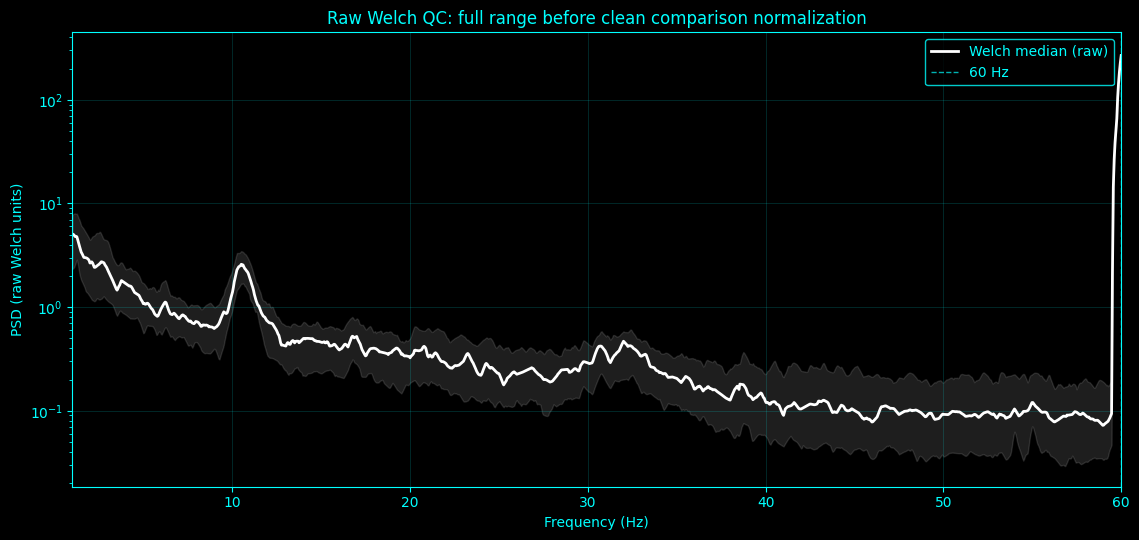

/tmp/ipykernel_7934/761847151.py:616: RuntimeWarning: All-NaN slice encountered
  median_lomb = np.nanmedian(clean_lomb, axis=1)
/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/tmp/ipykernel_7934/761847151.py:620: RuntimeWarning: All-NaN slice encountered
  median_welch = np.nanmedian(clean_welch, axis=1)


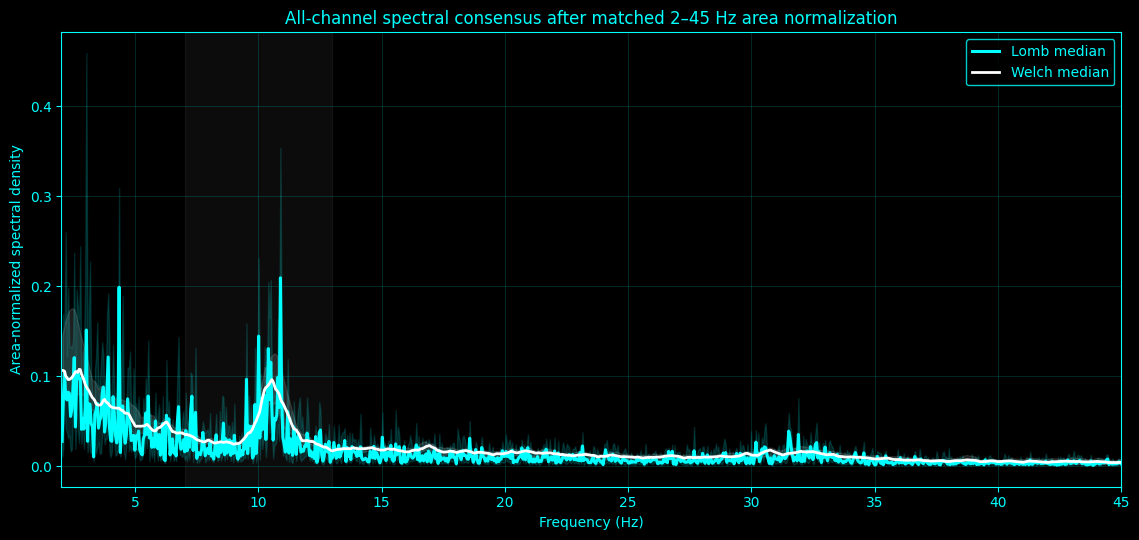

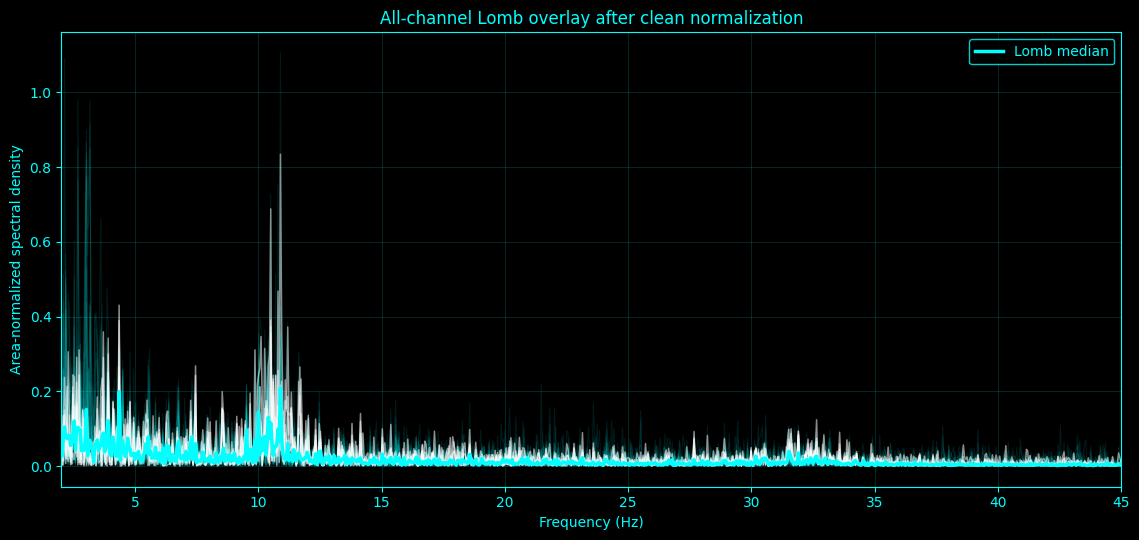

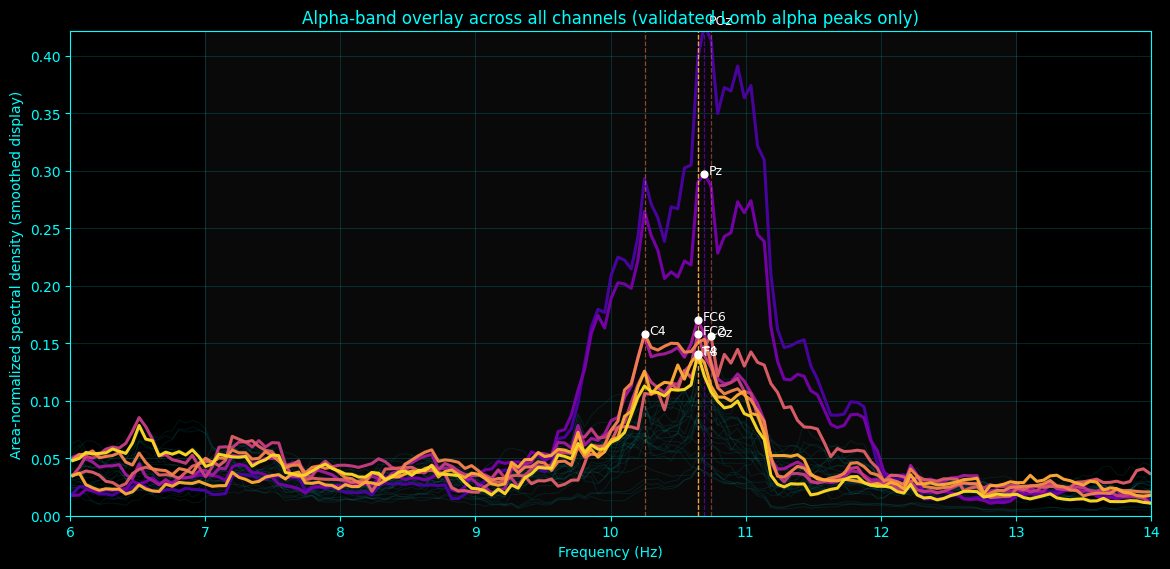

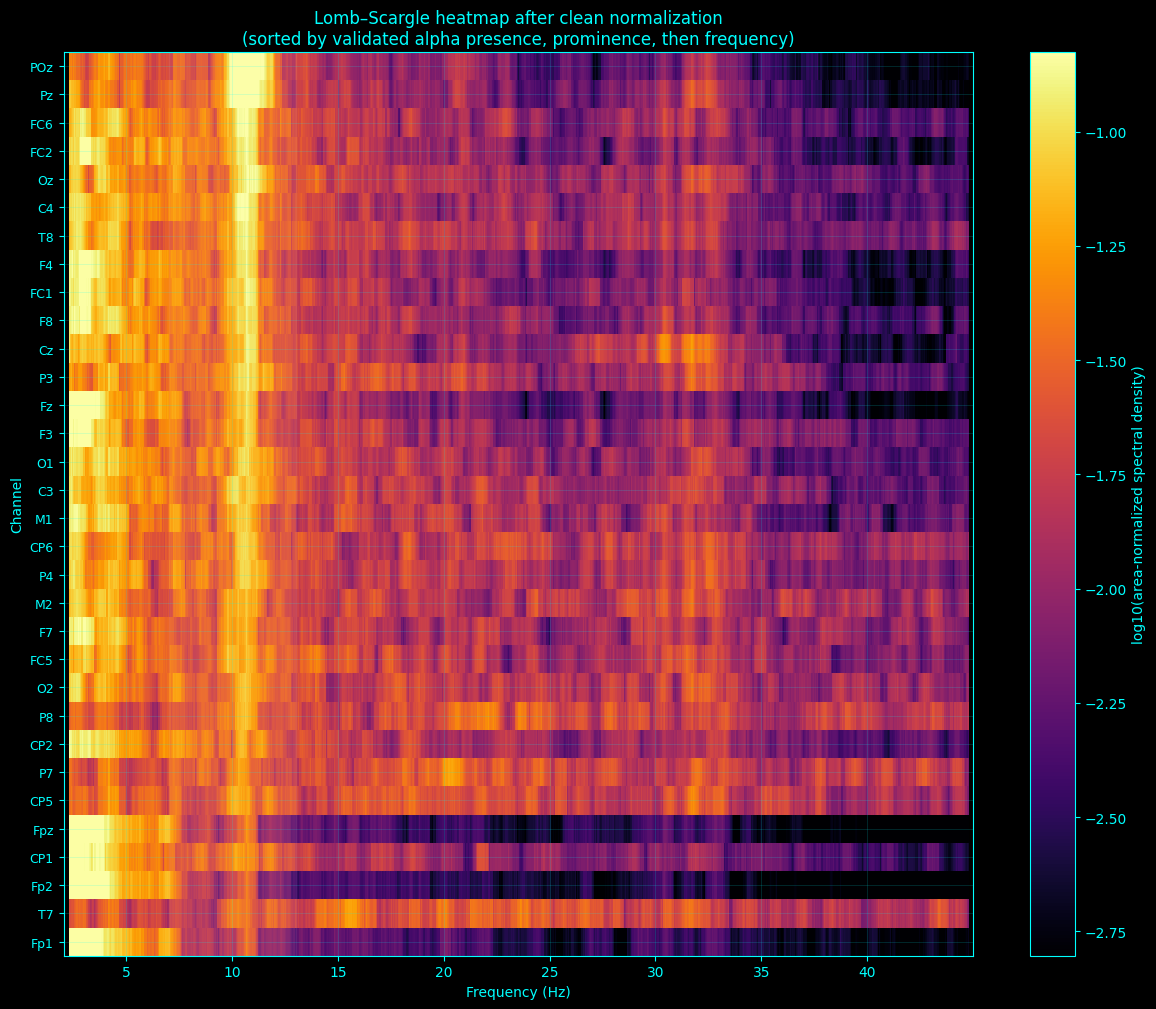

/tmp/ipykernel_7934/761847151.py:333: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(roi, axis=1)
/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


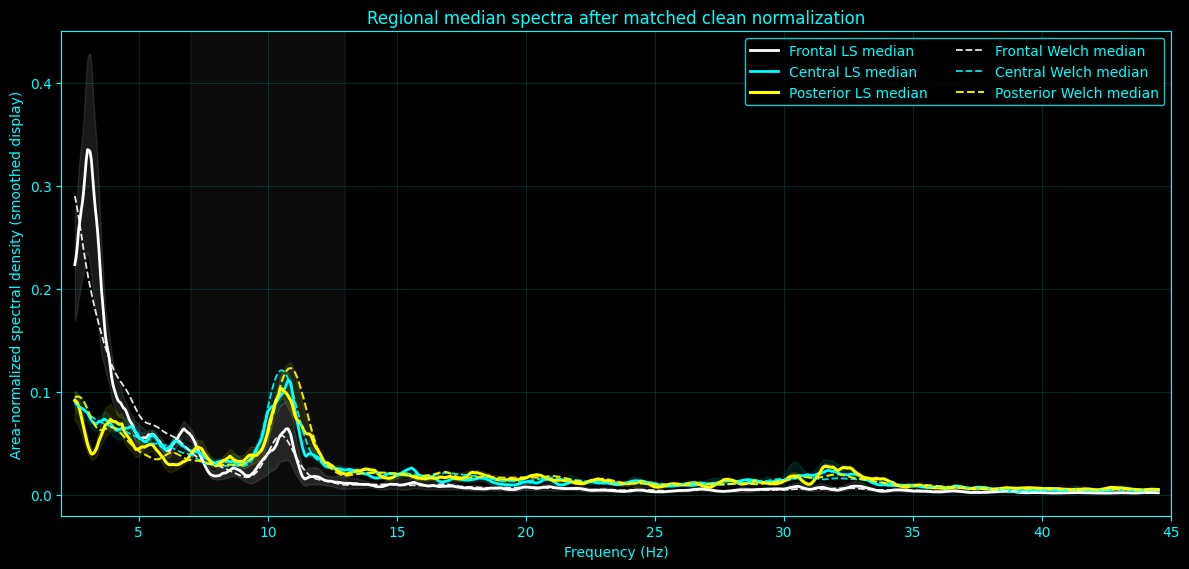

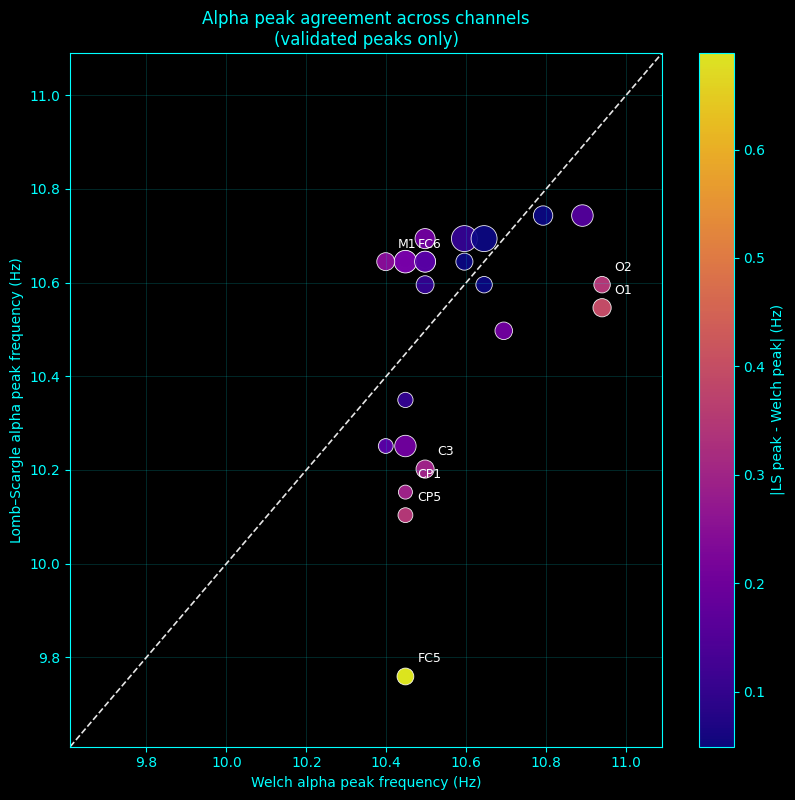

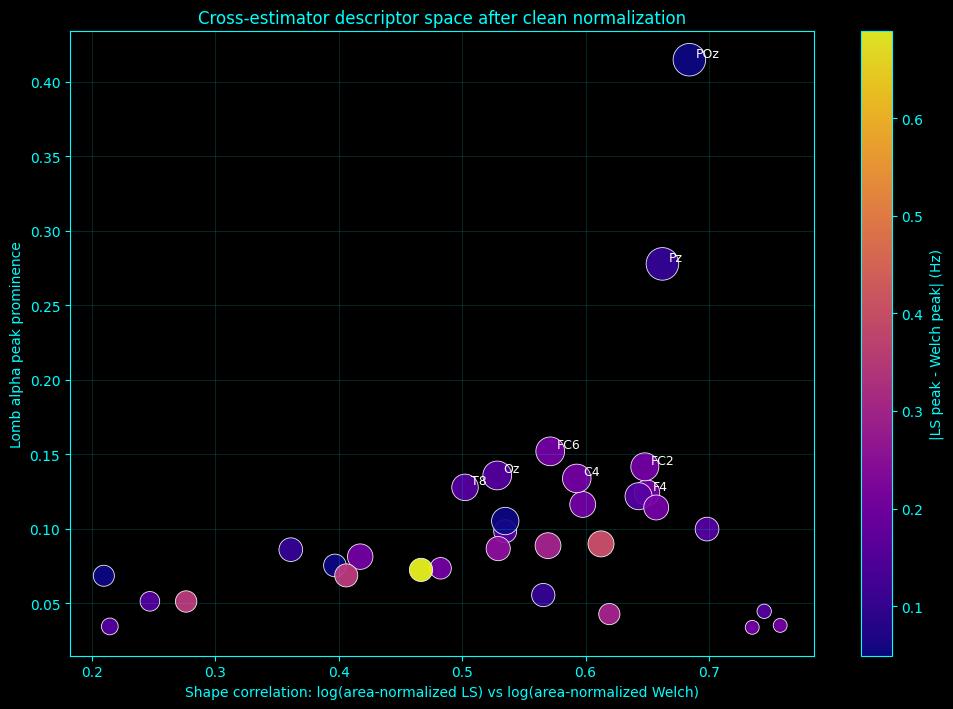

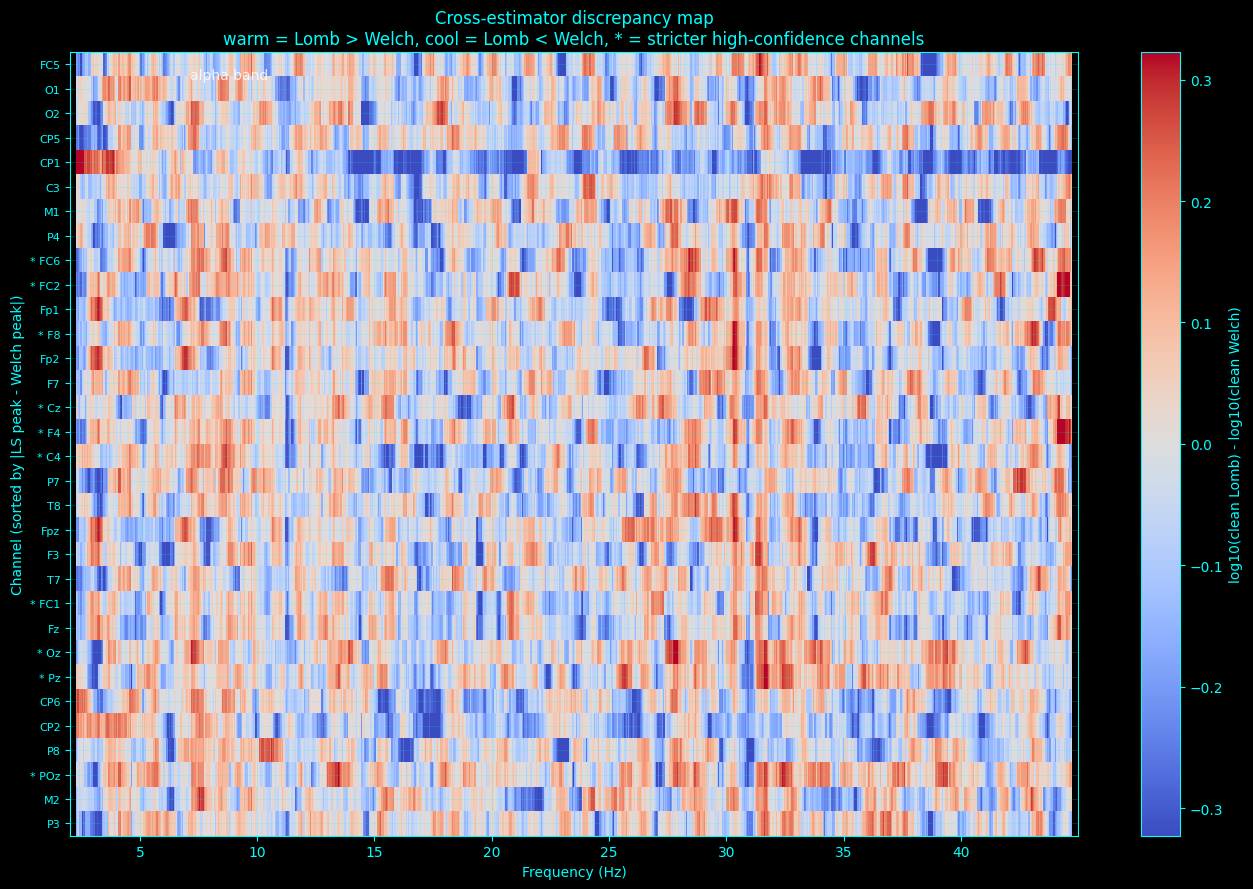

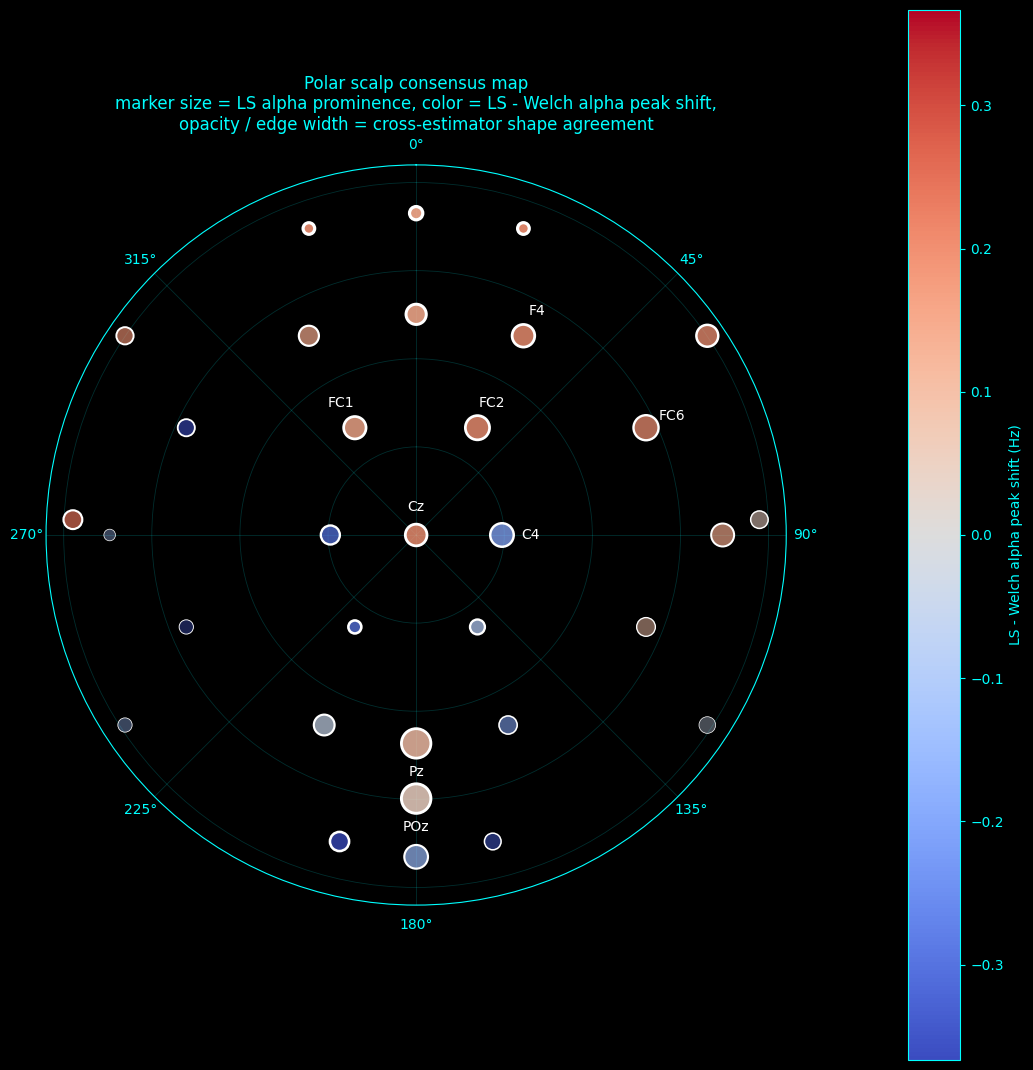

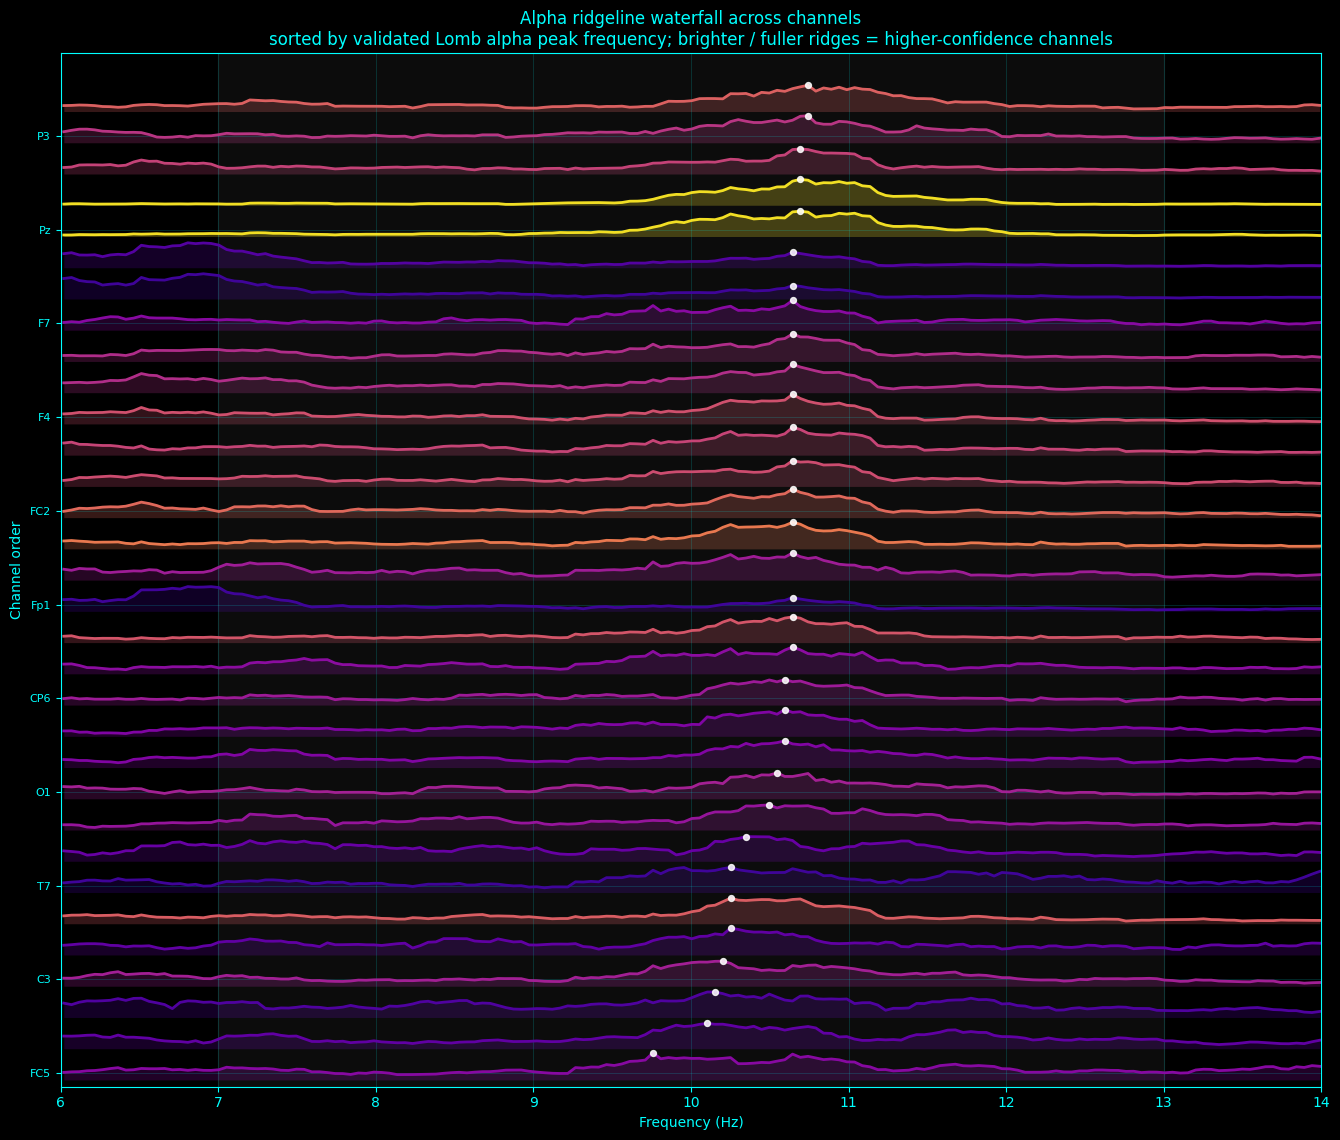

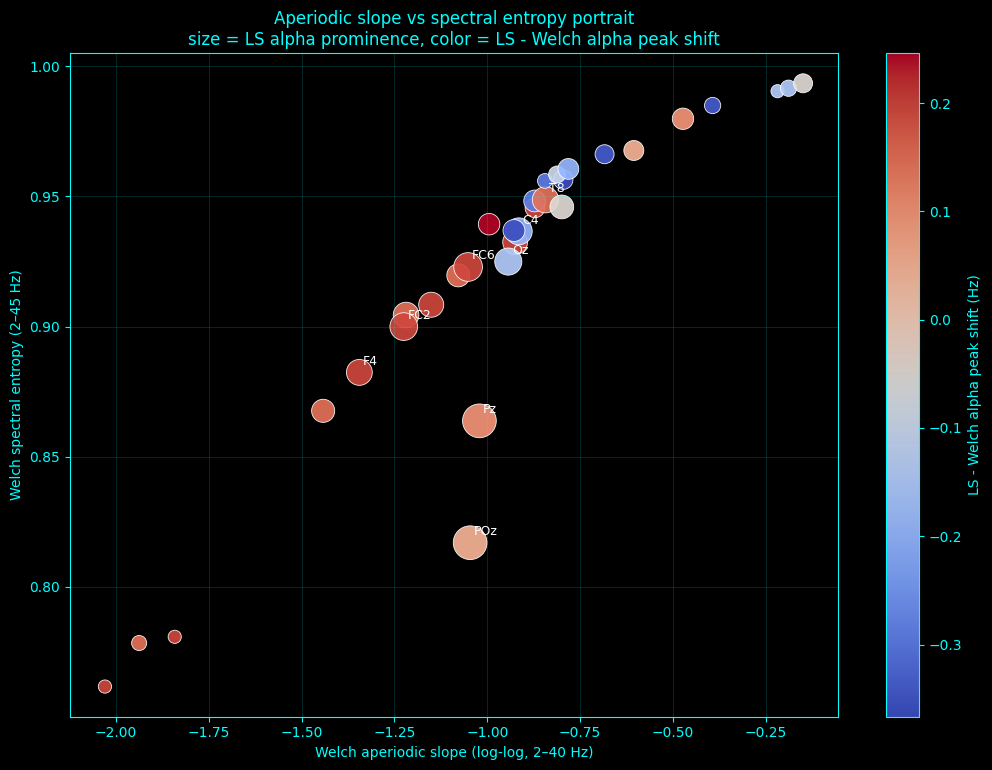


Saved refined outputs:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/exploratory_lomb_scargle_all_channels_FIXED_outputs.npz
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/lomb_scargle_all_channels_FIXED_summary.csv
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/exploratory_lomb_scargle_all_channels_FIXED_notes.txt
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/plots

Saved plot files:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/plots/01_raw_welch_qc_full_range.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/plots/02_clean_consensus_lomb_vs_welch.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/plots/03_c

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_lomb_scargle_all_channels_FIXED")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]
selected_channels = eeg_channel_names.copy()

# -------------------------------------------------------
# COMPARISON SAMPLING STRATEGY
# -------------------------------------------------------
# 1 = keep full 1000 Hz for the comparison pass
# 5 = optional faster exploratory mode (~200 Hz)
comparison_downsample_factor = 1
fs_compare = sampling_rate / comparison_downsample_factor

# Frequency controls
fmin_raw, fmax_raw = 1.0, 60.0
fmin_compare, fmax_compare = 2.0, 45.0
n_lomb_freqs = 1200
alpha_band = (7.0, 13.0)
welch_window_sec = 4.0
welch_overlap = 0.50

# Exploratory preprocessing
apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

# Aperiodic fit on CLEAN comparison spectrum
aperiodic_fit_range = (2.0, 40.0)
exclude_slope_bands = [(7.0, 14.0)]

eps = 1e-12
ACCENT = "cyan"
BG = "black"

roi_definitions = {
    "frontal":   ["Fp1", "Fpz", "Fp2", "F3", "Fz", "F4"],
    "central":   ["C3", "Cz", "C4"],
    "posterior": ["P3", "Pz", "P4", "O1", "Oz", "O2"],
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def style_ax(ax, polar=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    if polar:
        try:
            ax.spines["polar"].set_color(ACCENT)
        except Exception:
            pass
    else:
        for spine in ax.spines.values():
            spine.set_color(ACCENT)

def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=9):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def smooth_matrix_along_freq(mat, win=11):
    out = np.full_like(mat, np.nan, dtype=float)
    for j in range(mat.shape[1]):
        out[:, j] = smooth_1d(mat[:, j], win=win)
    return out

def compute_lomb_scargle(time_sec, y, freqs_hz):
    omega = 2.0 * np.pi * freqs_hz
    return signal.lombscargle(
        time_sec,
        y,
        omega,
        normalize=True,
        floating_mean=True,
    )

def compute_welch_psd(y, fs, freqs_hz, window_sec=4.0, overlap=0.5):
    nperseg = min(int(window_sec * fs), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = int(overlap * nperseg)

    welch_freqs, welch_psd = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
    )
    return np.interp(freqs_hz, welch_freqs, welch_psd)

def band_mask(freqs_hz, lo, hi):
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def safe_trapezoid(y, x):
    if hasattr(np, "trapezoid"):
        return np.trapezoid(y, x)
    return np.trapz(y, x)

def area_normalize(freqs_hz, spectrum_1d, lo=2.0, hi=45.0):
    spectrum_1d = np.asarray(spectrum_1d, dtype=float)
    out = np.full_like(spectrum_1d, np.nan, dtype=float)
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(mask) < 2:
        return out
    area = safe_trapezoid(spectrum_1d[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out
    out[mask] = spectrum_1d[mask] / area
    return out

def spectral_entropy(freqs_hz, spectrum_1d, lo=2.0, hi=45.0):
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(spectrum_1d)
    p = np.asarray(spectrum_1d[mask], dtype=float)
    p = np.maximum(p, 0.0)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    p = p / s
    h = -np.sum(p * np.log(p + eps))
    hmax = np.log(len(p) + eps)
    return float(h / (hmax + eps))

def shape_correlation(freqs_hz, x, y, lo=2.0, hi=45.0):
    mask = (
        band_mask(freqs_hz, lo, hi)
        & np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
    )
    if np.sum(mask) < 5:
        return np.nan
    a = np.log10(x[mask] + eps)
    b = np.log10(y[mask] + eps)
    return float(np.corrcoef(a, b)[0, 1])

def estimate_aperiodic_slope(freqs_hz, spectrum_1d, fit_range=(2.0, 40.0), exclude_bands=None):
    lo, hi = fit_range
    mask = band_mask(freqs_hz, lo, hi) & np.isfinite(spectrum_1d) & (spectrum_1d > 0)
    if exclude_bands is not None:
        for blo, bhi in exclude_bands:
            mask &= ~band_mask(freqs_hz, blo, bhi)
    if np.sum(mask) < 6:
        return np.nan, np.nan, np.nan

    x = np.log10(freqs_hz[mask])
    y = np.log10(spectrum_1d[mask] + eps)
    slope, intercept = np.polyfit(x, y, deg=1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - ss_res / (ss_tot + eps)
    return float(slope), float(intercept), float(r2)

def percentile_limits(x, lo=1, hi=99):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def robust_unit_interval(x, lo=5, hi=95):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) < 3:
        return out
    a, b = np.nanpercentile(x[good], [lo, hi])
    span = max(b - a, eps)
    out[good] = np.clip((x[good] - a) / span, 0, 1)
    return out

def alpha_band_fraction(freqs_hz, spectrum_1d, band=(7.0, 13.0), total_band=(2.0, 45.0)):
    spectrum_1d = np.asarray(spectrum_1d, dtype=float)
    total_mask = band_mask(freqs_hz, total_band[0], total_band[1]) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    band_only_mask = band_mask(freqs_hz, band[0], band[1]) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(total_mask) < 2 or np.sum(band_only_mask) < 2:
        return np.nan
    total_area = safe_trapezoid(spectrum_1d[total_mask], freqs_hz[total_mask])
    band_area = safe_trapezoid(spectrum_1d[band_only_mask], freqs_hz[band_only_mask])
    if not np.isfinite(total_area) or total_area <= 0:
        return np.nan
    return float(band_area / (total_area + eps))

def robust_peak_in_band(
    freqs_hz,
    spectrum_1d,
    band=(7.0, 13.0),
    total_band=(2.0, 45.0),
    smooth_win=11,
    edge_margin_hz=0.35,
    min_contrast=1.45,
    min_band_fraction=0.08,
):
    """
    Returns:
        peak_freq, peak_height, peak_prominence, peak_contrast, alpha_fraction, is_valid_peak
    """
    mask = band_mask(freqs_hz, band[0], band[1]) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 7:
        return np.nan, np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y_raw = np.asarray(spectrum_1d[mask], dtype=float)
    y = smooth_1d(y_raw, win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, False

    prominences = signal.peak_prominences(y, peaks)[0]
    heights = y[peaks]

    edge_ok = (f[peaks] >= band[0] + edge_margin_hz) & (f[peaks] <= band[1] - edge_margin_hz)
    peaks = peaks[edge_ok]
    prominences = prominences[edge_ok]
    heights = heights[edge_ok]

    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, False

    local_roughness = np.nanmedian(np.abs(np.diff(y))) if len(y) > 2 else 0.0
    min_prominence = max(0.06 * np.nanmax(y), 2.0 * local_roughness)

    strong = prominences >= min_prominence
    peaks = peaks[strong]
    prominences = prominences[strong]
    heights = heights[strong]

    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, False

    baseline = np.nanmedian(y) + eps
    contrasts = heights / baseline
    scores = prominences * contrasts

    winner = int(np.argmax(scores))
    peak_idx = peaks[winner]
    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(contrasts[winner])

    alpha_fraction = alpha_band_fraction(freqs_hz, spectrum_1d, band=band, total_band=total_band)

    is_valid = bool(
        np.isfinite(peak_freq)
        and np.isfinite(peak_prominence)
        and np.isfinite(peak_contrast)
        and np.isfinite(alpha_fraction)
        and (peak_prominence >= min_prominence)
        and (peak_contrast >= min_contrast)
        and (alpha_fraction >= min_band_fraction)
    )

    return peak_freq, peak_height, peak_prominence, peak_contrast, alpha_fraction, is_valid

def roi_summary_spectrum(matrix, channel_names, roi_channels, smooth_win=11):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        nan_vec = np.full(matrix.shape[0], np.nan)
        return nan_vec, nan_vec, nan_vec

    roi = matrix[:, idx]
    med = np.nanmedian(roi, axis=1)
    q25 = np.nanquantile(roi, 0.25, axis=1)
    q75 = np.nanquantile(roi, 0.75, axis=1)

    med = smooth_1d(med, win=smooth_win)
    q25 = smooth_1d(q25, win=smooth_win)
    q75 = smooth_1d(q75, win=smooth_win)
    return med, q25, q75

def approximate_head_polar(channel):
    """
    Approximate 10-20 scalp layout in polar coordinates.
    angle: 0 = front, clockwise
    radius: 0 center -> 1 edge
    """
    pos = {
        "Fp1": (-0.35, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.35, 1.00),
        "F7": (-0.95, 0.65), "F3": (-0.35, 0.65), "Fz": (0.00, 0.72), "F4": (0.35, 0.65), "F8": (0.95, 0.65),
        "FC5": (-0.75, 0.35), "FC1": (-0.20, 0.35), "FC2": (0.20, 0.35), "FC6": (0.75, 0.35),
        "M1": (-1.12, 0.05), "T7": (-1.00, 0.00), "C3": (-0.28, 0.00), "Cz": (0.00, 0.00), "C4": (0.28, 0.00), "T8": (1.00, 0.00), "M2": (1.12, 0.05),
        "CP5": (-0.75, -0.30), "CP1": (-0.20, -0.30), "CP2": (0.20, -0.30), "CP6": (0.75, -0.30),
        "P7": (-0.95, -0.62), "P3": (-0.30, -0.62), "Pz": (0.00, -0.68), "P4": (0.30, -0.62), "P8": (0.95, -0.62),
        "POz": (0.00, -0.86), "O1": (-0.25, -1.00), "Oz": (0.00, -1.05), "O2": (0.25, -1.00),
    }
    x, y = pos[channel]
    theta = np.arctan2(x, y)
    if theta < 0:
        theta += 2 * np.pi
    r = np.sqrt(x ** 2 + y ** 2) / 1.15
    return theta, r

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

if comparison_downsample_factor == 1:
    segment_ds = segment.copy()
else:
    segment_ds = signal.resample_poly(segment, up=1, down=comparison_downsample_factor, axis=0)

time_ds = np.arange(segment_ds.shape[0], dtype=float) / fs_compare
freqs_hz = np.linspace(fmin_raw, fmax_raw, n_lomb_freqs)

nyquist_compare = 0.5 * fs_compare
if fmax_raw >= nyquist_compare:
    raise ValueError(
        f"fmax_raw={fmax_raw} Hz is too high for fs_compare={fs_compare} Hz "
        f"(Nyquist={nyquist_compare} Hz)."
    )

print(f"Loaded EEG data shape: {eeg_data.shape}")
print(f"Segment shape: {segment.shape}")
print(f"Comparison shape: {segment_ds.shape}")
print(f"Comparison sampling rate: {fs_compare:.1f} Hz")
print(f"Comparison downsample factor: {comparison_downsample_factor}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
raw_lomb_list = []
raw_welch_list = []
clean_lomb_list = []
clean_welch_list = []
summary_rows = []

for ch_name in selected_channels:
    ch_idx = eeg_channel_names.index(ch_name)
    y = preprocess_channel(
        segment_ds[:, ch_idx],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    lomb_raw = compute_lomb_scargle(time_ds, y, freqs_hz)
    welch_raw = compute_welch_psd(
        y,
        fs_compare,
        freqs_hz,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
    )

    lomb_clean = area_normalize(freqs_hz, lomb_raw, lo=fmin_compare, hi=fmax_compare)
    welch_clean = area_normalize(freqs_hz, welch_raw, lo=fmin_compare, hi=fmax_compare)

    lomb_peak_hz, lomb_peak_height, lomb_peak_prom, lomb_peak_contrast, lomb_alpha_frac, lomb_valid = robust_peak_in_band(
        freqs_hz, lomb_clean, band=alpha_band, total_band=(fmin_compare, fmax_compare), smooth_win=11
    )
    welch_peak_hz, welch_peak_height, welch_peak_prom, welch_peak_contrast, welch_alpha_frac, welch_valid = robust_peak_in_band(
        freqs_hz, welch_clean, band=alpha_band, total_band=(fmin_compare, fmax_compare), smooth_win=11
    )

    signed_shift = (
        float(lomb_peak_hz - welch_peak_hz)
        if np.isfinite(lomb_peak_hz) and np.isfinite(welch_peak_hz)
        else np.nan
    )

    slope, intercept, r2 = estimate_aperiodic_slope(
        freqs_hz,
        welch_clean,
        fit_range=aperiodic_fit_range,
        exclude_bands=exclude_slope_bands,
    )

    summary_rows.append({
        "channel": ch_name,

        "lomb_alpha_peak_frequency_Hz": lomb_peak_hz,
        "lomb_alpha_peak_height_area_norm": lomb_peak_height,
        "lomb_alpha_peak_prominence": lomb_peak_prom,
        "lomb_alpha_peak_contrast": lomb_peak_contrast,
        "lomb_alpha_band_fraction_2_45Hz": lomb_alpha_frac,

        "welch_alpha_peak_frequency_Hz": welch_peak_hz,
        "welch_alpha_peak_height_area_norm": welch_peak_height,
        "welch_alpha_peak_prominence": welch_peak_prom,
        "welch_alpha_peak_contrast": welch_peak_contrast,
        "welch_alpha_band_fraction_2_45Hz": welch_alpha_frac,

        "alpha_peak_shift_signed_Hz": signed_shift,
        "alpha_peak_alignment_abs_diff_Hz": abs(signed_shift) if np.isfinite(signed_shift) else np.nan,

        "shape_correlation_log_area_norm_2_45Hz": shape_correlation(
            freqs_hz, lomb_clean, welch_clean, lo=fmin_compare, hi=fmax_compare
        ),
        "lomb_spectral_entropy_2_45Hz": spectral_entropy(freqs_hz, lomb_clean, lo=fmin_compare, hi=fmax_compare),
        "welch_spectral_entropy_2_45Hz": spectral_entropy(freqs_hz, welch_clean, lo=fmin_compare, hi=fmax_compare),

        "welch_aperiodic_slope_loglog_2_40Hz": slope,
        "welch_aperiodic_intercept_loglog_2_40Hz": intercept,
        "welch_aperiodic_fit_r2": r2,

        "has_valid_lomb_alpha_peak": bool(lomb_valid),
        "has_valid_welch_alpha_peak": bool(welch_valid),
    })

    raw_lomb_list.append(lomb_raw)
    raw_welch_list.append(welch_raw)
    clean_lomb_list.append(lomb_clean)
    clean_welch_list.append(welch_clean)

summary_df = pd.DataFrame(summary_rows)
raw_lomb = np.column_stack(raw_lomb_list)
raw_welch = np.column_stack(raw_welch_list)
clean_lomb = np.column_stack(clean_lomb_list)
clean_welch = np.column_stack(clean_welch_list)

display_lomb = smooth_matrix_along_freq(clean_lomb, win=11)
display_welch = smooth_matrix_along_freq(clean_welch, win=11)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "exploratory_lomb_scargle_all_channels_FIXED_outputs.npz")
summary_csv_path = os.path.join(out_dir, "lomb_scargle_all_channels_FIXED_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_lomb_scargle_all_channels_FIXED_notes.txt")

summary_df.to_csv(summary_csv_path, index=False)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_hz,
    raw_lomb=raw_lomb,
    raw_welch=raw_welch,
    clean_lomb_area_normalized_2_45Hz=clean_lomb,
    clean_welch_area_normalized_2_45Hz=clean_welch,
    display_lomb_smoothed=display_lomb,
    display_welch_smoothed=display_welch,
    channel_names=np.array(selected_channels, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    comparison_sampling_rate=fs_compare,
    comparison_downsample_factor=comparison_downsample_factor,
)

top_lomb_alpha = summary_df.sort_values(
    ["has_valid_lomb_alpha_peak", "lomb_alpha_peak_prominence"],
    ascending=[False, False],
    na_position="last"
).head(8)

peak_disagreement = summary_df.sort_values(
    "alpha_peak_alignment_abs_diff_Hz",
    ascending=False,
    na_position="last"
).head(8)

no_valid_lomb = summary_df.loc[~summary_df["has_valid_lomb_alpha_peak"], "channel"].tolist()
no_valid_welch = summary_df.loc[~summary_df["has_valid_welch_alpha_peak"], "channel"].tolist()

with open(notes_txt_path, "w") as f:
    f.write("Exploratory Lomb–Scargle all-channel notes (FIXED, stricter alpha validation)\n")
    f.write("=======================================================================\n\n")
    f.write("What this version adds:\n")
    f.write("1. Lomb and Welch are compared after the SAME area normalization over 2–45 Hz.\n")
    f.write("2. Alpha peaks must be true local peaks with prominence, edge margin, contrast, and alpha-band mass.\n")
    f.write("3. Display plots use smoothed copies only for readability; summary metrics still use the unsmoothed clean spectra.\n")
    f.write("4. ROI summary plots use median + IQR instead of mean only.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Comparison fs: {fs_compare:.1f} Hz\n")
    f.write(f"Comparison downsample factor: {comparison_downsample_factor}\n")
    f.write(f"Comparison band: {fmin_compare:.1f}–{fmax_compare:.1f} Hz\n")
    f.write(f"Alpha band: {alpha_band[0]:.1f}–{alpha_band[1]:.1f} Hz\n\n")

    f.write("Top valid Lomb alpha-prominence channels:\n")
    for _, row in top_lomb_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"LS peak={row['lomb_alpha_peak_frequency_Hz']}, "
            f"LS prom={row['lomb_alpha_peak_prominence']}, "
            f"LS alpha frac={row['lomb_alpha_band_fraction_2_45Hz']}, "
            f"Welch peak={row['welch_alpha_peak_frequency_Hz']}, "
            f"shape corr={row['shape_correlation_log_area_norm_2_45Hz']}\n"
        )

    f.write("\nLargest LS–Welch alpha disagreements:\n")
    for _, row in peak_disagreement.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"|Δ|={row['alpha_peak_alignment_abs_diff_Hz']}, "
            f"LS peak={row['lomb_alpha_peak_frequency_Hz']}, "
            f"Welch peak={row['welch_alpha_peak_frequency_Hz']}\n"
        )

    f.write("\nChannels with no valid Lomb alpha peak:\n")
    f.write("  " + (", ".join(no_valid_lomb) if len(no_valid_lomb) else "none") + "\n")
    f.write("Channels with no valid Welch alpha peak:\n")
    f.write("  " + (", ".join(no_valid_welch) if len(no_valid_welch) else "none") + "\n")

# -------------------------------------------------------
# MASKS
# -------------------------------------------------------
compare_mask = band_mask(freqs_hz, fmin_compare, fmax_compare)
alpha_mask = band_mask(freqs_hz, 6.0, 14.0)

plot_paths = []

# -------------------------------------------------------
# PLOT 01 — raw Welch QC
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)

median_raw_welch = np.nanmedian(raw_welch, axis=1)
q25_raw_welch = np.nanquantile(raw_welch, 0.25, axis=1)
q75_raw_welch = np.nanquantile(raw_welch, 0.75, axis=1)

ax.semilogy(freqs_hz, median_raw_welch, color="white", linewidth=2.0, label="Welch median (raw)")
ax.fill_between(freqs_hz, q25_raw_welch, q75_raw_welch, color="white", alpha=0.12)
ax.axvline(60.0, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.7, label="60 Hz")
ax.set_xlim(fmin_raw, fmax_raw)
ax.set_title("Raw Welch QC: full range before clean comparison normalization")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD (raw Welch units)")
ax.legend(loc="upper right")

plot1_path = os.path.join(plots_dir, "01_raw_welch_qc_full_range.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot1_path)

# -------------------------------------------------------
# PLOT 02 — clean all-channel consensus
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)

median_lomb = np.nanmedian(clean_lomb, axis=1)
q25_lomb = np.nanquantile(clean_lomb, 0.25, axis=1)
q75_lomb = np.nanquantile(clean_lomb, 0.75, axis=1)

median_welch = np.nanmedian(clean_welch, axis=1)
q25_welch = np.nanquantile(clean_welch, 0.25, axis=1)
q75_welch = np.nanquantile(clean_welch, 0.75, axis=1)

ax.plot(freqs_hz[compare_mask], median_lomb[compare_mask], color=ACCENT, linewidth=2.2, label="Lomb median")
ax.fill_between(freqs_hz[compare_mask], q25_lomb[compare_mask], q75_lomb[compare_mask], color=ACCENT, alpha=0.14)

ax.plot(freqs_hz[compare_mask], median_welch[compare_mask], color="white", linewidth=2.0, label="Welch median")
ax.fill_between(freqs_hz[compare_mask], q25_welch[compare_mask], q75_welch[compare_mask], color="white", alpha=0.12)

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.set_xlim(fmin_compare, fmax_compare)
ax.set_title("All-channel spectral consensus after matched 2–45 Hz area normalization")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Area-normalized spectral density")
ax.legend(loc="upper right")

plot2_path = os.path.join(plots_dir, "02_clean_consensus_lomb_vs_welch.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot2_path)

# -------------------------------------------------------
# PLOT 03 — all-channel clean Lomb overlay
# -------------------------------------------------------
posterior_channels = {"P3", "Pz", "P4", "O1", "Oz", "O2"}

fig, ax = plt.subplots(figsize=(11.5, 5.5), facecolor=BG)
style_ax(ax)

for i, ch_name in enumerate(selected_channels):
    curve = clean_lomb[:, i]
    if ch_name in posterior_channels:
        ax.plot(freqs_hz[compare_mask], curve[compare_mask], color="white", linewidth=1.1, alpha=0.55)
    else:
        ax.plot(freqs_hz[compare_mask], curve[compare_mask], color=ACCENT, linewidth=0.8, alpha=0.10)

ax.plot(freqs_hz[compare_mask], median_lomb[compare_mask], color=ACCENT, linewidth=2.5, label="Lomb median")
ax.set_xlim(fmin_compare, fmax_compare)
ax.set_title("All-channel Lomb overlay after clean normalization")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Area-normalized spectral density")
ax.legend(loc="upper right")

plot3_path = os.path.join(plots_dir, "03_clean_all_channel_lomb_overlay.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot3_path)

# -------------------------------------------------------
# PLOT 04 — refined alpha zoom overlay
# -------------------------------------------------------
peak_df = summary_df[summary_df["has_valid_lomb_alpha_peak"]].copy()
top_alpha = peak_df.sort_values("lomb_alpha_peak_prominence", ascending=False).head(8)
top_alpha_channels = list(top_alpha["channel"].values)

fig, ax = plt.subplots(figsize=(11.8, 5.8), facecolor=BG)
style_ax(ax)

for i, _ in enumerate(selected_channels):
    curve = display_lomb[:, i]
    ax.plot(freqs_hz[alpha_mask], curve[alpha_mask], color=ACCENT, linewidth=0.8, alpha=0.08)

palette = plt.cm.plasma(np.linspace(0.12, 0.92, max(len(top_alpha_channels), 1)))
top_vals = []

for k, (_, row) in enumerate(top_alpha.iterrows()):
    ch_name = row["channel"]
    ch_idx = selected_channels.index(ch_name)
    curve = display_lomb[:, ch_idx]
    col = palette[k]

    ax.plot(freqs_hz[alpha_mask], curve[alpha_mask], color=col, linewidth=2.2, alpha=0.98, label=ch_name)
    ax.axvline(row["lomb_alpha_peak_frequency_Hz"], color=col, linestyle="--", linewidth=0.9, alpha=0.55)

    y_peak = np.interp(row["lomb_alpha_peak_frequency_Hz"], freqs_hz, curve)
    ax.scatter([row["lomb_alpha_peak_frequency_Hz"]], [y_peak], s=24, color="white", zorder=4)
    ax.text(row["lomb_alpha_peak_frequency_Hz"] + 0.035, y_peak, ch_name, color="white", fontsize=9)

    top_vals.extend(curve[alpha_mask][np.isfinite(curve[alpha_mask])].tolist())

if len(top_vals):
    y_hi = np.nanpercentile(np.asarray(top_vals), 99.5)
    ax.set_ylim(0, y_hi * 1.15)

ax.set_xlim(6.0, 14.0)
ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.04)
ax.set_title("Alpha-band overlay across all channels (validated Lomb alpha peaks only)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Area-normalized spectral density (smoothed display)")

plot4_path = os.path.join(plots_dir, "04_alpha_zoom_overlay_valid_peaks_only.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot4_path)

# -------------------------------------------------------
# PLOT 05 — refined clean heatmap sorting
# -------------------------------------------------------
sort_df = summary_df.copy()
sort_df["sort_valid"] = sort_df["has_valid_lomb_alpha_peak"].astype(int)
sort_df = sort_df.sort_values(
    by=["sort_valid", "lomb_alpha_peak_prominence", "lomb_alpha_peak_frequency_Hz"],
    ascending=[False, False, True],
    na_position="last"
).reset_index(drop=True)

sorted_channels = list(sort_df["channel"].values)
sorted_idx = [selected_channels.index(ch) for ch in sorted_channels]

heat = np.log10(display_lomb[compare_mask, :][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12.2, 10.2), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_hz[compare_mask][0], freqs_hz[compare_mask][-1], len(sorted_channels), 0],
)

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.set_title("Lomb–Scargle heatmap after clean normalization\n(sorted by validated alpha presence, prominence, then frequency)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized spectral density)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "05_clean_lomb_heatmap_refined.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot5_path)

# -------------------------------------------------------
# PLOT 06 — ROI median + IQR
# -------------------------------------------------------
frontal_lomb_med, frontal_lomb_q25, frontal_lomb_q75 = roi_summary_spectrum(display_lomb, selected_channels, roi_definitions["frontal"], smooth_win=11)
central_lomb_med, central_lomb_q25, central_lomb_q75 = roi_summary_spectrum(display_lomb, selected_channels, roi_definitions["central"], smooth_win=11)
posterior_lomb_med, posterior_lomb_q25, posterior_lomb_q75 = roi_summary_spectrum(display_lomb, selected_channels, roi_definitions["posterior"], smooth_win=11)

frontal_welch_med, frontal_welch_q25, frontal_welch_q75 = roi_summary_spectrum(display_welch, selected_channels, roi_definitions["frontal"], smooth_win=11)
central_welch_med, central_welch_q25, central_welch_q75 = roi_summary_spectrum(display_welch, selected_channels, roi_definitions["central"], smooth_win=11)
posterior_welch_med, posterior_welch_q25, posterior_welch_q75 = roi_summary_spectrum(display_welch, selected_channels, roi_definitions["posterior"], smooth_win=11)

fig, ax = plt.subplots(figsize=(12.0, 5.8), facecolor=BG)
style_ax(ax)

ax.fill_between(freqs_hz[compare_mask], frontal_lomb_q25[compare_mask], frontal_lomb_q75[compare_mask], color="white", alpha=0.10)
ax.fill_between(freqs_hz[compare_mask], central_lomb_q25[compare_mask], central_lomb_q75[compare_mask], color=ACCENT, alpha=0.10)
ax.fill_between(freqs_hz[compare_mask], posterior_lomb_q25[compare_mask], posterior_lomb_q75[compare_mask], color="yellow", alpha=0.10)

ax.plot(freqs_hz[compare_mask], frontal_lomb_med[compare_mask], color="white", linewidth=2.0, label="Frontal LS median")
ax.plot(freqs_hz[compare_mask], central_lomb_med[compare_mask], color=ACCENT, linewidth=2.0, label="Central LS median")
ax.plot(freqs_hz[compare_mask], posterior_lomb_med[compare_mask], color="yellow", linewidth=2.2, label="Posterior LS median")

ax.plot(freqs_hz[compare_mask], frontal_welch_med[compare_mask], color="white", linewidth=1.3, linestyle="--", alpha=0.9, label="Frontal Welch median")
ax.plot(freqs_hz[compare_mask], central_welch_med[compare_mask], color=ACCENT, linewidth=1.3, linestyle="--", alpha=0.9, label="Central Welch median")
ax.plot(freqs_hz[compare_mask], posterior_welch_med[compare_mask], color="yellow", linewidth=1.5, linestyle="--", alpha=0.9, label="Posterior Welch median")

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.set_xlim(fmin_compare, fmax_compare)
ax.set_title("Regional median spectra after matched clean normalization")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Area-normalized spectral density (smoothed display)")
ax.legend(loc="upper right", ncol=2)

plot6_path = os.path.join(plots_dir, "06_clean_roi_lomb_vs_welch_median_iqr.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot6_path)

# -------------------------------------------------------
# PLOT 07 — agreement scatter using validated peaks only
# -------------------------------------------------------
agree_df = summary_df[
    summary_df["has_valid_lomb_alpha_peak"] & summary_df["has_valid_welch_alpha_peak"]
].copy()

fig, ax = plt.subplots(figsize=(8.3, 8.1), facecolor=BG)
style_ax(ax)

x = agree_df["welch_alpha_peak_frequency_Hz"].values
y = agree_df["lomb_alpha_peak_frequency_Hz"].values
c = agree_df["alpha_peak_alignment_abs_diff_Hz"].values
s = 90 + 260 * robust_unit_interval(agree_df["lomb_alpha_peak_prominence"].values)

scatter = ax.scatter(x, y, c=c, s=s, alpha=0.92, cmap="plasma", edgecolors="white", linewidths=0.6)

if len(x) > 0:
    lo = min(np.min(x), np.min(y)) - 0.15
    hi = max(np.max(x), np.max(y)) + 0.15
else:
    lo, hi = 7.0, 13.0

ax.plot([lo, hi], [lo, hi], color="white", linestyle="--", linewidth=1.2, alpha=0.9)

to_annotate = agree_df.sort_values(
    ["alpha_peak_alignment_abs_diff_Hz", "lomb_alpha_peak_prominence"],
    ascending=[False, False]
).head(8)

for _, row in to_annotate.iterrows():
    ax.text(
        row["welch_alpha_peak_frequency_Hz"] + 0.03,
        row["lomb_alpha_peak_frequency_Hz"] + 0.03,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_title("Alpha peak agreement across channels\n(validated peaks only)")
ax.set_xlabel("Welch alpha peak frequency (Hz)")
ax.set_ylabel("Lomb–Scargle alpha peak frequency (Hz)")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("|LS peak - Welch peak| (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot7_path = os.path.join(plots_dir, "07_alpha_peak_agreement_valid_peaks_only.png")
plt.tight_layout()
plt.savefig(plot7_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot7_path)

# -------------------------------------------------------
# PLOT 08 — descriptor space with validated peaks only
# -------------------------------------------------------
desc_df = summary_df[summary_df["has_valid_lomb_alpha_peak"]].copy()

fig, ax = plt.subplots(figsize=(10.2, 7.2), facecolor=BG)
style_ax(ax)

sizes = 100 + 450 * robust_unit_interval(desc_df["lomb_alpha_band_fraction_2_45Hz"].values)
scatter = ax.scatter(
    desc_df["shape_correlation_log_area_norm_2_45Hz"].values,
    desc_df["lomb_alpha_peak_prominence"].values,
    c=desc_df["alpha_peak_alignment_abs_diff_Hz"].values,
    s=sizes,
    alpha=0.92,
    cmap="plasma",
    edgecolors="white",
    linewidths=0.6,
)

ann_df = desc_df.sort_values(
    ["lomb_alpha_peak_prominence", "shape_correlation_log_area_norm_2_45Hz"],
    ascending=[False, False]
).head(8)

for _, row in ann_df.iterrows():
    ax.text(
        row["shape_correlation_log_area_norm_2_45Hz"] + 0.005,
        row["lomb_alpha_peak_prominence"] + 0.002,
        row["channel"],
        color="white",
        fontsize=9,
    )

ax.set_title("Cross-estimator descriptor space after clean normalization")
ax.set_xlabel("Shape correlation: log(area-normalized LS) vs log(area-normalized Welch)")
ax.set_ylabel("Lomb alpha peak prominence")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("|LS peak - Welch peak| (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot8_path = os.path.join(plots_dir, "08_cross_estimator_descriptor_space_refined.png")
plt.tight_layout()
plt.savefig(plot8_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot8_path)

# -------------------------------------------------------
# ALIGN SUMMARY TO CHANNEL ORDER
# -------------------------------------------------------
summary_ord = (
    summary_df
    .set_index("channel")
    .reindex(selected_channels)
    .reset_index()
    .rename(columns={"index": "channel"})
)

peak_freq_ls = summary_ord["lomb_alpha_peak_frequency_Hz"].values
peak_freq_welch = summary_ord["welch_alpha_peak_frequency_Hz"].values
peak_shift_hz = summary_ord["alpha_peak_shift_signed_Hz"].values

prom = summary_ord["lomb_alpha_peak_prominence"].values
contrast = summary_ord["lomb_alpha_peak_contrast"].values
shape_corr = summary_ord["shape_correlation_log_area_norm_2_45Hz"].values
peak_diff = summary_ord["alpha_peak_alignment_abs_diff_Hz"].values

prom_cut = np.nanpercentile(prom[np.isfinite(prom)], 65)
contrast_cut = np.nanpercentile(contrast[np.isfinite(contrast)], 60)
shape_cut = np.nanpercentile(shape_corr[np.isfinite(shape_corr)], 35)
diff_cut = np.nanpercentile(peak_diff[np.isfinite(peak_diff)], 70)

high_conf_mask = (
    summary_ord["has_valid_lomb_alpha_peak"].values
    & np.isfinite(prom)
    & np.isfinite(contrast)
    & np.isfinite(shape_corr)
    & np.isfinite(peak_diff)
    & (prom >= prom_cut)
    & (contrast >= contrast_cut)
    & (shape_corr >= shape_cut)
    & (peak_diff <= diff_cut)
)

# -------------------------------------------------------
# PLOT 09 — cross-estimator discrepancy heatmap
# -------------------------------------------------------
log_diff = np.log10(display_lomb + eps) - np.log10(display_welch + eps)

sort_metric = np.abs(np.nan_to_num(peak_shift_hz, nan=-np.inf))
sort_order = np.argsort(-sort_metric)
sorted_channels = [selected_channels[i] for i in sort_order]
sorted_labels = [
    (f"* {selected_channels[i]}" if high_conf_mask[i] else selected_channels[i])
    for i in sort_order
]

heat = log_diff[compare_mask, :][:, sort_order].T
vabs = np.nanpercentile(np.abs(heat[np.isfinite(heat)]), 98)

fig, ax = plt.subplots(figsize=(13.5, 9.0), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=-vabs,
    vmax=vabs,
    extent=[freqs_hz[compare_mask][0], freqs_hz[compare_mask][-1], len(sorted_channels), 0],
)

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.text(alpha_band[0] + 0.15, 1.2, "alpha band", color="white", fontsize=10, alpha=0.85, va="bottom")
ax.set_title("Cross-estimator discrepancy map\nwarm = Lomb > Welch, cool = Lomb < Welch, * = stricter high-confidence channels")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel (sorted by |LS peak - Welch peak|)")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_labels, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(clean Lomb) - log10(clean Welch)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot9_path = os.path.join(plots_dir, "09_cross_estimator_discrepancy_heatmap.png")
plt.tight_layout()
plt.savefig(plot9_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot9_path)

# -------------------------------------------------------
# PLOT 10 — polar scalp consensus map
# -------------------------------------------------------
theta_list, r_list = [], []
for ch in selected_channels:
    th, rr = approximate_head_polar(ch)
    theta_list.append(th)
    r_list.append(rr)

theta_arr = np.asarray(theta_list)
r_arr = np.asarray(r_list)

prom_lo, prom_hi = np.nanpercentile(prom[np.isfinite(prom)], [5, 95])
prom_norm = np.clip((prom - prom_lo) / (prom_hi - prom_lo + eps), 0, 1)

shape_lo, shape_hi = np.nanpercentile(shape_corr[np.isfinite(shape_corr)], [5, 95])
shape_norm = np.clip((shape_corr - shape_lo) / (shape_hi - shape_lo + eps), 0, 1)

shift_abs = np.nanpercentile(np.abs(peak_shift_hz[np.isfinite(peak_shift_hz)]), 95)
shift_abs = max(float(shift_abs), 0.25)
shift_norm = plt.Normalize(vmin=-shift_abs, vmax=shift_abs)

cmap = plt.cm.coolwarm
rgba = cmap(shift_norm(np.clip(peak_shift_hz, -shift_abs, shift_abs)))
rgba[:, 3] = 0.35 + 0.55 * np.nan_to_num(shape_norm, nan=0.0)

sizes = 70 + 380 * np.nan_to_num(prom_norm, nan=0.0)
linew = 0.5 + 1.8 * np.nan_to_num(shape_norm, nan=0.0)

fig = plt.figure(figsize=(10.8, 10.8), facecolor=BG)
ax = fig.add_subplot(111, projection="polar")
style_ax(ax, polar=True)

ax.scatter(
    theta_arr,
    r_arr,
    s=sizes,
    c=rgba,
    edgecolors="white",
    linewidths=linew,
    zorder=3,
)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rmax(1.05)
ax.set_rticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels([])

label_candidates = np.argsort(
    -(0.65 * np.nan_to_num(prom_norm, nan=0.0) + 0.35 * np.nan_to_num(shape_norm, nan=0.0))
)[:8]

for idx in label_candidates:
    ch = selected_channels[idx]
    ax.text(theta_arr[idx], r_arr[idx] + 0.08, ch, color="white", fontsize=10, ha="center", va="center")

ax.set_title(
    "Polar scalp consensus map\n"
    "marker size = LS alpha prominence, color = LS - Welch alpha peak shift,\n"
    "opacity / edge width = cross-estimator shape agreement"
)

mappable = plt.cm.ScalarMappable(norm=shift_norm, cmap=cmap)
cbar = plt.colorbar(mappable, ax=ax, pad=0.12)
cbar.set_label("LS - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot10_path = os.path.join(plots_dir, "10_polar_scalp_consensus_map.png")
plt.tight_layout()
plt.savefig(plot10_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot10_path)

# -------------------------------------------------------
# PLOT 11 — alpha ridgeline waterfall
# -------------------------------------------------------
alpha_zoom_mask = band_mask(freqs_hz, 6.0, 14.0)
f_alpha = freqs_hz[alpha_zoom_mask]
disp_alpha = display_lomb[alpha_zoom_mask, :]

valid_idx = np.where(summary_df["has_valid_lomb_alpha_peak"].values)[0]
invalid_idx = np.where(~summary_df["has_valid_lomb_alpha_peak"].values)[0]

if len(valid_idx):
    valid_order = valid_idx[np.argsort(summary_df.iloc[valid_idx]["lomb_alpha_peak_frequency_Hz"].values)]
else:
    valid_order = np.array([], dtype=int)

ridge_order = np.r_[valid_order, invalid_idx]

prom_norm_all = robust_unit_interval(summary_df["lomb_alpha_peak_prominence"].values)
cmap_ridge = plt.cm.plasma

fig, ax = plt.subplots(figsize=(13.5, 11.5), facecolor=BG)
style_ax(ax)

offset_step = 0.92
scale = 0.72

for rank, idx in enumerate(ridge_order):
    y = np.maximum(disp_alpha[:, idx], 0.0)

    peak_scale = np.nanpercentile(y[np.isfinite(y)], 99.0) if np.any(np.isfinite(y)) else 1.0
    peak_scale = max(peak_scale, eps)
    y_norm = y / peak_scale

    offset = rank * offset_step
    color = cmap_ridge(0.10 + 0.85 * prom_norm_all[idx])

    is_valid = bool(summary_df.iloc[idx]["has_valid_lomb_alpha_peak"])
    fill_alpha = 0.24 if is_valid else 0.05
    line_alpha = 0.98 if is_valid else 0.28
    lw = 2.0 if is_valid else 0.75

    ax.fill_between(f_alpha, offset, offset + scale * y_norm, color=color, alpha=fill_alpha, linewidth=0)
    ax.plot(f_alpha, offset + scale * y_norm, color=color, linewidth=lw, alpha=line_alpha)

    peak_hz = summary_df.iloc[idx]["lomb_alpha_peak_frequency_Hz"]
    if np.isfinite(peak_hz):
        ypk = np.interp(peak_hz, f_alpha, offset + scale * y_norm)
        ax.scatter([peak_hz], [ypk], s=18 if is_valid else 8, color="white", alpha=0.85 if is_valid else 0.28, zorder=4)

tick_pos, tick_lab = [], []
for k in range(0, len(ridge_order), 3):
    idx = ridge_order[k]
    tick_pos.append(k * offset_step + 0.20)
    tick_lab.append(selected_channels[idx])

ax.axvspan(alpha_band[0], alpha_band[1], color="white", alpha=0.05)
ax.set_xlim(6.0, 14.0)
ax.set_ylim(-0.2, len(ridge_order) * offset_step + 0.8)
ax.set_yticks(tick_pos)
ax.set_yticklabels(tick_lab, fontsize=8)
ax.set_title(
    "Alpha ridgeline waterfall across channels\n"
    "sorted by validated Lomb alpha peak frequency; brighter / fuller ridges = higher-confidence channels"
)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel order")

plot11_path = os.path.join(plots_dir, "11_alpha_ridgeline_waterfall_refined.png")
plt.tight_layout()
plt.savefig(plot11_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot11_path)

# -------------------------------------------------------
# PLOT 12 — aperiodic slope vs entropy portrait
# corrected: color = SIGNED LS - Welch peak shift
# -------------------------------------------------------
port_df = summary_df[summary_df["has_valid_lomb_alpha_peak"]].copy()

fig, ax = plt.subplots(figsize=(10.5, 7.8), facecolor=BG)
style_ax(ax)

sizes = 90 + 500 * robust_unit_interval(port_df["lomb_alpha_peak_prominence"].values)

shift_signed = port_df["alpha_peak_shift_signed_Hz"].values
shift_abs = np.nanpercentile(np.abs(shift_signed[np.isfinite(shift_signed)]), 95)
shift_abs = max(float(shift_abs), 0.25)

sc = ax.scatter(
    port_df["welch_aperiodic_slope_loglog_2_40Hz"].values,
    port_df["welch_spectral_entropy_2_45Hz"].values,
    s=sizes,
    c=np.clip(shift_signed, -shift_abs, shift_abs),
    cmap="coolwarm",
    alpha=0.92,
    edgecolors="white",
    linewidths=0.6
)

ann_df = port_df.sort_values("lomb_alpha_peak_prominence", ascending=False).head(8)
for _, row in ann_df.iterrows():
    ax.text(
        row["welch_aperiodic_slope_loglog_2_40Hz"] + 0.01,
        row["welch_spectral_entropy_2_45Hz"] + 0.003,
        row["channel"],
        color="white",
        fontsize=9
    )

ax.set_title(
    "Aperiodic slope vs spectral entropy portrait\n"
    "size = LS alpha prominence, color = LS - Welch alpha peak shift"
)
ax.set_xlabel("Welch aperiodic slope (log-log, 2–40 Hz)")
ax.set_ylabel("Welch spectral entropy (2–45 Hz)")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("LS - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot12_path = os.path.join(plots_dir, "12_aperiodic_entropy_portrait_refined.png")
plt.tight_layout()
plt.savefig(plot12_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()
plot_paths.append(plot12_path)

# -------------------------------------------------------
# FINAL PRINTS
# -------------------------------------------------------
print("\nSaved refined outputs:")
print(npz_path)
print(summary_csv_path)
print(notes_txt_path)
print(plots_dir)

print("\nSaved plot files:")
for p in plot_paths:
    print(p)

print("\nDone.")

Loaded NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/exploratory_lomb_scargle_all_channels_FIXED_outputs.npz
Loaded summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/lomb_scargle_all_channels_FIXED_summary.csv
Channels: 32
Frequency bins: 1200


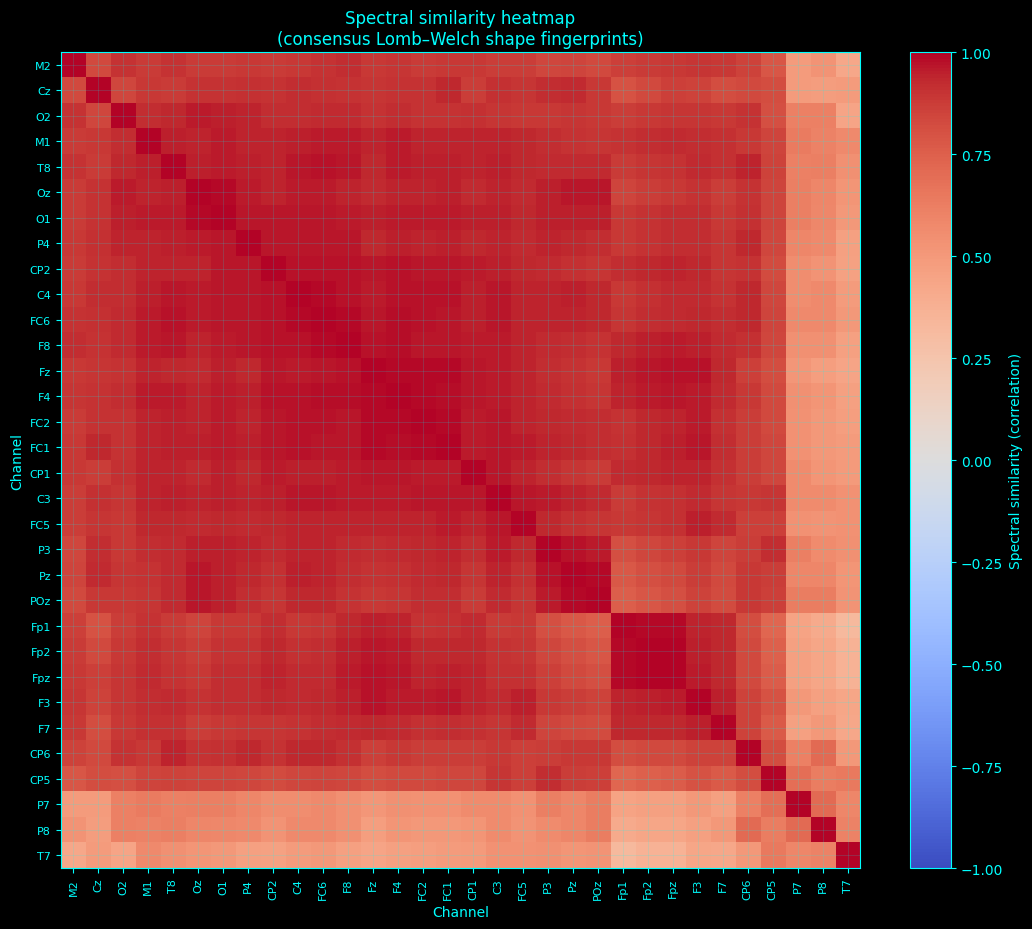

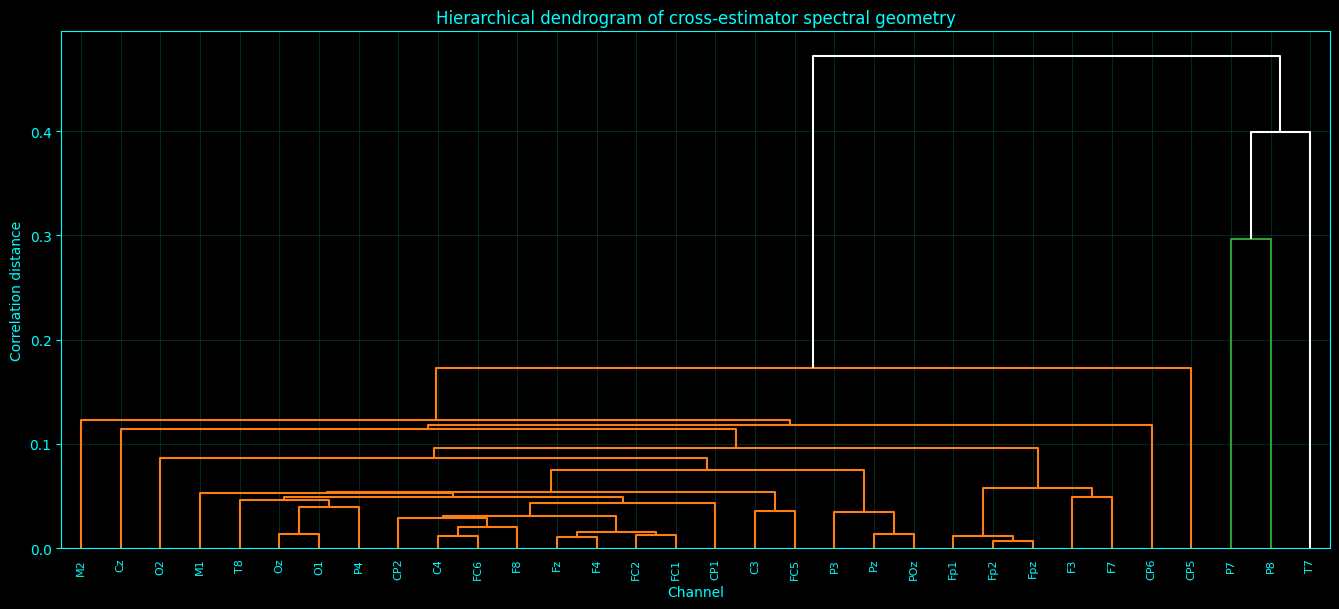

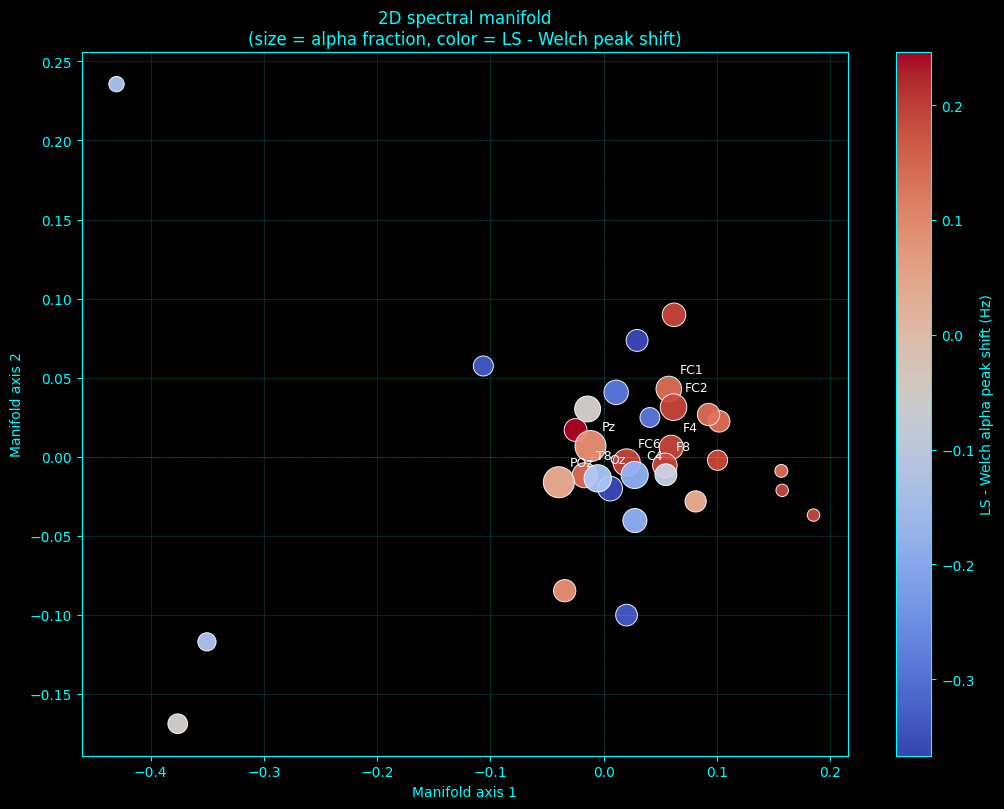

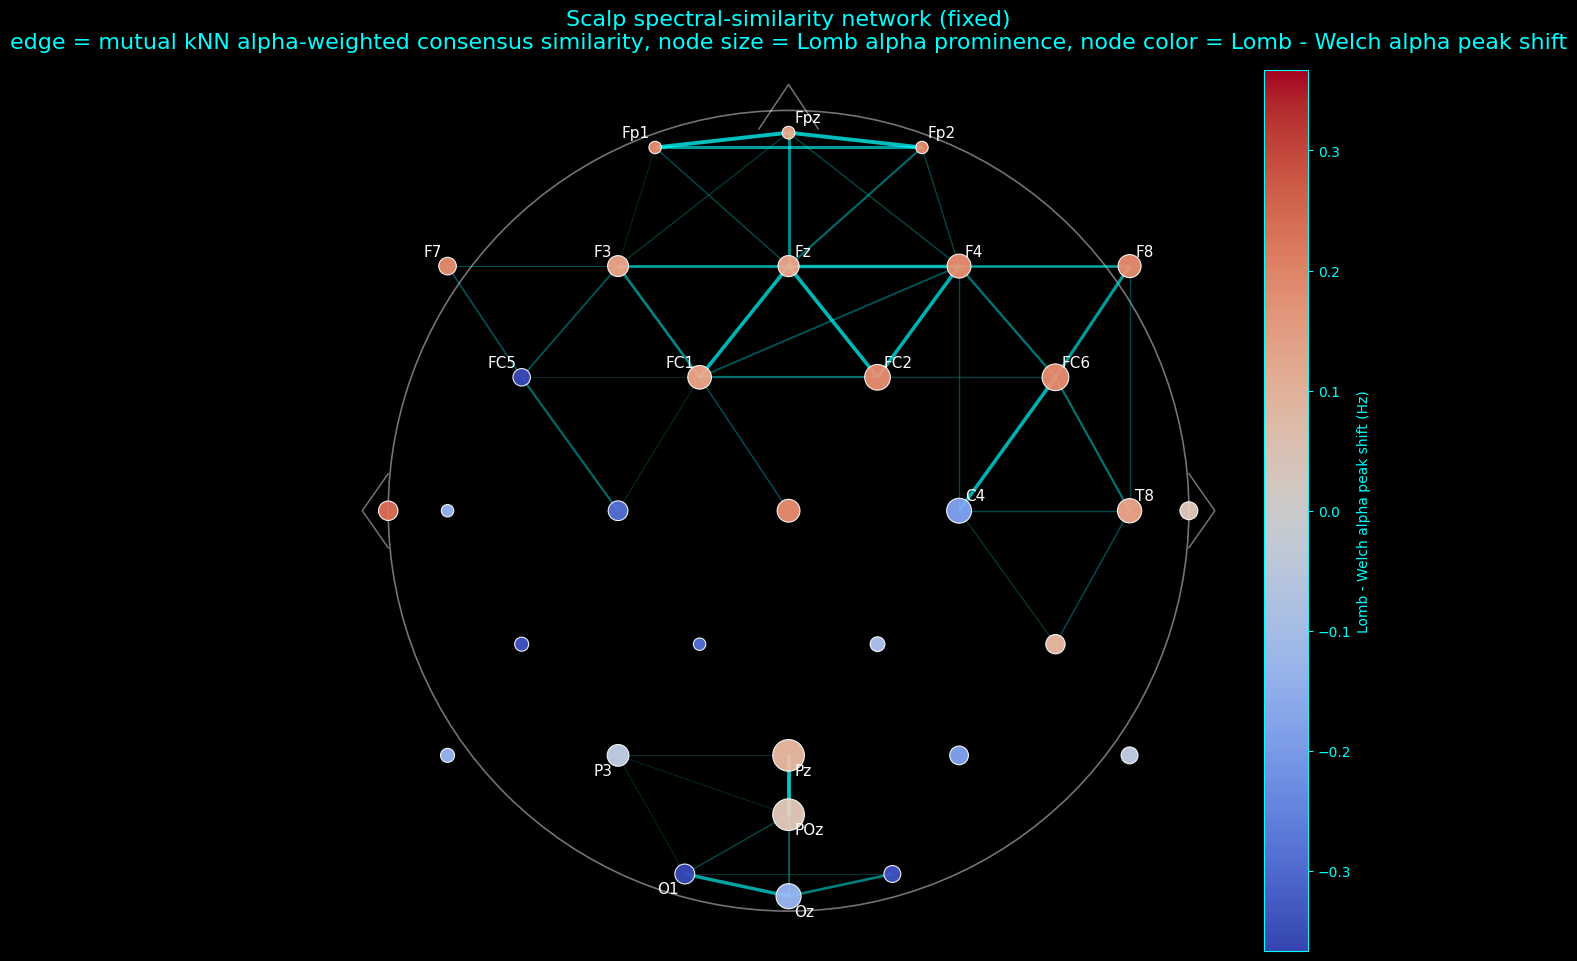


Saved geometry outputs:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/spectral_geometry_outputs.npz
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/spectral_geometry_channel_metrics.csv

Saved plot files:
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/13_clustered_spectral_similarity_heatmap.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/14_spectral_geometry_dendrogram.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/15_spectral_manifold_2d.png
/home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_lomb_scargle_all_channels_FIXED/spectral_geometry/plots/16_scalp_spectral_similarity_network_FIXE

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, fcluster
from scipy.spatial.distance import squareform
from matplotlib.collections import LineCollection
from matplotlib import patches

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
results_dir = os.path.join(base_dir, "results", "exploratory_lomb_scargle_all_channels_FIXED")

npz_path = os.path.join(results_dir, "exploratory_lomb_scargle_all_channels_FIXED_outputs.npz")
summary_csv_path = os.path.join(results_dir, "lomb_scargle_all_channels_FIXED_summary.csv")

out_dir = os.path.join(results_dir, "spectral_geometry")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

fmin_compare, fmax_compare = 2.0, 45.0
n_clusters = 5
top_n_annotate = 10

eps = 1e-12
ACCENT = "cyan"
BG = "black"
GRID = ACCENT

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def robust_unit_interval(x, lo=5, hi=95):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) < 3:
        return out
    a, b = np.nanpercentile(x[good], [lo, hi])
    span = max(b - a, eps)
    out[good] = np.clip((x[good] - a) / span, 0, 1)
    return out

def rowwise_standardize(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x, axis=1, keepdims=True)
    sd = np.nanstd(x, axis=1, keepdims=True)
    sd = np.where(~np.isfinite(sd) | (sd < eps), 1.0, sd)
    z = (x - mu) / sd
    z[~np.isfinite(z)] = 0.0
    return z

def finite_row_correlation_similarity(x):
    """
    Safe correlation-like similarity across rows.
    Uses cosine similarity of rowwise-zscored spectra.
    This avoids NaNs from zero-variance rows.
    """
    x = np.asarray(x, dtype=float)
    xz = rowwise_standardize(x)
    norms = np.linalg.norm(xz, axis=1, keepdims=True)
    xn = np.divide(xz, norms, out=np.zeros_like(xz), where=norms > eps)
    sim = xn @ xn.T
    sim = np.clip(sim, -1.0, 1.0)
    sim[~np.isfinite(sim)] = 0.0
    sim = 0.5 * (sim + sim.T)
    np.fill_diagonal(sim, 1.0)
    return sim

def classical_mds(distance_matrix, n_components=2):
    """
    Classical metric MDS / PCoA from a full square distance matrix.
    """
    D = np.asarray(distance_matrix, dtype=float)
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    pos = eigvals > 0
    eigvals = eigvals[pos]
    eigvecs = eigvecs[:, pos]

    if len(eigvals) == 0:
        return np.zeros((n, n_components)), np.zeros(n_components)

    k = min(n_components, len(eigvals))
    coords = eigvecs[:, :k] * np.sqrt(eigvals[:k])
    if k < n_components:
        coords = np.hstack([coords, np.zeros((n, n_components - k))])

    return coords, eigvals[:k]

def ensure_channel_by_freq(arr, n_channels, n_freqs, name):
    """
    Return array as [channels x freqs], accepting either orientation.
    """
    arr = np.asarray(arr, dtype=float)
    if arr.shape == (n_channels, n_freqs):
        return arr
    if arr.shape == (n_freqs, n_channels):
        return arr.T
    raise ValueError(
        f"{name} has unexpected shape {arr.shape}; "
        f"expected ({n_channels}, {n_freqs}) or ({n_freqs}, {n_channels})."
    )

def get_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def robust_clip_symmetric(x, q=95):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) == 0:
        return np.zeros_like(x), 1.0
    lim = np.nanpercentile(np.abs(x[good]), q)
    lim = max(float(lim), eps)
    return np.clip(x, -lim, lim), lim

def safe_log10(a):
    a = np.asarray(a, dtype=float)
    return np.log10(np.clip(a, eps, None))

def robust_minmax(x, qlo=5, qhi=95):
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=float)
    good = np.isfinite(x)
    if np.sum(good) == 0:
        return out
    lo, hi = np.nanpercentile(x[good], [qlo, qhi])
    span = max(float(hi - lo), eps)
    out[good] = np.clip((x[good] - lo) / span, 0, 1)
    return out

def robust_scale(x, low=0.0, high=1.0, qlo=5, qhi=95):
    z = robust_minmax(x, qlo=qlo, qhi=qhi)
    return low + (high - low) * z

def head_positions_32():
    return {
        "Fp1": (-0.36, 0.98), "Fpz": (0.00, 1.02), "Fp2": (0.36, 0.98),
        "F7": (-0.92, 0.66), "F3": (-0.46, 0.66), "Fz": (0.00, 0.66), "F4": (0.46, 0.66), "F8": (0.92, 0.66),
        "FC5": (-0.72, 0.36), "FC1": (-0.24, 0.36), "FC2": (0.24, 0.36), "FC6": (0.72, 0.36),
        "M1": (-1.08, 0.00), "T7": (-0.92, 0.00), "C3": (-0.46, 0.00), "Cz": (0.00, 0.00), "C4": (0.46, 0.00), "T8": (0.92, 0.00), "M2": (1.08, 0.00),
        "CP5": (-0.72, -0.36), "CP1": (-0.24, -0.36), "CP2": (0.24, -0.36), "CP6": (0.72, -0.36),
        "P7": (-0.92, -0.66), "P3": (-0.46, -0.66), "Pz": (0.00, -0.66), "P4": (0.46, -0.66), "P8": (0.92, -0.66),
        "POz": (0.00, -0.82),
        "O1": (-0.28, -0.98), "Oz": (0.00, -1.04), "O2": (0.28, -0.98),
    }

def circular_fallback_positions(names):
    theta = np.linspace(0, 2 * np.pi, len(names), endpoint=False)
    return {ch: (np.cos(t), np.sin(t)) for ch, t in zip(names, theta)}

# -------------------------------------------------------
# LOAD SAVED OUTPUTS
# -------------------------------------------------------
if not os.path.exists(npz_path):
    raise FileNotFoundError(f"Missing NPZ: {npz_path}")
if not os.path.exists(summary_csv_path):
    raise FileNotFoundError(f"Missing summary CSV: {summary_csv_path}")

npz = np.load(npz_path, allow_pickle=True)
summary_df = pd.read_csv(summary_csv_path)

freqs_hz = np.asarray(npz["frequencies_hz"], dtype=float)
channel_names = [str(x) for x in np.asarray(npz["channel_names"]).tolist()]
n_channels = len(channel_names)
n_freqs = len(freqs_hz)

clean_lomb_raw = np.asarray(npz["clean_lomb_area_normalized_2_45Hz"], dtype=float)
clean_welch_raw = np.asarray(npz["clean_welch_area_normalized_2_45Hz"], dtype=float)

clean_lomb = ensure_channel_by_freq(clean_lomb_raw, n_channels, n_freqs, "clean_lomb")
clean_welch = ensure_channel_by_freq(clean_welch_raw, n_channels, n_freqs, "clean_welch")

if "display_lomb_smoothed" in npz.files:
    display_lomb_raw = np.asarray(npz["display_lomb_smoothed"], dtype=float)
    display_lomb = ensure_channel_by_freq(display_lomb_raw, n_channels, n_freqs, "display_lomb_smoothed")
else:
    display_lomb = clean_lomb.copy()

if "display_welch_smoothed" in npz.files:
    display_welch_raw = np.asarray(npz["display_welch_smoothed"], dtype=float)
    display_welch = ensure_channel_by_freq(display_welch_raw, n_channels, n_freqs, "display_welch_smoothed")
else:
    display_welch = clean_welch.copy()

summary_df = summary_df.set_index("channel").reindex(channel_names).reset_index()

print(f"Loaded NPZ: {npz_path}")
print(f"Loaded summary CSV: {summary_csv_path}")
print(f"Channels: {len(channel_names)}")
print(f"Frequency bins: {len(freqs_hz)}")

# -------------------------------------------------------
# BUILD CONSENSUS SPECTRAL FINGERPRINTS
# -------------------------------------------------------
compare_mask = (freqs_hz >= fmin_compare) & (freqs_hz <= fmax_compare)

# Channel x frequency matrices
X_lomb = safe_log10(display_lomb[:, compare_mask])
X_welch = safe_log10(display_welch[:, compare_mask])

# Standardize each channel across frequency to emphasize shape
X_lomb_z = rowwise_standardize(X_lomb)
X_welch_z = rowwise_standardize(X_welch)

# Consensus fingerprint
X_consensus = 0.5 * (X_lomb_z + X_welch_z)
X_consensus[~np.isfinite(X_consensus)] = 0.0

# SAFE similarity + distance
similarity = finite_row_correlation_similarity(X_consensus)
distance = 1.0 - similarity
distance[~np.isfinite(distance)] = 1.0
distance = np.clip(distance, 0.0, 2.0)
distance = 0.5 * (distance + distance.T)
np.fill_diagonal(distance, 0.0)

# SAFE linkage input
condensed_dist = squareform(distance, checks=False)
if not np.all(np.isfinite(condensed_dist)):
    condensed_dist = np.where(np.isfinite(condensed_dist), condensed_dist, 1.0)

Z = linkage(condensed_dist, method="average", optimal_ordering=True)
leaf_order = leaves_list(Z)
cluster_ids = fcluster(Z, t=min(n_clusters, n_channels), criterion="maxclust")

# Summary-aligned descriptors
alpha_prom_col = get_first_existing_column(summary_df, [
    "lomb_alpha_peak_prominence",
    "lomb_alpha_peak_prom",
    "lomb_peak_prominence_alpha",
])
alpha_frac_col = get_first_existing_column(summary_df, [
    "lomb_alpha_band_fraction_2_45Hz",
    "alpha_band_fraction_2_45Hz",
    "lomb_alpha_fraction",
])
peak_shift_col = get_first_existing_column(summary_df, [
    "alpha_peak_shift_signed_Hz",
    "ls_minus_welch_alpha_peak_shift_hz",
    "lomb_minus_welch_alpha_peak_shift_hz",
])

alpha_prom = pd.to_numeric(summary_df[alpha_prom_col], errors="coerce").values.astype(float) if alpha_prom_col else np.zeros(n_channels)
alpha_frac = pd.to_numeric(summary_df[alpha_frac_col], errors="coerce").values.astype(float) if alpha_frac_col else np.zeros(n_channels)
peak_shift = pd.to_numeric(summary_df[peak_shift_col], errors="coerce").values.astype(float) if peak_shift_col else np.zeros(n_channels)

prom_norm = robust_unit_interval(alpha_prom, lo=5, hi=95)
frac_norm = robust_unit_interval(alpha_frac, lo=5, hi=95)

# -------------------------------------------------------
# SAVE NUMERIC GEOMETRY OUTPUTS
# -------------------------------------------------------
geometry_csv_path = os.path.join(out_dir, "spectral_geometry_channel_metrics.csv")
geometry_df = pd.DataFrame({
    "channel": channel_names,
    "cluster_id": cluster_ids,
    "alpha_prominence": alpha_prom,
    "alpha_fraction": alpha_frac,
    "peak_shift_signed_hz": peak_shift,
})
geometry_df.to_csv(geometry_csv_path, index=False)

similarity_npz_path = os.path.join(out_dir, "spectral_geometry_outputs.npz")
np.savez_compressed(
    similarity_npz_path,
    channel_names=np.array(channel_names, dtype=object),
    frequencies_hz=freqs_hz[compare_mask],
    consensus_fingerprints=X_consensus,
    similarity_matrix=similarity,
    distance_matrix=distance,
    cluster_ids=cluster_ids,
    leaf_order=leaf_order,
)

# -------------------------------------------------------
# PLOT 13 — CLUSTERED SPECTRAL SIMILARITY HEATMAP
# -------------------------------------------------------
ordered_channels = [channel_names[i] for i in leaf_order]
ordered_similarity = similarity[np.ix_(leaf_order, leaf_order)]

fig, ax = plt.subplots(figsize=(10.8, 9.4), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    ordered_similarity,
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    interpolation="nearest",
    aspect="auto",
)

ax.set_title("Spectral similarity heatmap\n(consensus Lomb–Welch shape fingerprints)")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(ordered_channels)))
ax.set_xticklabels(ordered_channels, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(ordered_channels)))
ax.set_yticklabels(ordered_channels, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spectral similarity (correlation)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot13_path = os.path.join(plots_dir, "13_clustered_spectral_similarity_heatmap.png")
plt.tight_layout()
plt.savefig(plot13_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 14 — DENDROGRAM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(13.5, 6.2), facecolor=BG)
style_ax(ax)

dendrogram(
    Z,
    labels=channel_names,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=None,
    above_threshold_color="white",
)

ax.set_title("Hierarchical dendrogram of cross-estimator spectral geometry")
ax.set_xlabel("Channel")
ax.set_ylabel("Correlation distance")

plot14_path = os.path.join(plots_dir, "14_spectral_geometry_dendrogram.png")
plt.tight_layout()
plt.savefig(plot14_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 15 — 2D SPECTRAL MANIFOLD
# -------------------------------------------------------
coords, eigvals = classical_mds(distance, n_components=2)
x = coords[:, 0]
y = coords[:, 1]

shift_good = np.isfinite(peak_shift)
if np.sum(shift_good) >= 3:
    shift_abs = np.nanpercentile(np.abs(peak_shift[shift_good]), 95)
else:
    shift_abs = 0.5
shift_abs = max(float(shift_abs), 0.25)

sizes = 80 + 420 * frac_norm

fig, ax = plt.subplots(figsize=(10.6, 8.2), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    x,
    y,
    s=sizes,
    c=np.clip(peak_shift, -shift_abs, shift_abs),
    cmap="coolwarm",
    alpha=0.92,
    edgecolors="white",
    linewidths=0.7,
)

annot_idx = np.argsort(-np.nan_to_num(alpha_prom, nan=-np.inf))[:top_n_annotate]
for idx in annot_idx:
    ax.text(
        x[idx] + 0.01,
        y[idx] + 0.01,
        channel_names[idx],
        color="white",
        fontsize=9,
    )

ax.axhline(0.0, color="white", alpha=0.18, linewidth=0.8, linestyle=":")
ax.axvline(0.0, color="white", alpha=0.18, linewidth=0.8, linestyle=":")
ax.set_title("2D spectral manifold\n(size = alpha fraction, color = LS - Welch peak shift)")
ax.set_xlabel("Manifold axis 1")
ax.set_ylabel("Manifold axis 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("LS - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot15_path = os.path.join(plots_dir, "15_spectral_manifold_2d.png")
plt.tight_layout()
plt.savefig(plot15_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 16 — FIXED SCALP SPECTRAL-SIMILARITY NETWORK
# mutual kNN graph on alpha-weighted consensus spectral similarity
# edge = strongest consensus similarity
# node size = Lomb alpha prominence
# node color = Lomb - Welch alpha peak shift
# -------------------------------------------------------
summary = summary_df.copy()
summary = summary.set_index("channel", drop=False)

prom_col = get_first_existing_column(summary, [
    "lomb_alpha_peak_prominence",
    "lomb_alpha_peak_prom",
    "lomb_peak_prominence_alpha",
    "alpha_peak_prominence_lomb",
])

lomb_peak_col = get_first_existing_column(summary, [
    "lomb_alpha_peak_hz",
    "lomb_alpha_peak_freq_hz",
    "lomb_alpha_peak_frequency_hz",
    "lomb_alpha_peak_frequency_Hz",
])

welch_peak_col = get_first_existing_column(summary, [
    "welch_alpha_peak_hz",
    "welch_alpha_peak_freq_hz",
    "welch_alpha_peak_frequency_hz",
    "welch_alpha_peak_frequency_Hz",
])

shift_col = get_first_existing_column(summary, [
    "ls_minus_welch_alpha_peak_shift_hz",
    "lomb_minus_welch_alpha_peak_shift_hz",
    "alpha_peak_shift_hz",
    "alpha_peak_shift_signed_Hz",
])

alpha_prom_net = np.full(n_channels, np.nan, dtype=float)
peak_shift_net = np.full(n_channels, np.nan, dtype=float)

for i, ch in enumerate(channel_names):
    if ch not in summary.index:
        continue

    if prom_col is not None:
        alpha_prom_net[i] = pd.to_numeric(summary.at[ch, prom_col], errors="coerce")

    if shift_col is not None:
        peak_shift_net[i] = pd.to_numeric(summary.at[ch, shift_col], errors="coerce")
    elif lomb_peak_col is not None and welch_peak_col is not None:
        lp = pd.to_numeric(summary.at[ch, lomb_peak_col], errors="coerce")
        wp = pd.to_numeric(summary.at[ch, welch_peak_col], errors="coerce")
        if np.isfinite(lp) and np.isfinite(wp):
            peak_shift_net[i] = lp - wp

if np.any(np.isfinite(alpha_prom_net)):
    alpha_prom_net = np.where(np.isfinite(alpha_prom_net), alpha_prom_net, np.nanmedian(alpha_prom_net[np.isfinite(alpha_prom_net)]))
else:
    alpha_prom_net = np.zeros(n_channels)

peak_shift_net = np.where(np.isfinite(peak_shift_net), peak_shift_net, 0.0)

full_mask = (freqs_hz >= 2.0) & (freqs_hz <= 45.0)
alpha_mask = (freqs_hz >= 8.0) & (freqs_hz <= 13.0)

log_lomb = safe_log10(clean_lomb)
log_welch = safe_log10(clean_welch)

full_lomb_corr = finite_row_correlation_similarity(log_lomb[:, full_mask])
full_welch_corr = finite_row_correlation_similarity(log_welch[:, full_mask])

if np.sum(alpha_mask) >= 3:
    alpha_lomb_corr = finite_row_correlation_similarity(log_lomb[:, alpha_mask])
    alpha_welch_corr = finite_row_correlation_similarity(log_welch[:, alpha_mask])
else:
    alpha_lomb_corr = full_lomb_corr.copy()
    alpha_welch_corr = full_welch_corr.copy()

consensus_sim = (
    0.30 * full_lomb_corr +
    0.30 * full_welch_corr +
    0.20 * alpha_lomb_corr +
    0.20 * alpha_welch_corr
)
consensus_sim = np.asarray(consensus_sim, dtype=float)
consensus_sim[~np.isfinite(consensus_sim)] = 0.0
consensus_sim = 0.5 * (consensus_sim + consensus_sim.T)
np.fill_diagonal(consensus_sim, 1.0)

sim_no_diag = consensus_sim.copy()
np.fill_diagonal(sim_no_diag, -np.inf)

k = 4
nbrs = np.argsort(sim_no_diag, axis=1)[:, ::-1][:, :k]

finite_edge_vals = sim_no_diag[np.isfinite(sim_no_diag)]
global_edge_floor = np.nanpercentile(finite_edge_vals, 82) if finite_edge_vals.size else 0.0

edge_set = set()
for i in range(n_channels):
    for j in nbrs[i]:
        if j < 0:
            continue
        mutual = i in nbrs[j]
        strong = consensus_sim[i, j] >= global_edge_floor
        if mutual or strong:
            a, b = sorted((int(i), int(j)))
            if a != b:
                edge_set.add((a, b))

edges = sorted(list(edge_set))
edge_weights = np.array([consensus_sim[i, j] for i, j in edges], dtype=float) if edges else np.array([])

if edge_weights.size > 0:
    keep_floor = np.nanpercentile(edge_weights, 25)
    edges = [e for e, w in zip(edges, edge_weights) if w >= keep_floor]
    edge_weights = np.array([consensus_sim[i, j] for i, j in edges], dtype=float)

degree = np.zeros(n_channels, dtype=int)
for i, j in edges:
    degree[i] += 1
    degree[j] += 1

pos_map = head_positions_32()
fallback = circular_fallback_positions(channel_names)
xy = np.array([pos_map.get(ch, fallback[ch]) for ch in channel_names], dtype=float)

node_sizes = robust_scale(alpha_prom_net, low=80, high=520, qlo=10, qhi=95)
peak_shift_clip, shift_lim = robust_clip_symmetric(peak_shift_net, q=95)
node_cmap = plt.cm.coolwarm
node_norm = plt.Normalize(vmin=-shift_lim, vmax=shift_lim)

if edge_weights.size > 0:
    ew = robust_scale(edge_weights, low=0.6, high=2.8, qlo=10, qhi=95)
    ea = robust_scale(edge_weights, low=0.18, high=0.75, qlo=10, qhi=95)
else:
    ew = np.array([])
    ea = np.array([])

prom_rank = np.argsort(np.argsort(-alpha_prom_net))
label_mask = (prom_rank < 8) | (degree >= 3)

fig, ax = plt.subplots(figsize=(10.5, 10.5), facecolor=BG)
style_ax(ax)

head = patches.Circle((0, 0), radius=1.08, fill=False, ec="white", lw=1.2, alpha=0.45)
ax.add_patch(head)

ax.plot([-0.08, 0.00, 0.08], [1.03, 1.15, 1.03], color="white", lw=1.1, alpha=0.45)
ax.plot([-1.08, -1.15, -1.08], [0.10, 0.00, -0.10], color="white", lw=1.1, alpha=0.45)
ax.plot([1.08, 1.15, 1.08], [0.10, 0.00, -0.10], color="white", lw=1.1, alpha=0.45)

if edges:
    segs = []
    colors = []
    widths = []
    for idx, (i, j) in enumerate(edges):
        segs.append([xy[i], xy[j]])
        colors.append((0.0, 1.0, 1.0, float(ea[idx])))
        widths.append(float(ew[idx]))
    lc = LineCollection(segs, colors=colors, linewidths=widths, zorder=1)
    ax.add_collection(lc)

sc = ax.scatter(
    xy[:, 0], xy[:, 1],
    s=node_sizes,
    c=peak_shift_clip,
    cmap=node_cmap,
    norm=node_norm,
    edgecolors="white",
    linewidths=0.8,
    alpha=0.92,
    zorder=3
)

for i, ch in enumerate(channel_names):
    if not label_mask[i]:
        continue
    dx = 0.015 if xy[i, 0] >= 0 else -0.015
    dy = 0.020 if xy[i, 1] >= 0 else -0.020
    ha = "left" if dx > 0 else "right"
    va = "bottom" if dy > 0 else "top"
    ax.text(
        xy[i, 0] + dx,
        xy[i, 1] + dy,
        ch,
        color="white",
        fontsize=11,
        ha=ha,
        va=va,
        zorder=4
    )

ax.set_aspect("equal")
ax.set_xlim(-1.18, 1.18)
ax.set_ylim(-1.18, 1.18)
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

ax.set_title(
    "Scalp spectral-similarity network (fixed)\n"
    "edge = mutual kNN alpha-weighted consensus similarity, "
    "node size = Lomb alpha prominence, node color = Lomb - Welch alpha peak shift",
    color=ACCENT,
    fontsize=16,
    pad=18
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Lomb - Welch alpha peak shift (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for lab in cbar.ax.get_yticklabels():
    lab.set_color(ACCENT)

plot16_path = os.path.join(plots_dir, "16_scalp_spectral_similarity_network_FIXED.png")
plt.tight_layout()
plt.savefig(plot16_path, dpi=200, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# FINAL PRINTS
# -------------------------------------------------------
print("\nSaved geometry outputs:")
print(similarity_npz_path)
print(geometry_csv_path)

print("\nSaved plot files:")
print(plot13_path)
print(plot14_path)
print(plot15_path)
print(plot16_path)

print("\nDone.")

# Wavelet Transform

<div style="font-size: 13px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This scholarly overview elucidates the computational pipeline for frequency decomposition of electroencephalogram (EEG) data using wavelet transform. The technique provides an alternative to Fourier-based methods and allows for time-frequency localization.</p>
        <h2>Objectives</h2>
        <ul>
            <li>Channel-based Data Selection: Individual EEG channels are parsed from the master dataset.</li>
            <li>Continuous Wavelet Transform: Application of the wavelet transform to the EEG data.</li>
            <li>Power Spectral Density Estimation: Deriving PSD from the wavelet coefficients.</li>
            <li>Visualization: Time-frequency representation of the wavelet-based PSD.</li>
        </ul>
        <h2>Mathematical Foundations</h2>
        <h3>Wavelet Transform</h3>
        <p>The Continuous Wavelet Transform (CWT) is mathematically formulated as:</p>
        \[ CWT(x, a, b) = \frac{1}{\sqrt{a}} \int x(t) \psi^*\left(\frac{t-b}{a}\right)dt \]
        <p>Where \( \psi(t) \) is the mother wavelet and \( a \) and \( b \) are the scale and translation parameters respectively.</p>
        <h3>Power Spectral Density (PSD)</h3>
        <p>PSD is derived from the wavelet coefficients as:</p>
        \[ \text{PSD} = | \text{coefficients} |^2 \]
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Computational Steps</h2>
        <p>Each EEG channel undergoes the following computational steps:</p>
        <ul>
            <li>EEG data for the channel is extracted.</li>
            <li>Wavelet transform is applied to the EEG data using the Morlet wavelet.</li>
            <li>PSD is calculated from the absolute square of the wavelet coefficients.</li>
        </ul>
        <h2>Data Visualization</h2>
        <p>Frequency decomposition is visualized as an image plot. The x-axis represents time, while the y-axis represents frequency. The colors indicate the magnitude of the PSD at each time-frequency point, following the 'inferno' colormap for better visual discrimination.</p>
        <h2>Data Serialization</h2>
        <p>PSD values are saved as a NumPy file, adhering to a specified directory path. This ensures easy retrieval for subsequent analyses or publications.</p>
        <h2>Scientific Implications</h2>
        <p>Wavelet-based methods for time-frequency analysis offer finer granularity and are particularly advantageous for non-stationary signals like EEG. This approach is pivotal for neuroscientific studies related to brain oscillations, event-related potentials, and cognitive states.</p>
    </div>
</div>